In [2]:
import os
import wget
import tarfile

# Modify PATH at will
PATH_TO_InDATA = "../data/"

# Create path
os.makedirs(PATH_TO_InDATA, exist_ok=True)

In [3]:
# Specify the location of the CC config file. 
os.environ['CC_CONFIG'] = '/scratch/sbnb/sayala/chemical_checker/setup/cc_config.json'

from chemicalchecker import ChemicalChecker
ChemicalChecker.set_verbosity('DEBUG') # CRITICAL, ERROR, WARN, INFO or DEBUG
import numpy as np
import pandas as pd
import json
%matplotlib inline

2026-08-27 09:32:58,784 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] Logging level DEBUG for logger 'chemicalchecker'.


In [4]:
local_cc_dir = '../local_PertProt'
PATH_TO_DATA = "/scratch/sbnb/sayala/cc_data/data"  # See Download_Data.ipynb // Procedure step 3
cc_local = ChemicalChecker(local_cc_dir, dbconnect=False, custom_data_path=PATH_TO_DATA)

2026-08-27 09:34:56,691 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 09:34:56,742 chemicalchecker.core.chemcheck.ChemicalChecker [INFO    ] CC root directory exists: ignoring 'custom_data_path'.


## LOAD INPUT DATA -- Perturbation proteomics datasets

In [40]:
# Load the raw binary data
# Rows: compounds
# Columns: Uniprot IDs
import numpy as np
import pandas as pd
import json
%matplotlib inline

all_proteins_f = "../data/PerturbProt/all_studies_wide.csv"
deps_f = "../data/PerturbProt/all_studies_deps_wide.csv"
deepcovermoa_f = "../data/PerturbProt/deepcovermoa_wide.csv"
df_allprot = pd.read_csv(all_proteins_f, sep=',', index_col=0)
df_deps = pd.read_csv(deps_f, sep=',', index_col=0)
df_deepcovermoa = pd.read_csv(deepcovermoa_f, sep=',', index_col=0)

### AllProt

In [41]:
print(df_allprot.shape)
df_allprot.head()

(956, 82034)


,log2fc_A0A087WT44_HCT116_deepcovermoa,log2fc_A0A087WUW5_HCT116_deepcovermoa,log2fc_A0A087WZ62_HCT116_deepcovermoa,log2fc_A0A096LP01_HCT116_deepcovermoa,log2fc_A0A096LPC5_HCT116_deepcovermoa,log2fc_A0A0A0MRB7_HCT116_deepcovermoa,log2fc_A0A0A6YYJ5_HCT116_deepcovermoa,log2fc_A0A0C4DG89_HCT116_deepcovermoa,log2fc_A0A0G2JH58_HCT116_deepcovermoa,log2fc_A0A0G2JIF2_HCT116_deepcovermoa,...,log2fc_Q9Y6R0_Calu6_protmapdruglung,log2fc_Q9Y6R4_Calu6_protmapdruglung,log2fc_Q9Y6V7_Calu6_protmapdruglung,log2fc_Q9Y6W3_Calu6_protmapdruglung,log2fc_Q9Y6W5_Calu6_protmapdruglung,log2fc_Q9Y6X4_Calu6_protmapdruglung,log2fc_Q9Y6X8_Calu6_protmapdruglung,log2fc_Q9Y6X9_Calu6_protmapdruglung,log2fc_Q9Y6Y0_Calu6_protmapdruglung,log2fc_Q9Y6Y8_Calu6_protmapdruglung
inchikey,,,,,,,,,,,,,,,,,,,,,
AAKJLRGGTJKAMG-UHFFFAOYSA-N,0.07,NaN,0.03,NaN,0.16,-0.19,0.08,NaN,-0.17,0.07,...,0.512575,-0.184575,-0.055975,0.516241,-0.290725,NaN,-0.043638,0.343533,-0.466177,0.096033
AASYYGYJPZBFKC-UHFFFAOYSA-N,0.07,NaN,-0.10,NaN,0.07,0.10,0.03,NaN,0.09,0.03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACGDKVXYNVEAGU-UHFFFAOYSA-N,0.15,NaN,-0.05,NaN,-0.03,0.05,0.06,0.04,-0.01,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACIMQXSSGMWVKG-UHFFFAOYSA-N,0.03,NaN,0.02,NaN,-0.03,0.08,0.05,NaN,0.20,-0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACPOUJIDANTYHO-UHFFFAOYSA-N,-0.08,NaN,-0.06,0.19,0.27,0.04,0.10,NaN,-0.05,-0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### DEPs

In [42]:
print(df_deps.shape)
df_deps.head()

(938, 44625)


,log2fc_A0A087WZ62_HCT116_deepcovermoa,log2fc_A0A096LP01_HCT116_deepcovermoa,log2fc_A0A096LPC5_HCT116_deepcovermoa,log2fc_A0A0A0MRB7_HCT116_deepcovermoa,log2fc_A0A0A6YYJ5_HCT116_deepcovermoa,log2fc_A0A0C4DG89_HCT116_deepcovermoa,log2fc_A0A0G2JH58_HCT116_deepcovermoa,log2fc_A0A0G2JIF2_HCT116_deepcovermoa,log2fc_A0A0G2JPD3_HCT116_deepcovermoa,log2fc_A0A0J9YWL0_HCT116_deepcovermoa,...,log2fc_Q9Y6D6_Calu6_protmapdruglung,log2fc_Q9Y6E0_Calu6_protmapdruglung,log2fc_Q9Y6E2_Calu6_protmapdruglung,log2fc_Q9Y6G5_Calu6_protmapdruglung,log2fc_Q9Y6G9_Calu6_protmapdruglung,log2fc_Q9Y6I3_Calu6_protmapdruglung,log2fc_Q9Y6K9_Calu6_protmapdruglung,log2fc_Q9Y6V7_Calu6_protmapdruglung,log2fc_Q9Y6W3_Calu6_protmapdruglung,log2fc_Q9Y6W5_Calu6_protmapdruglung
inchikey,,,,,,,,,,,,,,,,,,,,,
AAKJLRGGTJKAMG-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AASYYGYJPZBFKC-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACGDKVXYNVEAGU-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACIMQXSSGMWVKG-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACPOUJIDANTYHO-UHFFFAOYSA-N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### DeepCoverMoa 

In [43]:
print(df_deepcovermoa.shape)
df_deepcovermoa.head()

(872, 9802)


,log2fc_A0A087WT44_HCT116_deepcovermoa,log2fc_A0A087WUW5_HCT116_deepcovermoa,log2fc_A0A087WZ62_HCT116_deepcovermoa,log2fc_A0A096LP01_HCT116_deepcovermoa,log2fc_A0A096LPC5_HCT116_deepcovermoa,log2fc_A0A0A0MRB7_HCT116_deepcovermoa,log2fc_A0A0A6YYJ5_HCT116_deepcovermoa,log2fc_A0A0C4DG89_HCT116_deepcovermoa,log2fc_A0A0G2JH58_HCT116_deepcovermoa,log2fc_A0A0G2JIF2_HCT116_deepcovermoa,...,log2fc_Q9Y6X3_HCT116_deepcovermoa,log2fc_Q9Y6X4_HCT116_deepcovermoa,log2fc_Q9Y6X5_HCT116_deepcovermoa,log2fc_Q9Y6X8_HCT116_deepcovermoa,log2fc_Q9Y6X9_HCT116_deepcovermoa,log2fc_Q9Y6Y0_HCT116_deepcovermoa,log2fc_Q9Y6Y1_HCT116_deepcovermoa,log2fc_Q9Y6Y8_HCT116_deepcovermoa,log2fc_R4GMX3_HCT116_deepcovermoa,log2fc_V9GYT7_HCT116_deepcovermoa
inchikey,,,,,,,,,,,,,,,,,,,,,
AAKJLRGGTJKAMG-UHFFFAOYSA-N,0.07,NaN,0.03,NaN,0.16,-0.19,0.08,NaN,-0.17,0.07,...,0.00,0.16,0.04,0.18,0.04,-0.37,NaN,-0.01,-0.03,0.13
AASYYGYJPZBFKC-UHFFFAOYSA-N,0.07,NaN,-0.10,NaN,0.07,0.10,0.03,NaN,0.09,0.03,...,0.00,-0.01,0.05,0.03,0.00,0.12,NaN,0.00,0.01,NaN
ACGDKVXYNVEAGU-UHFFFAOYSA-N,0.15,NaN,-0.05,NaN,-0.03,0.05,0.06,0.04,-0.01,0.00,...,-0.03,0.07,0.02,0.05,0.01,0.00,NaN,-0.01,0.00,NaN
ACIMQXSSGMWVKG-UHFFFAOYSA-N,0.03,NaN,0.02,NaN,-0.03,0.08,0.05,NaN,0.20,-0.01,...,0.03,0.01,-0.17,-0.28,0.01,0.26,NaN,0.03,0.01,NaN
ACPOUJIDANTYHO-UHFFFAOYSA-N,-0.08,NaN,-0.06,0.19,0.27,0.04,0.10,NaN,-0.05,-0.05,...,0.04,0.05,-0.02,0.11,0.06,0.06,NaN,0.00,0.19,0.29


## sign0

In [44]:
# Dataset Names
dataset_deps = 'PertProtDEPs'
dataset_all = 'PertProtAll'
dataset_dcmoa = 'DeepCoverMoa'

# Set sanitizer parameters to avoid expensive filtering that might cause issues
sanitizer_kwargs = {
    'chunk_size': 500000         # adjust chunk size for memory
}

# Instantiation of sign0 data structures for the new spaces: full and references
sign0_deps = cc_local.signature(dataset_deps, 'sign0')
sign0_allprot = cc_local.signature(dataset_all, 'sign0')
sign0_dcmoa = cc_local.signature(dataset_dcmoa, 'sign0')

2026-08-27 11:15:25,885 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign0
2026-08-27 11:15:25,888 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sign0
2026-08-27 11:15:25,891 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/sign0


### DeepCoverMoa

In [ ]:
# Cleaning both full and reference datasets. This is crucial!
sign0_dcmoa.clear_all()

# Fit sign0
sign0_dcmoa.fit(X=df_deepcovermoa.values, keys=list(df_deepcovermoa.index), features=list(df_deepcovermoa.columns), sanitizer_kwargs=sanitizer_kwargs)

In [46]:
sign0_dcmoa.shape

(872, 9802)

2026-08-27 11:18:21,593 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 11:18:21,648 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2026-08-27 11:18:21,649 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2026-08-27 11:18:21,650 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2026-08-27 11:18:21,651 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2026-08-27 11:18:21,652 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=872)
2026-08-27 11:18:21,652 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2026-08-27 11:18:22,276 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Saving signature subsample /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/sign0/diags/local_Pert

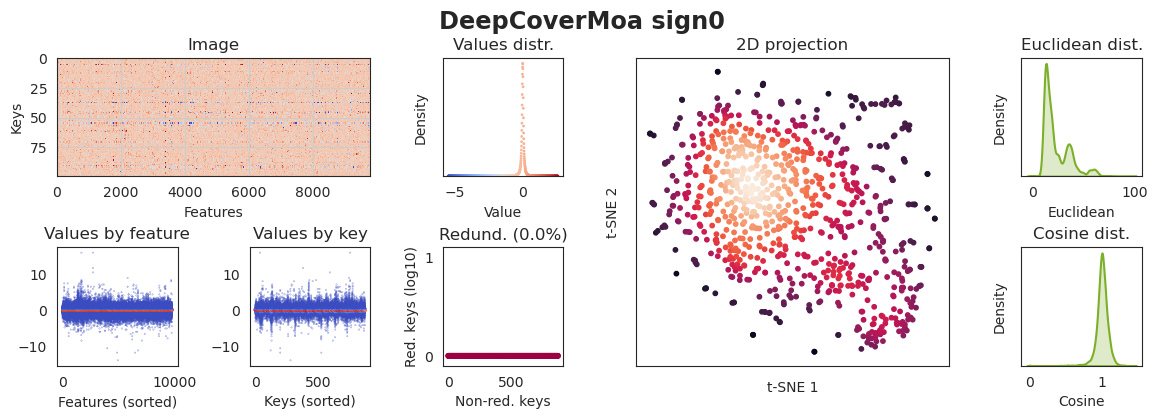

In [47]:
# Instantiation of diag0 (diagnosis plots)
diag0_dcmoa = sign0_dcmoa.diagnosis()

# Plot small diagnosis plots
diag0_dcmoa.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

### DEPs

In [ ]:
# Cleaning both full and reference datasets. This is crucial!
sign0_deps.clear_all()

# Fit sign0
sign0_deps.fit(X=df_deps.values, keys=list(df_deps.index), features=list(df_deps.columns), sanitizer_kwargs=sanitizer_kwargs)

In [24]:
sign0_deps.shape

(922, 10000)

2026-08-27 10:18:13,911 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 10:18:13,961 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2026-08-27 10:18:13,962 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2026-08-27 10:18:13,962 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2026-08-27 10:18:13,964 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2026-08-27 10:18:13,964 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=922)
2026-08-27 10:18:13,965 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2026-08-27 10:18:14,581 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Saving signature subsample /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign0/diags/local_Pert

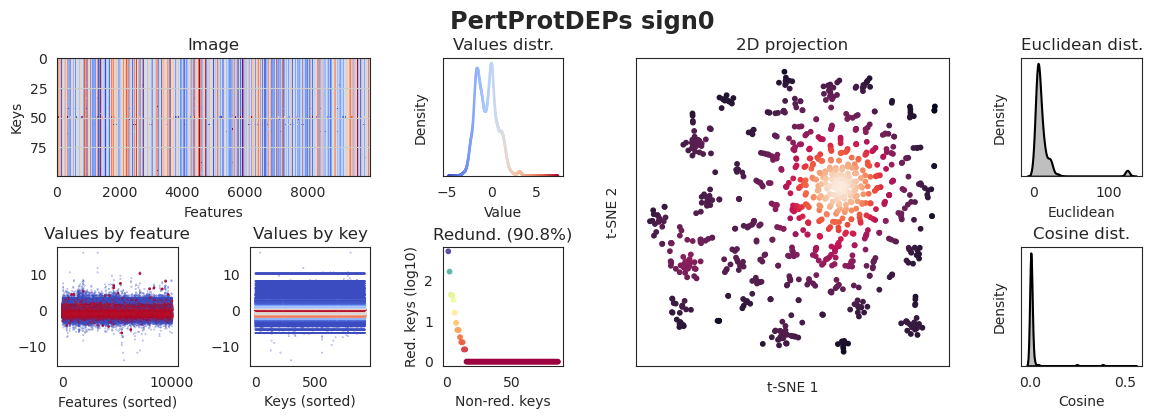

In [25]:
# Instantiation of diag0 (diagnosis plots)
diag0_deps = sign0_deps.diagnosis()

# Plot small diagnosis plots
diag0_deps.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [26]:
np.min(np.array(sign0_deps).flatten()), np.max(np.array(sign0_deps).flatten())

(-14.21, 16.02)

### AllProt

2026-08-27 10:23:59,233 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtAll/sign0
2026-08-27 10:23:59,235 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtAll/sign0
2026-08-27 10:23:59,241 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sign0
2026-08-27 10:23:59,242 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sign0
2026-08-27 10:23:59,256 chemicalchecker.core.signature_base.BaseSignature [INFO    ] STATUS: FIT START
2026-08-27 10:23:59,258 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sig

Features frequency (956, 76662)


Iterating on `V` axis 0: 100%|██████████| 1/1 [00:05<00:00,  5.14s/it]
2026-08-27 10:24:33,025 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Filter 0 keys (min_keys_abs): []
2026-08-27 10:24:33,026 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Filter 0 keys (max_keys_freq): []
2026-08-27 10:24:33,027 chemicalchecker.util.sanitize.sanitizer.Sanitizer [DEBUG   ] Missing values:
Iterating on `V` axis 0: 100%|██████████| 1/1 [00:05<00:00,  5.22s/it]
2026-08-27 10:24:38,253 chemicalchecker.util.sanitize.sanitizer.Sanitizer [DEBUG   ] NaN  :     63940563
2026-08-27 10:24:38,253 chemicalchecker.util.sanitize.sanitizer.Sanitizer [DEBUG   ] +inf :            0
2026-08-27 10:24:38,254 chemicalchecker.util.sanitize.sanitizer.Sanitizer [DEBUG   ] -inf :            0
2026-08-27 10:24:38,255 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Imputing missing values.
Iterating on `V` axis 1: 100%|██████████| 1/1 [00:14<00:00, 14.94s/it]
2026-08-27 10:24:53,202 

Flter nans and inf (956, 76662)


Iterating on `V` axis 1: 100%|██████████| 1/1 [00:05<00:00,  5.04s/it]
2026-08-27 10:25:03,673 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset features
Iterating on `V` axis 0: 100%|██████████| 1/1 [00:05<00:00,  5.74s/it]
2026-08-27 10:25:20,091 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Removed 66662 features (max_features): ['log2fc_A0A024R216_A549_protargetminer_55drugs'
 'log2fc_A0A024R412_A549_protargetminer_55drugs'
 'log2fc_A0A024R4E5_A549_protargetminer_55drugs' ...
 'log2fc_V9HW75_A549_protargetminer_55drugs'
 'log2fc_X5CMH5_A549_protargetminer_55drugs'
 'log2fc_X6R5E5_A549_protargetminer_55drugs']
2026-08-27 10:25:20,158 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Sanitized data shape: (956, 10000)


Filter too many features (956, 10000)


2026-08-27 10:25:20,846 chemicalchecker.core.signature_base.BaseSignature [INFO    ] STATUS: Aggregating
2026-08-27 10:25:20,864 chemicalchecker.util.aggregate.aggregate.Aggregate [DEBUG   ] Matrix does not need aggregation
2026-08-27 10:25:20,865 chemicalchecker.core.signature_base.BaseSignature [INFO    ] STATUS: Saving H5
2026-08-27 10:25:22,473 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Mappings are not available, using implicit key-key mappings.
2026-08-27 10:25:22,475 chemicalchecker.util.remove_near_duplicates.remove_near_duplicates.RNDuplicates [DEBUG   ] RNDuplicates to use 128 bits
2026-08-27 10:25:22,477 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtAll/sign0
2026-08-27 10:25:22,479 chemicalchecker.util.remove_near_duplicates.remove_near_duplicates.RNDuplicates [INFO    ] Removing near duplicates.
2026-08-27 10:25:22,480 chemicalchecker.util.remove_near_du

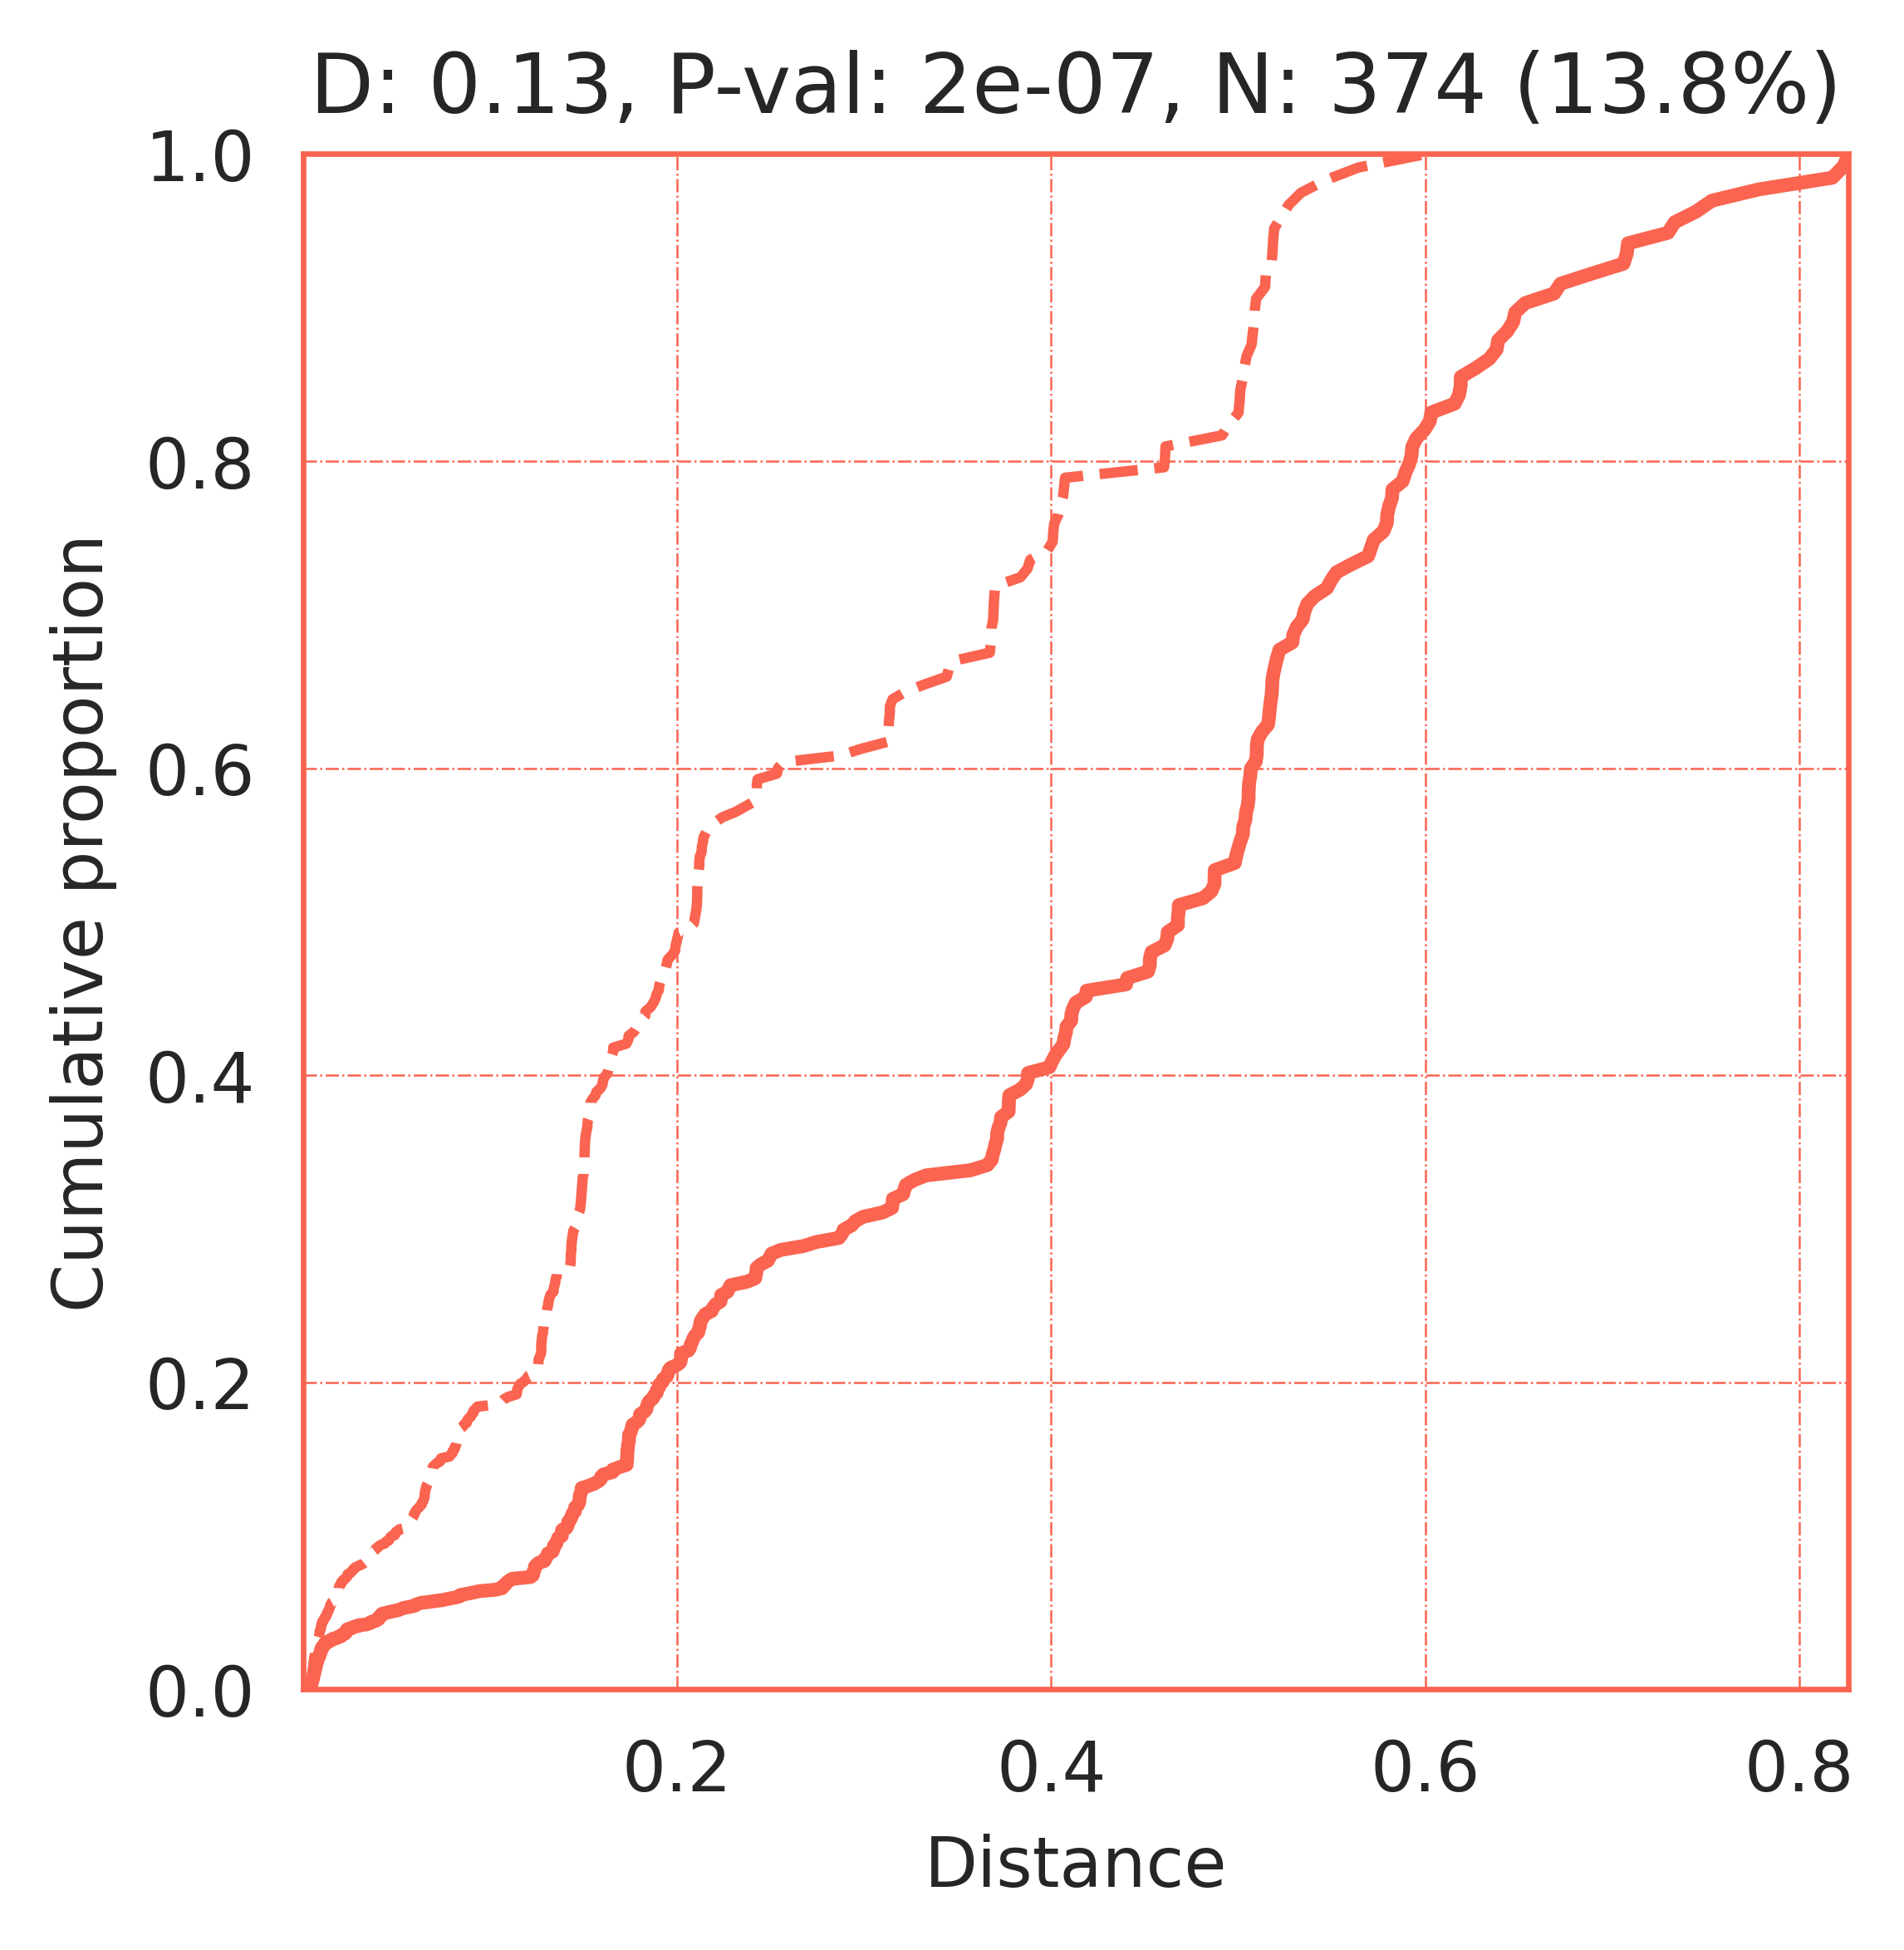

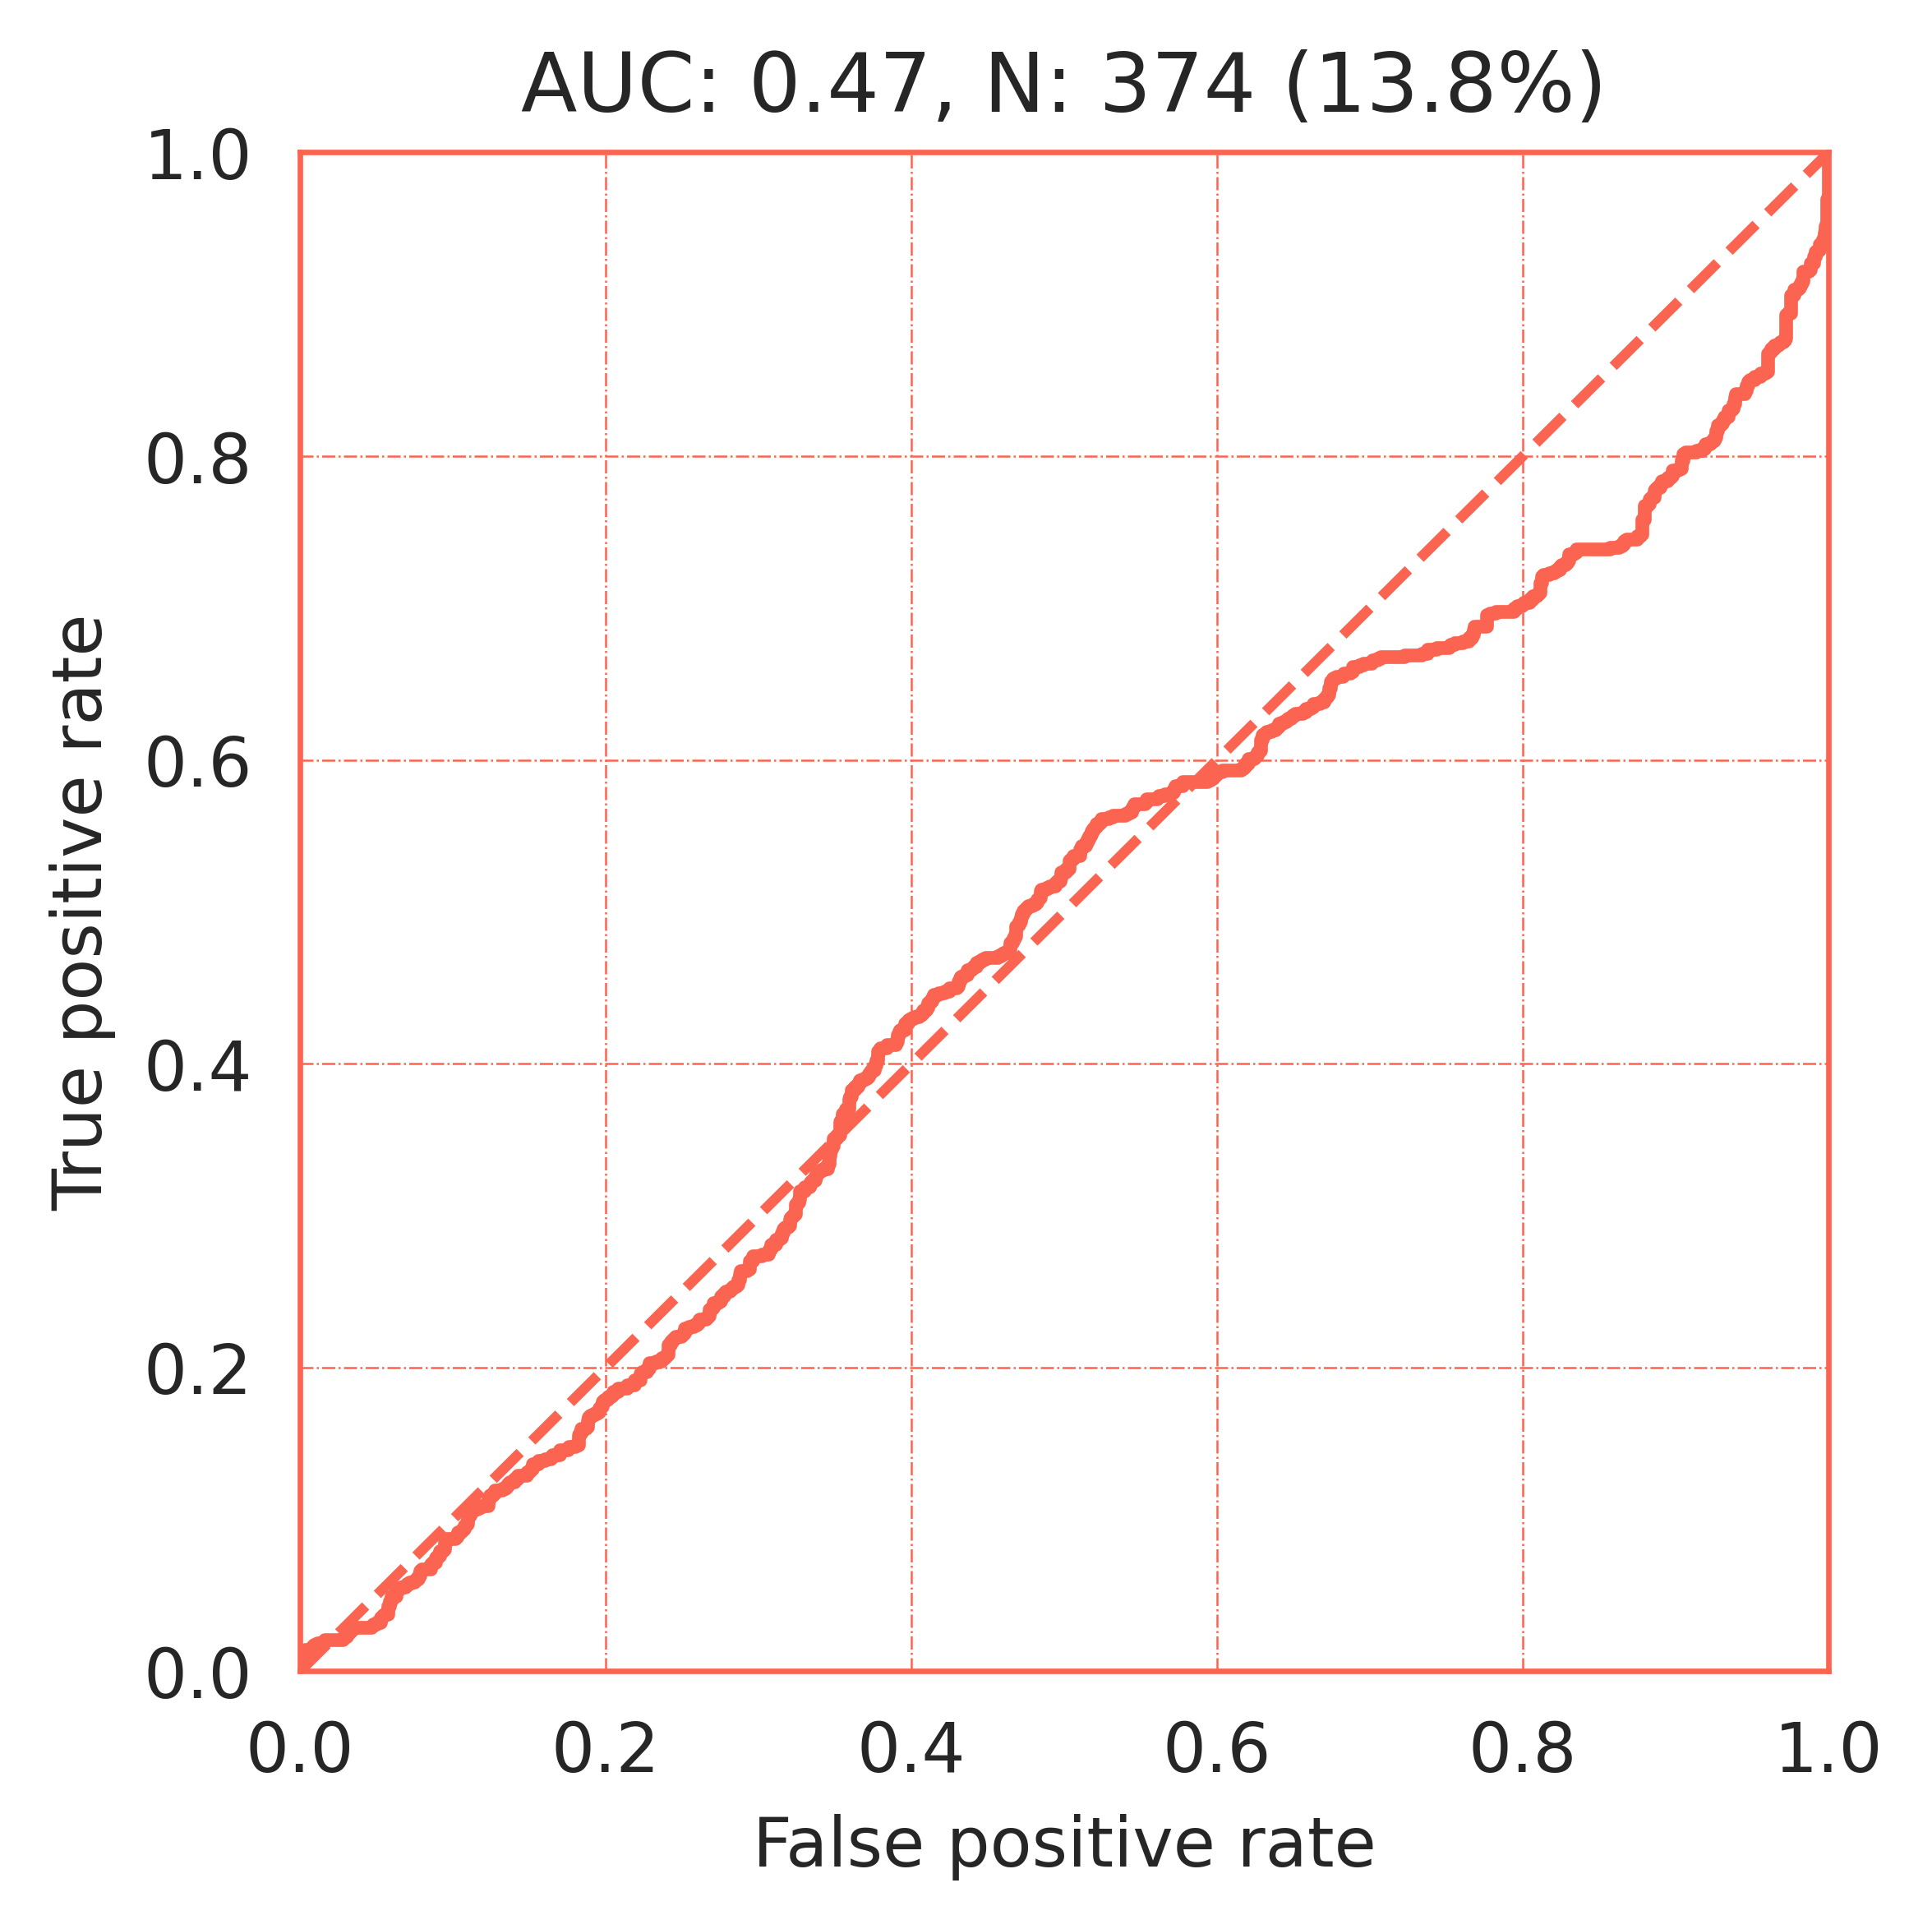

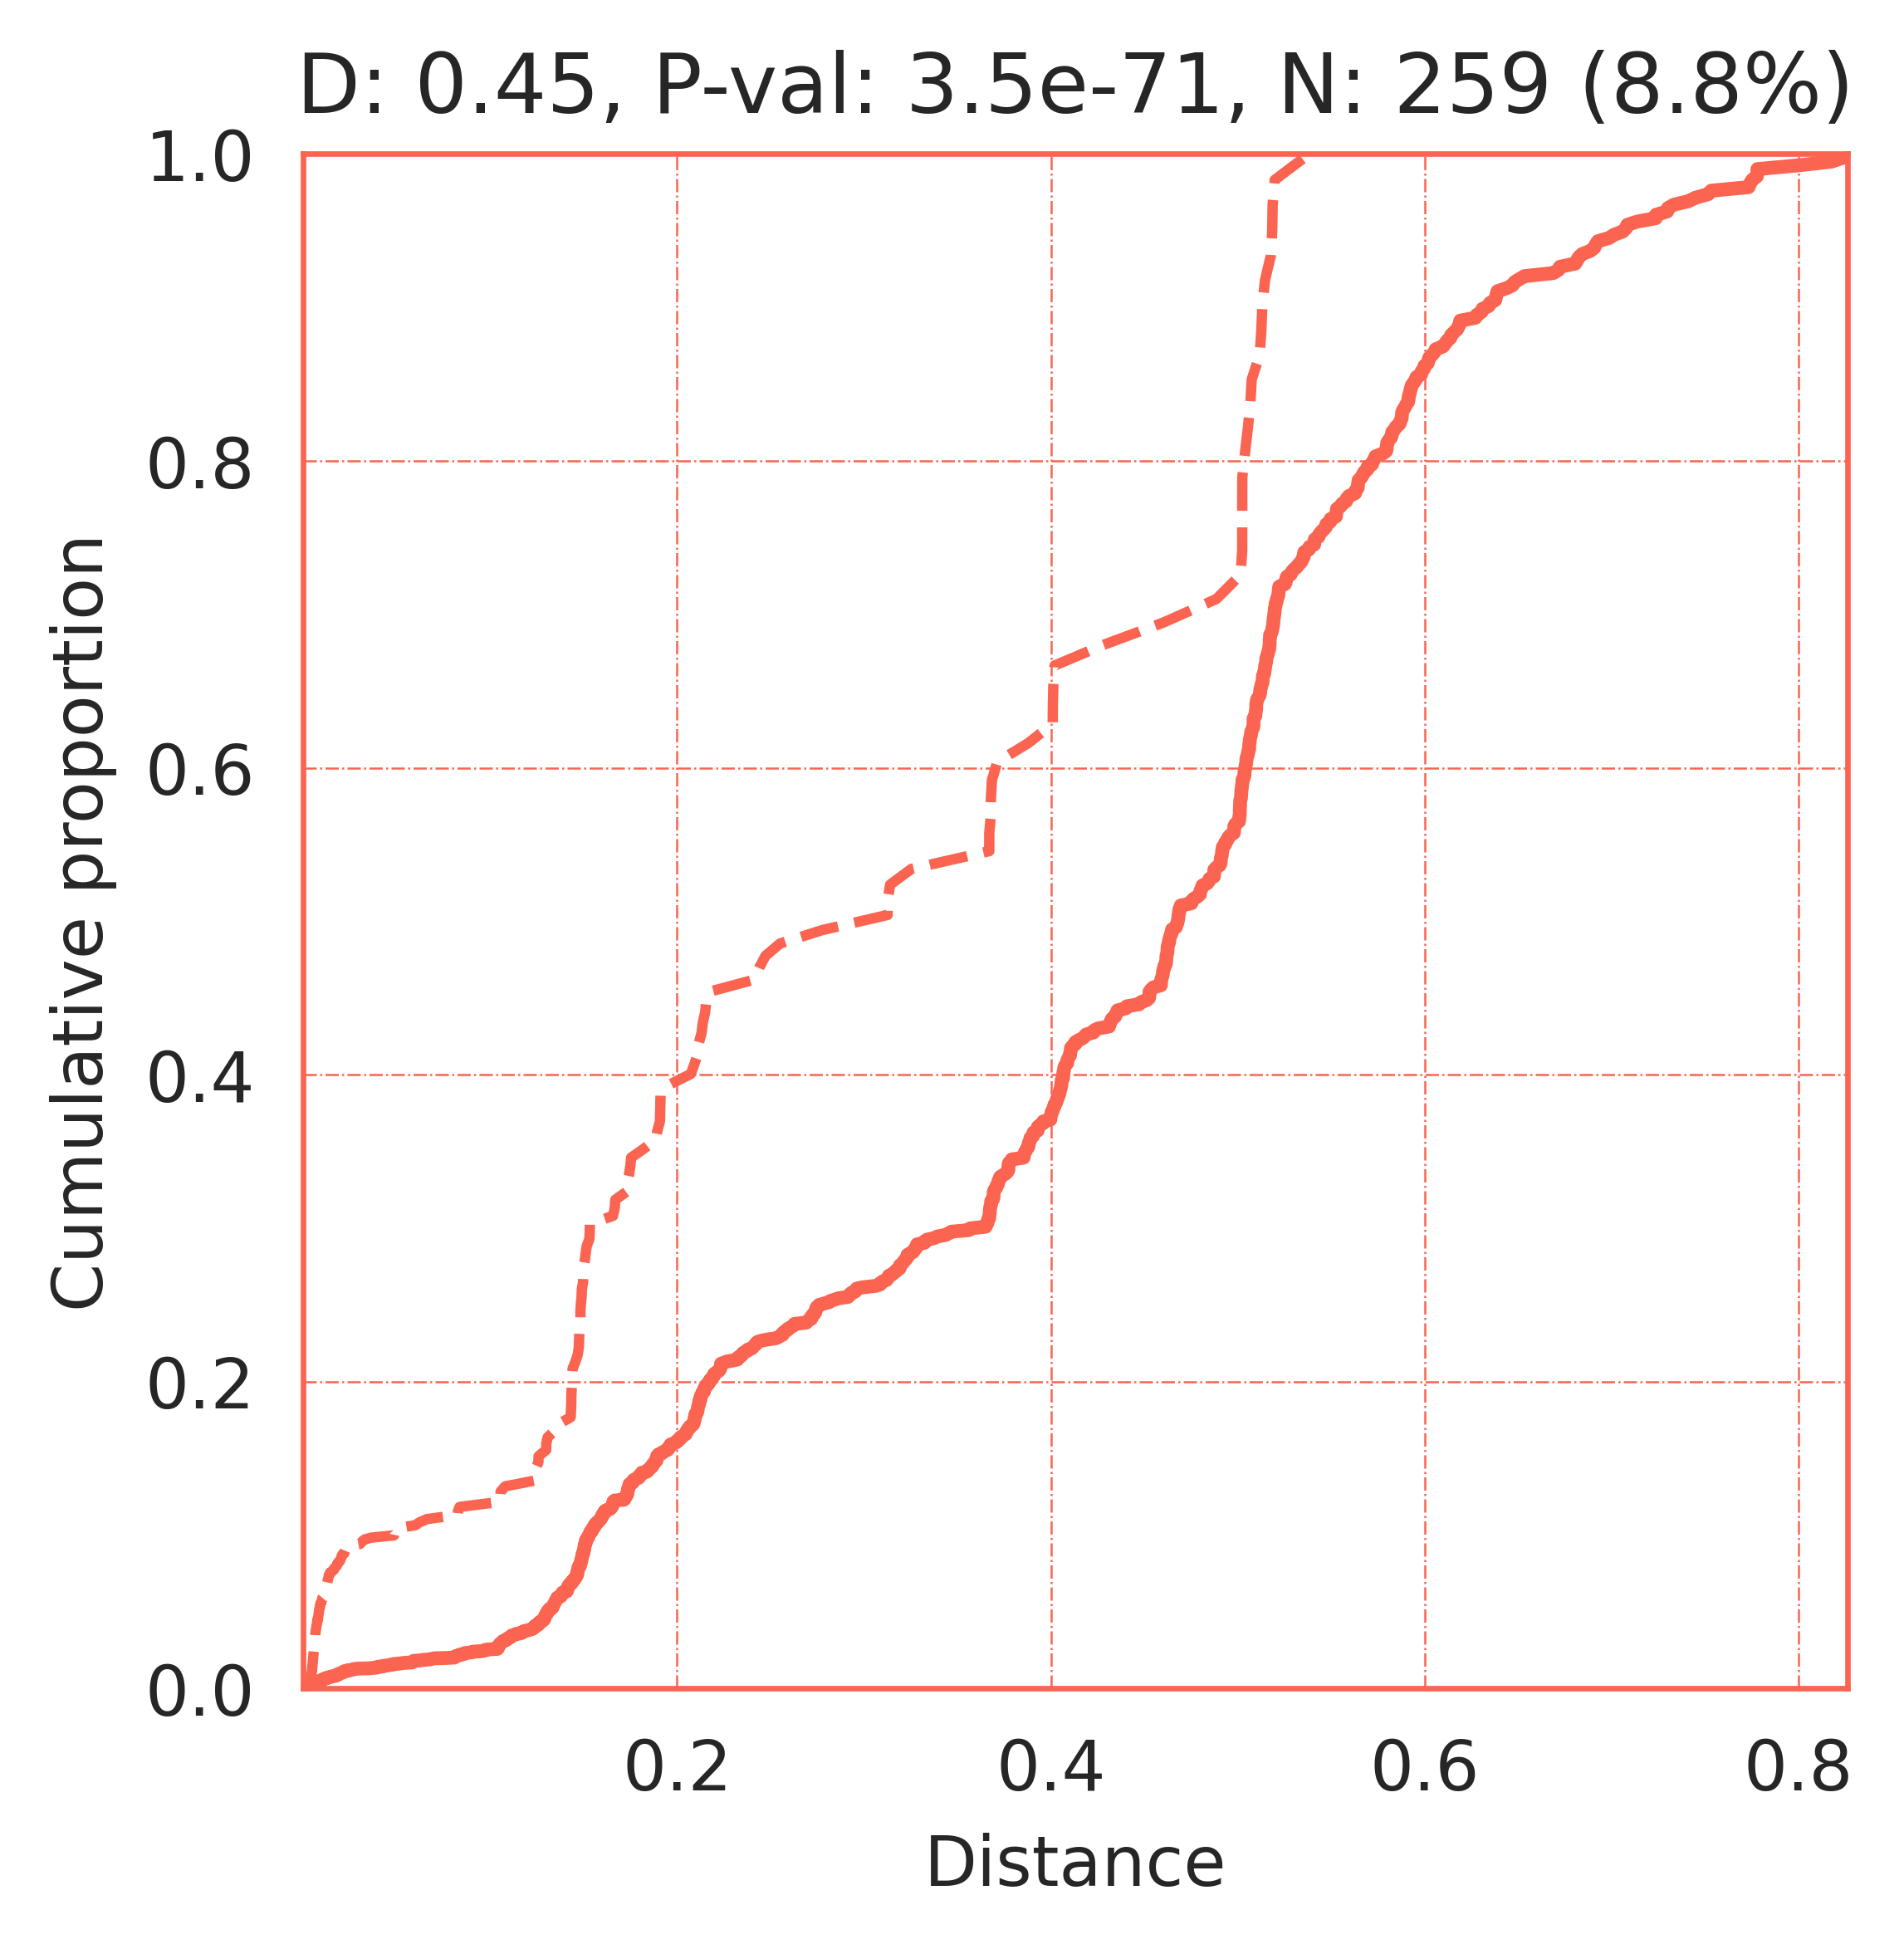

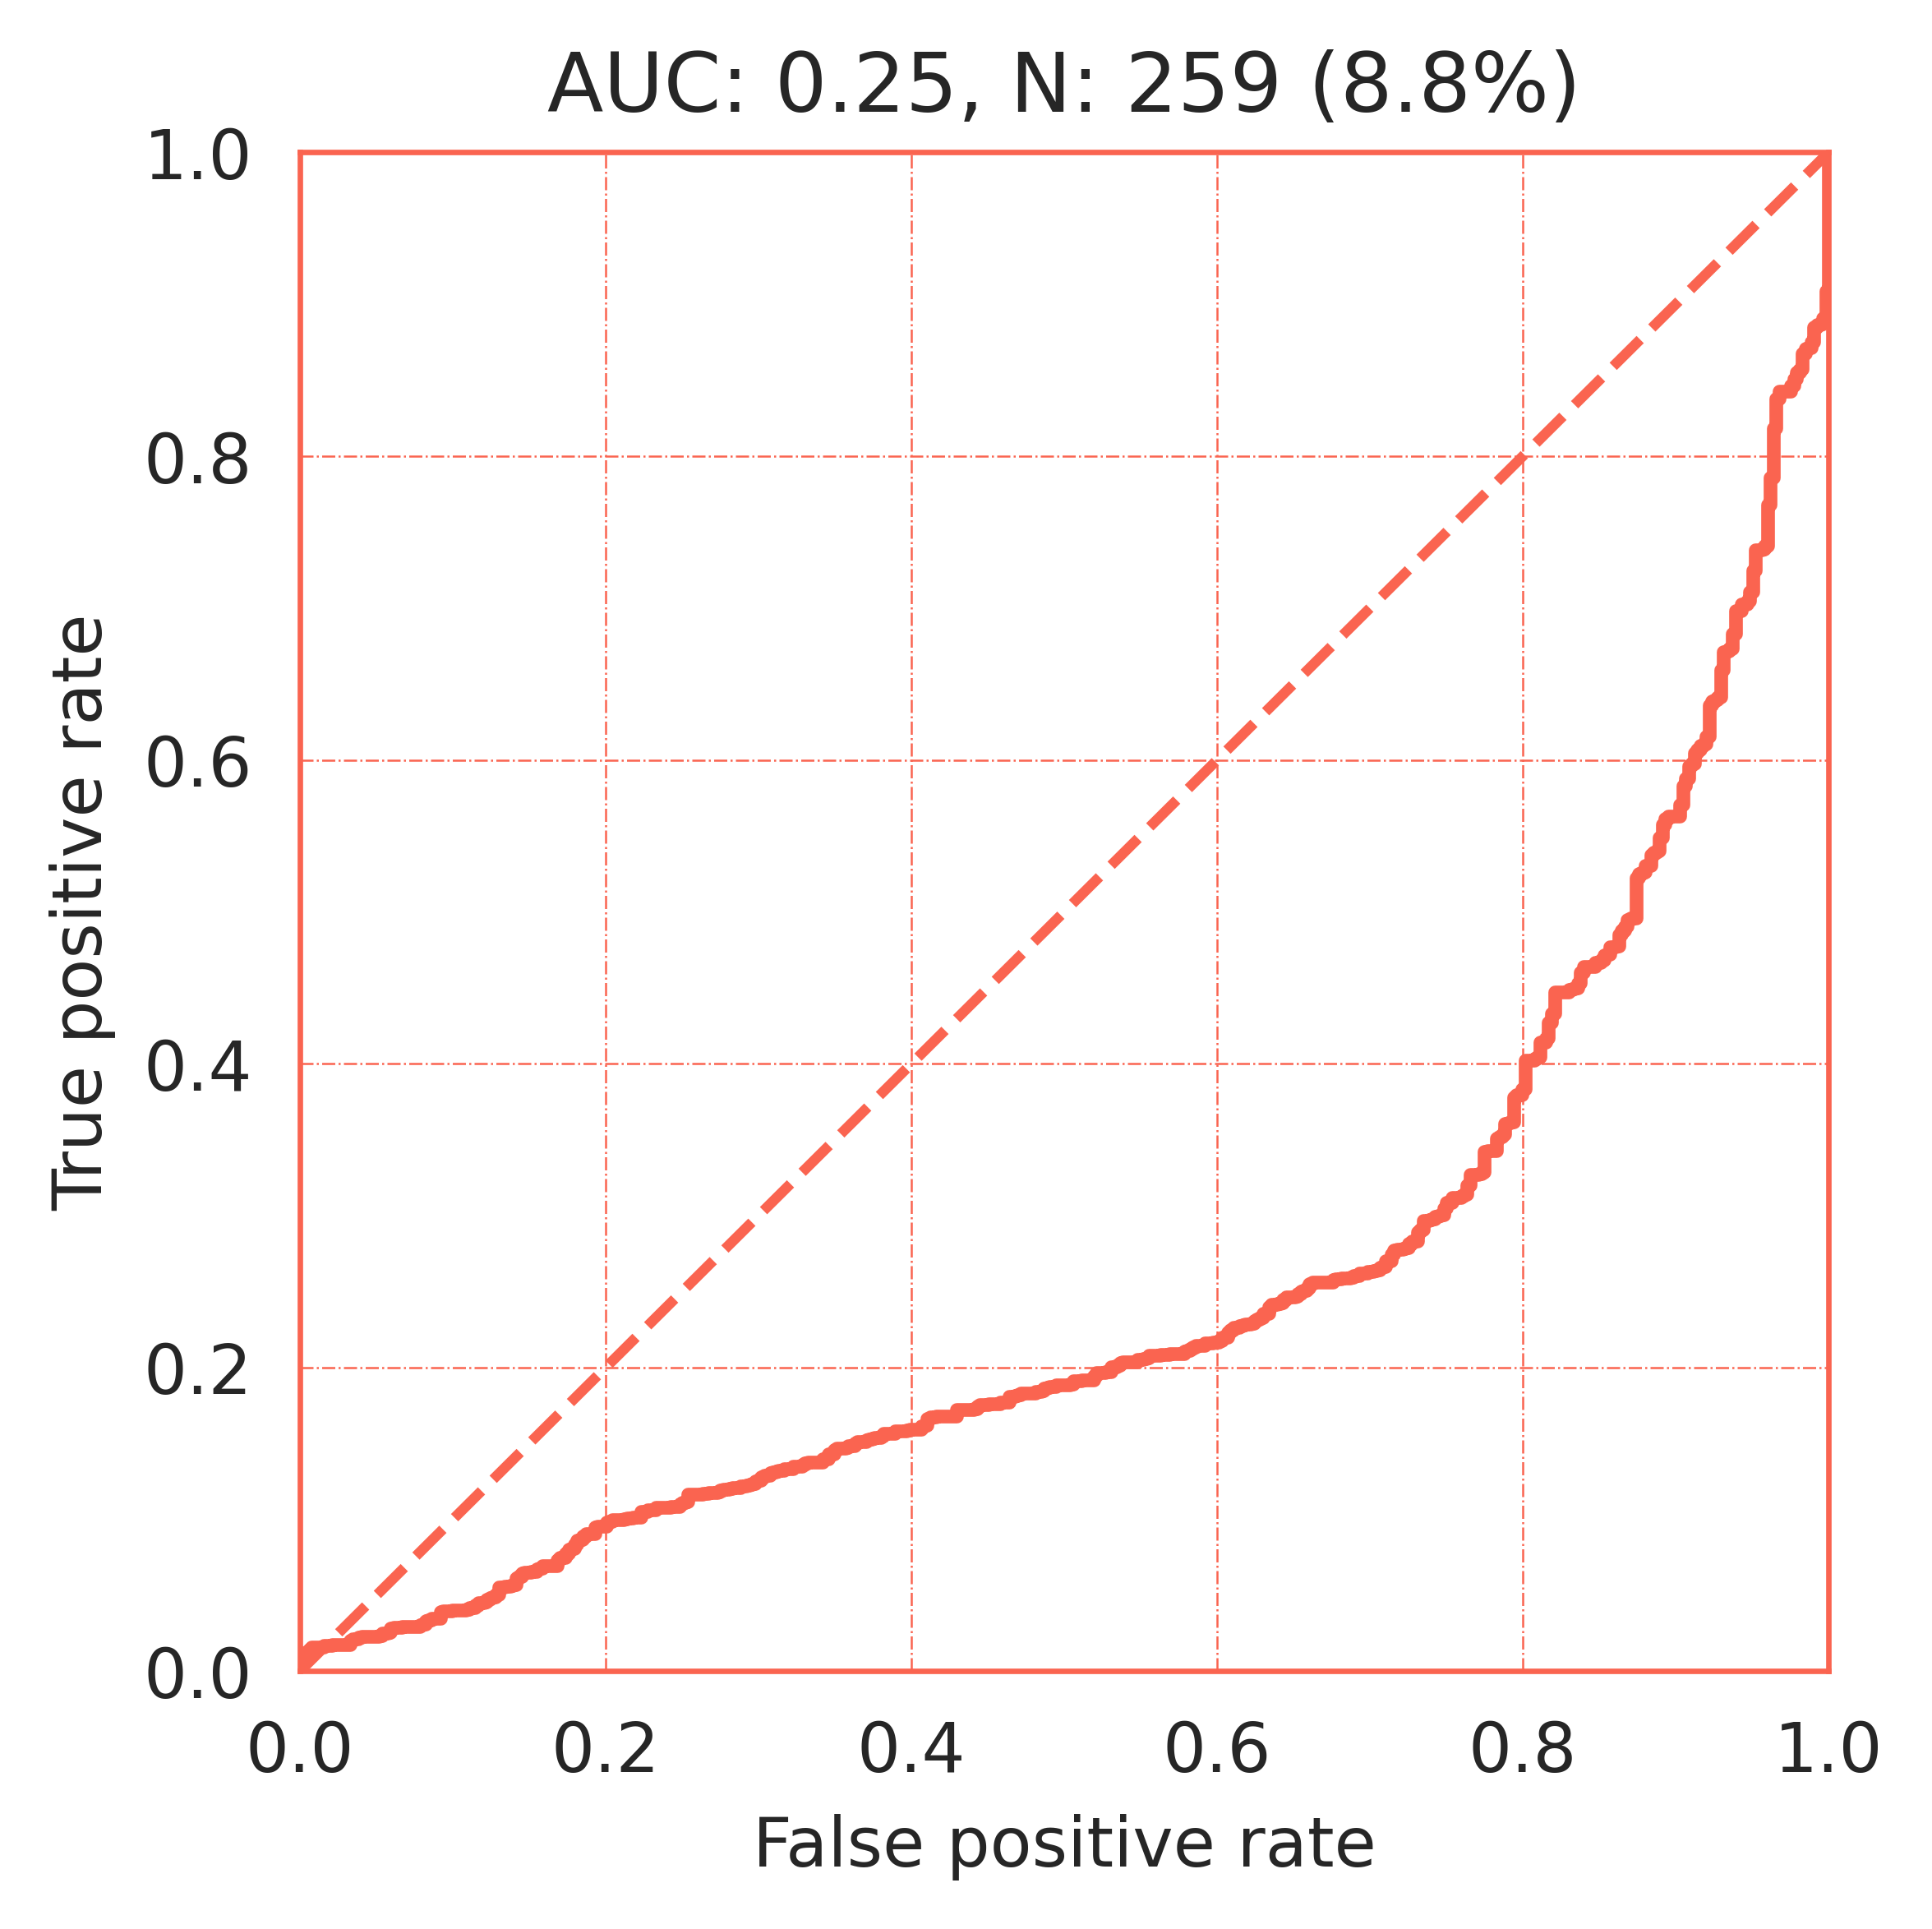

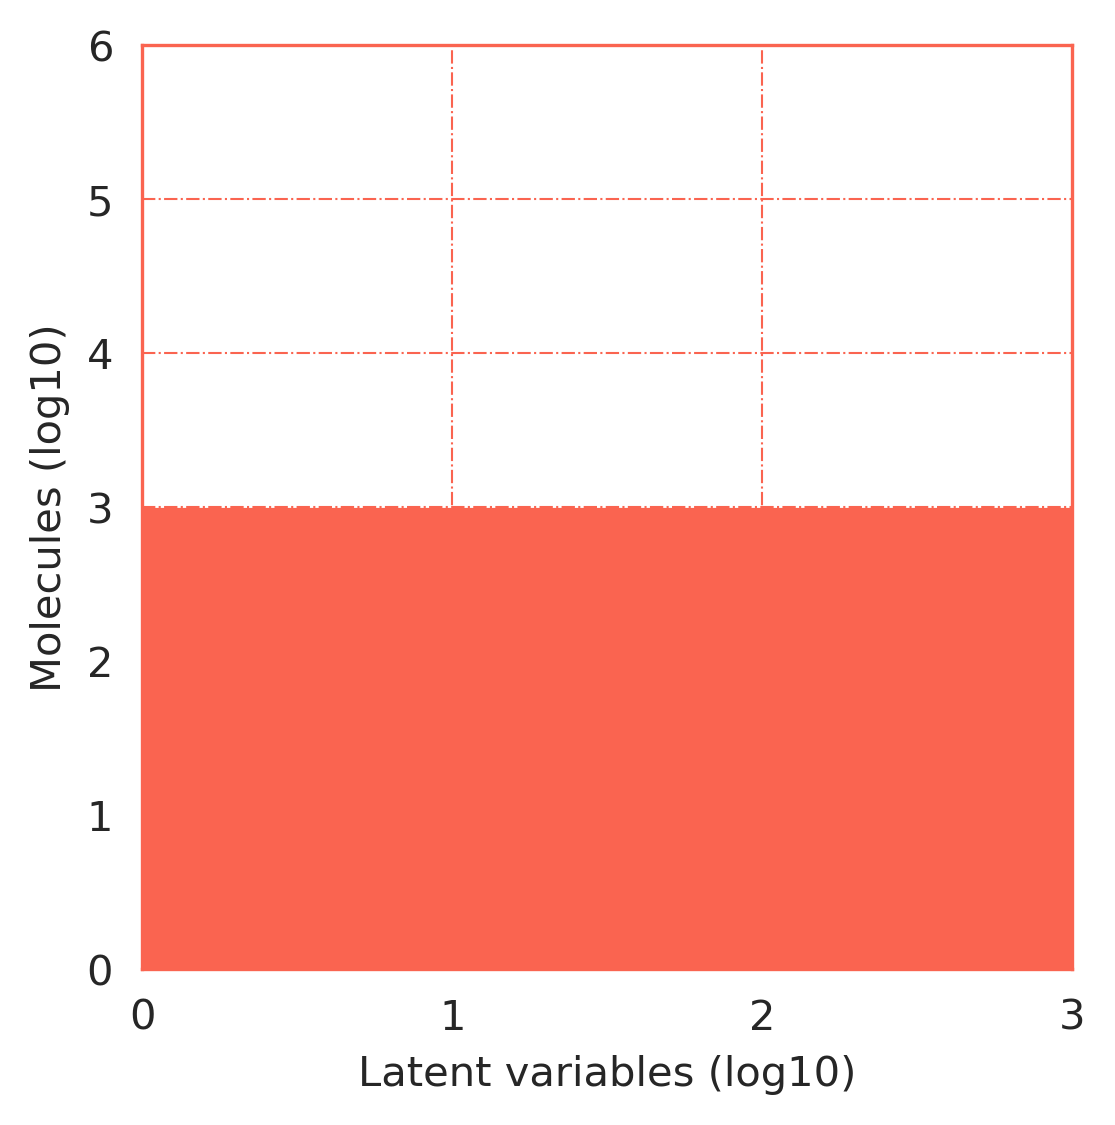

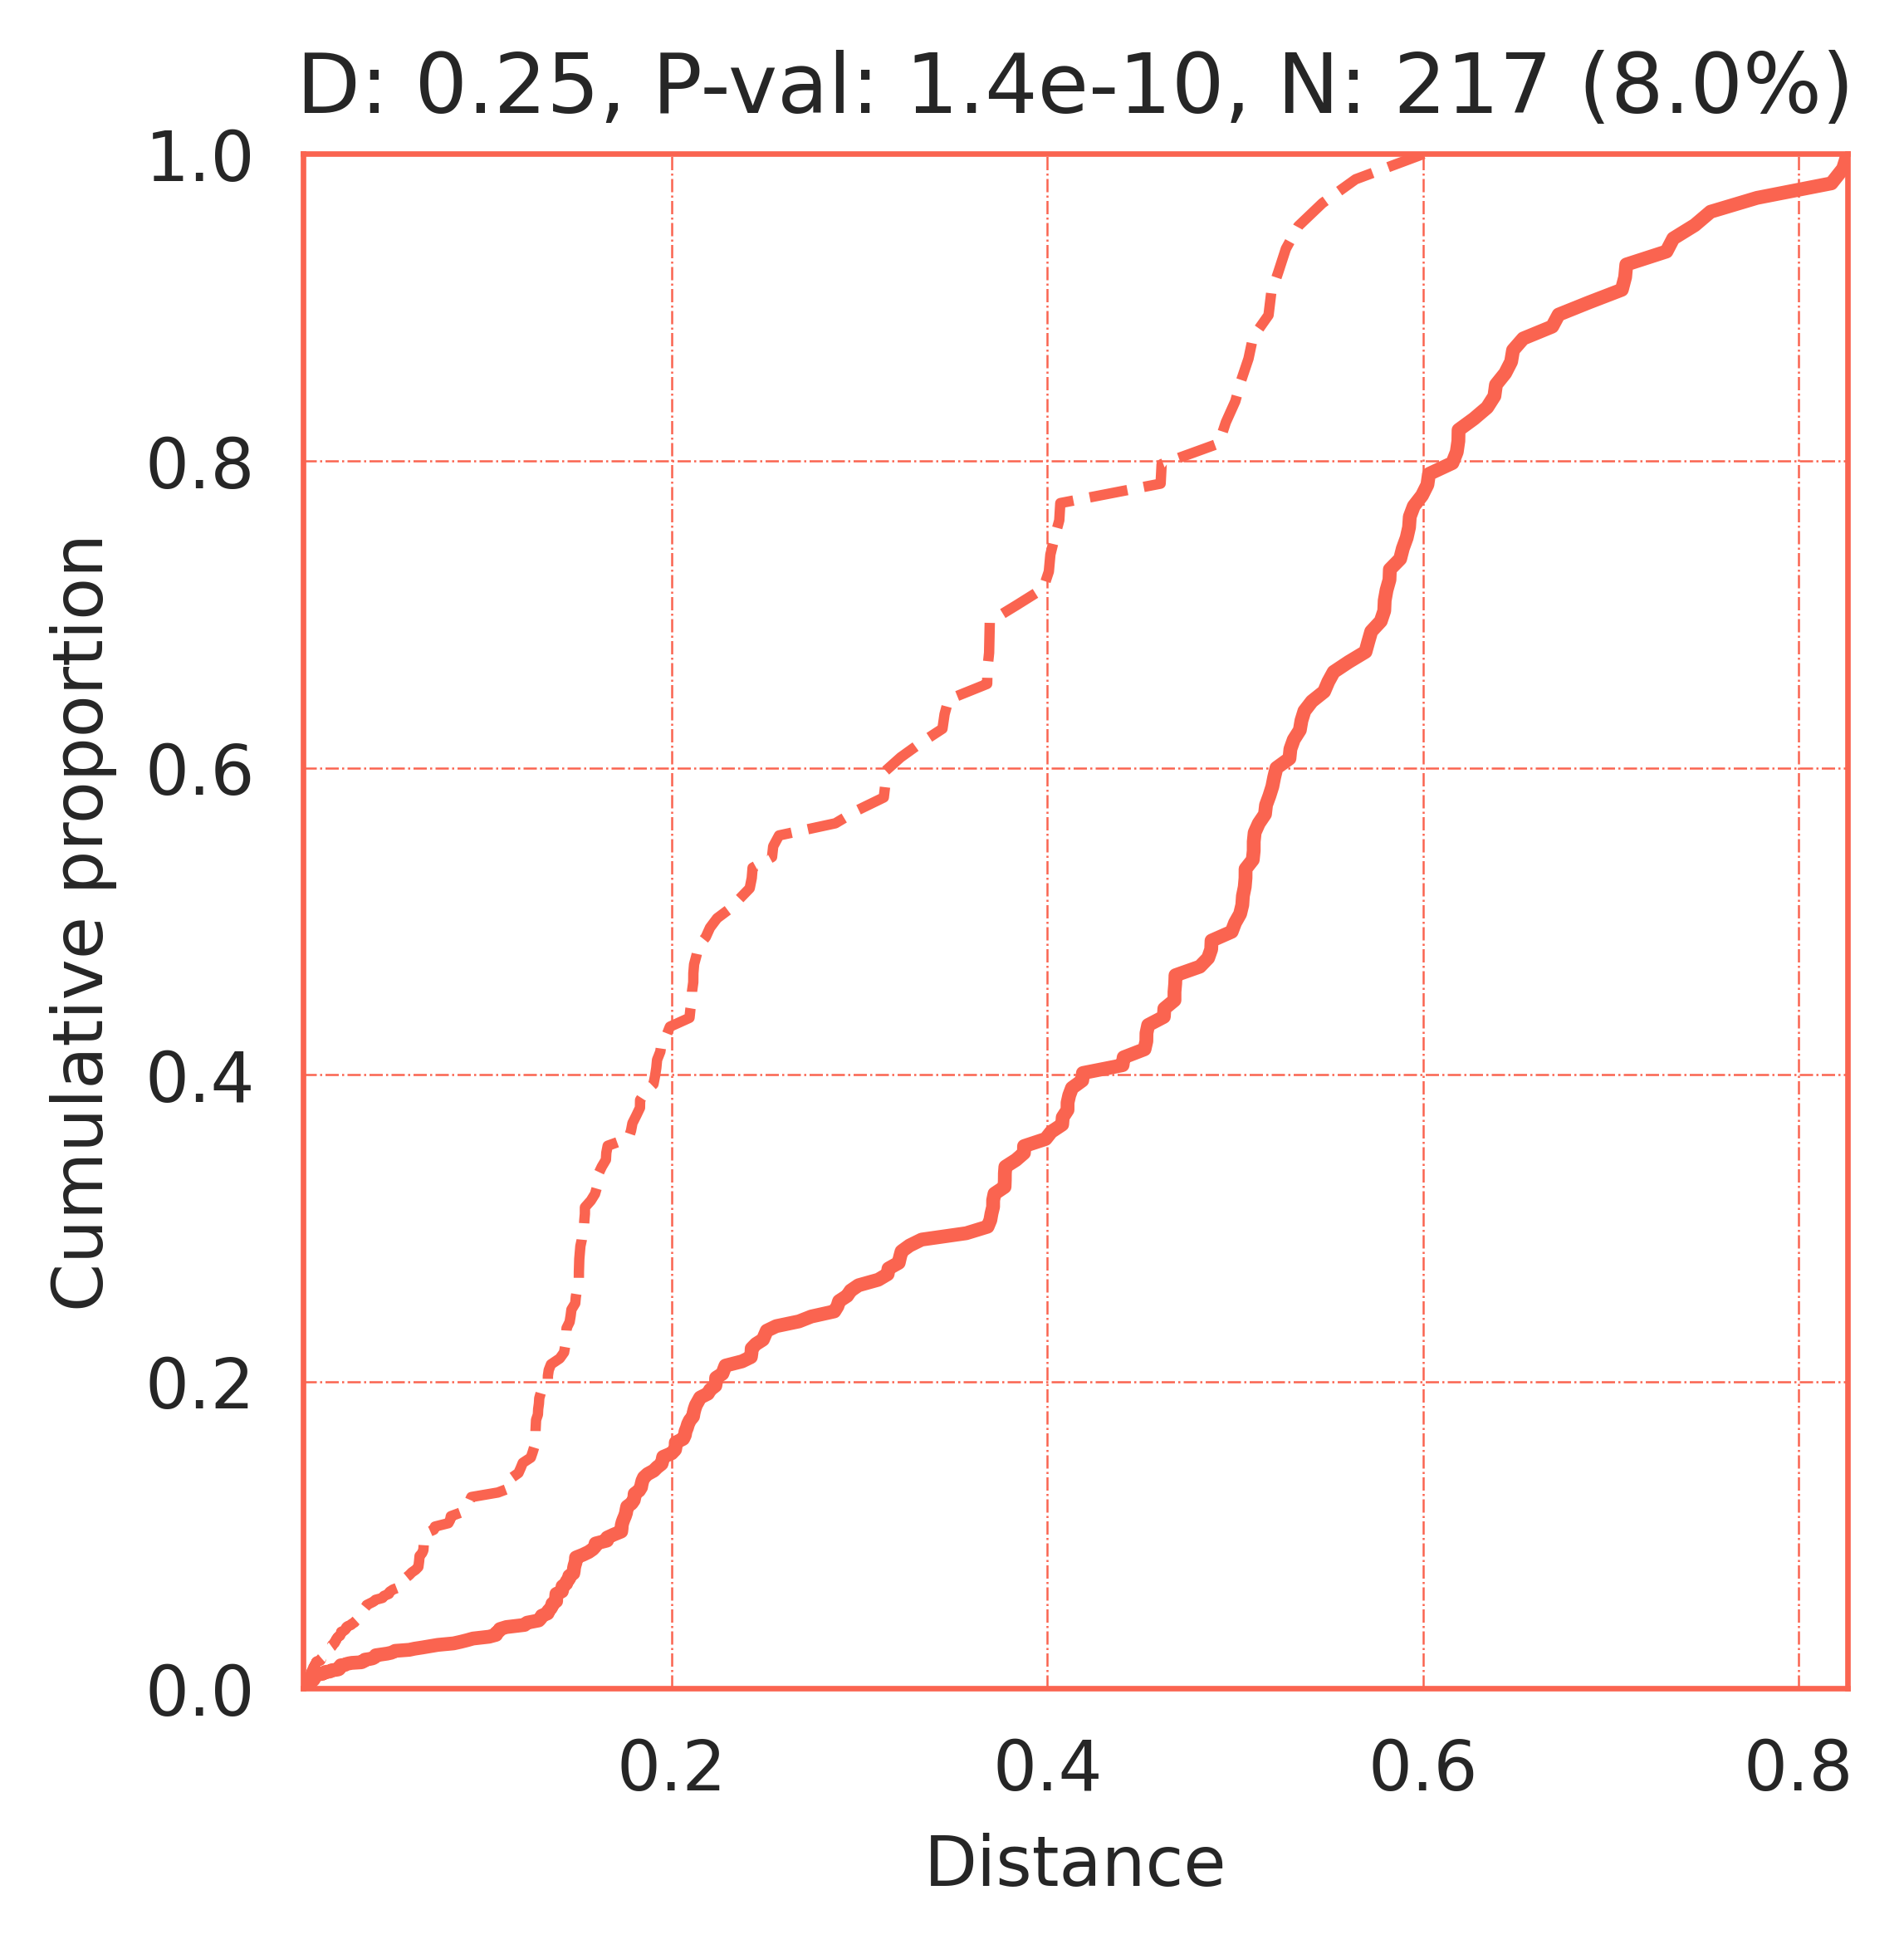

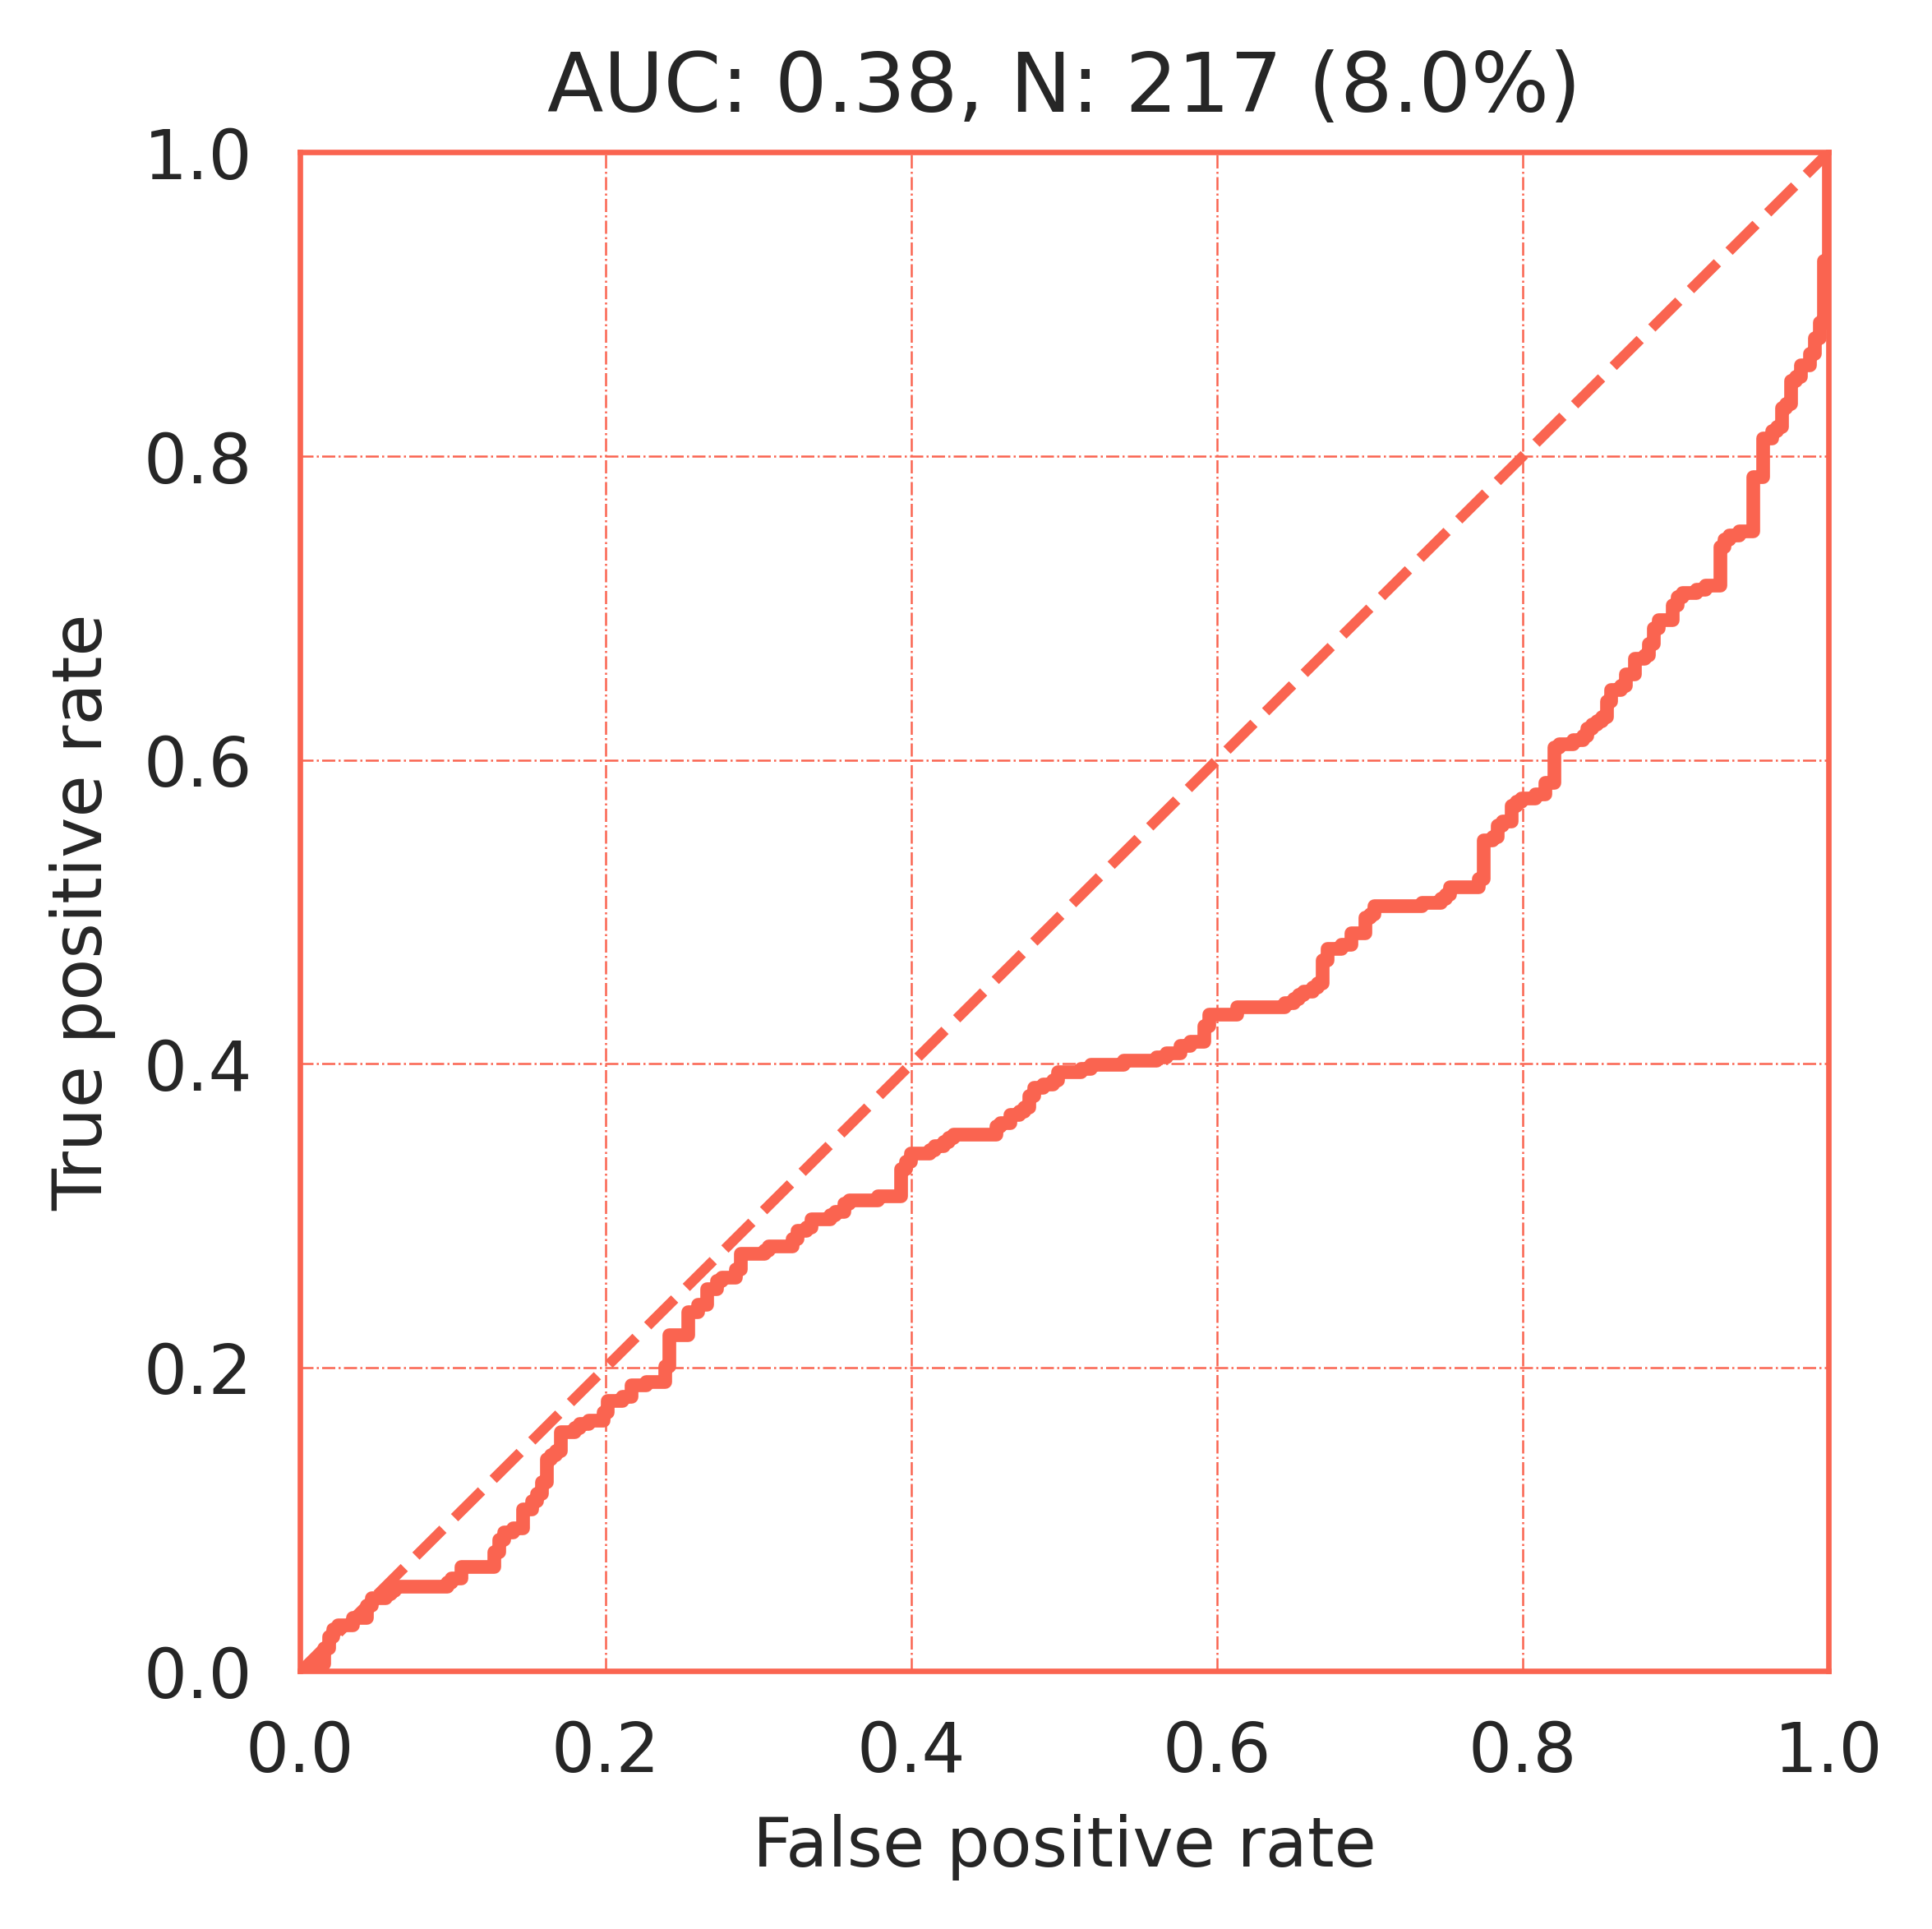

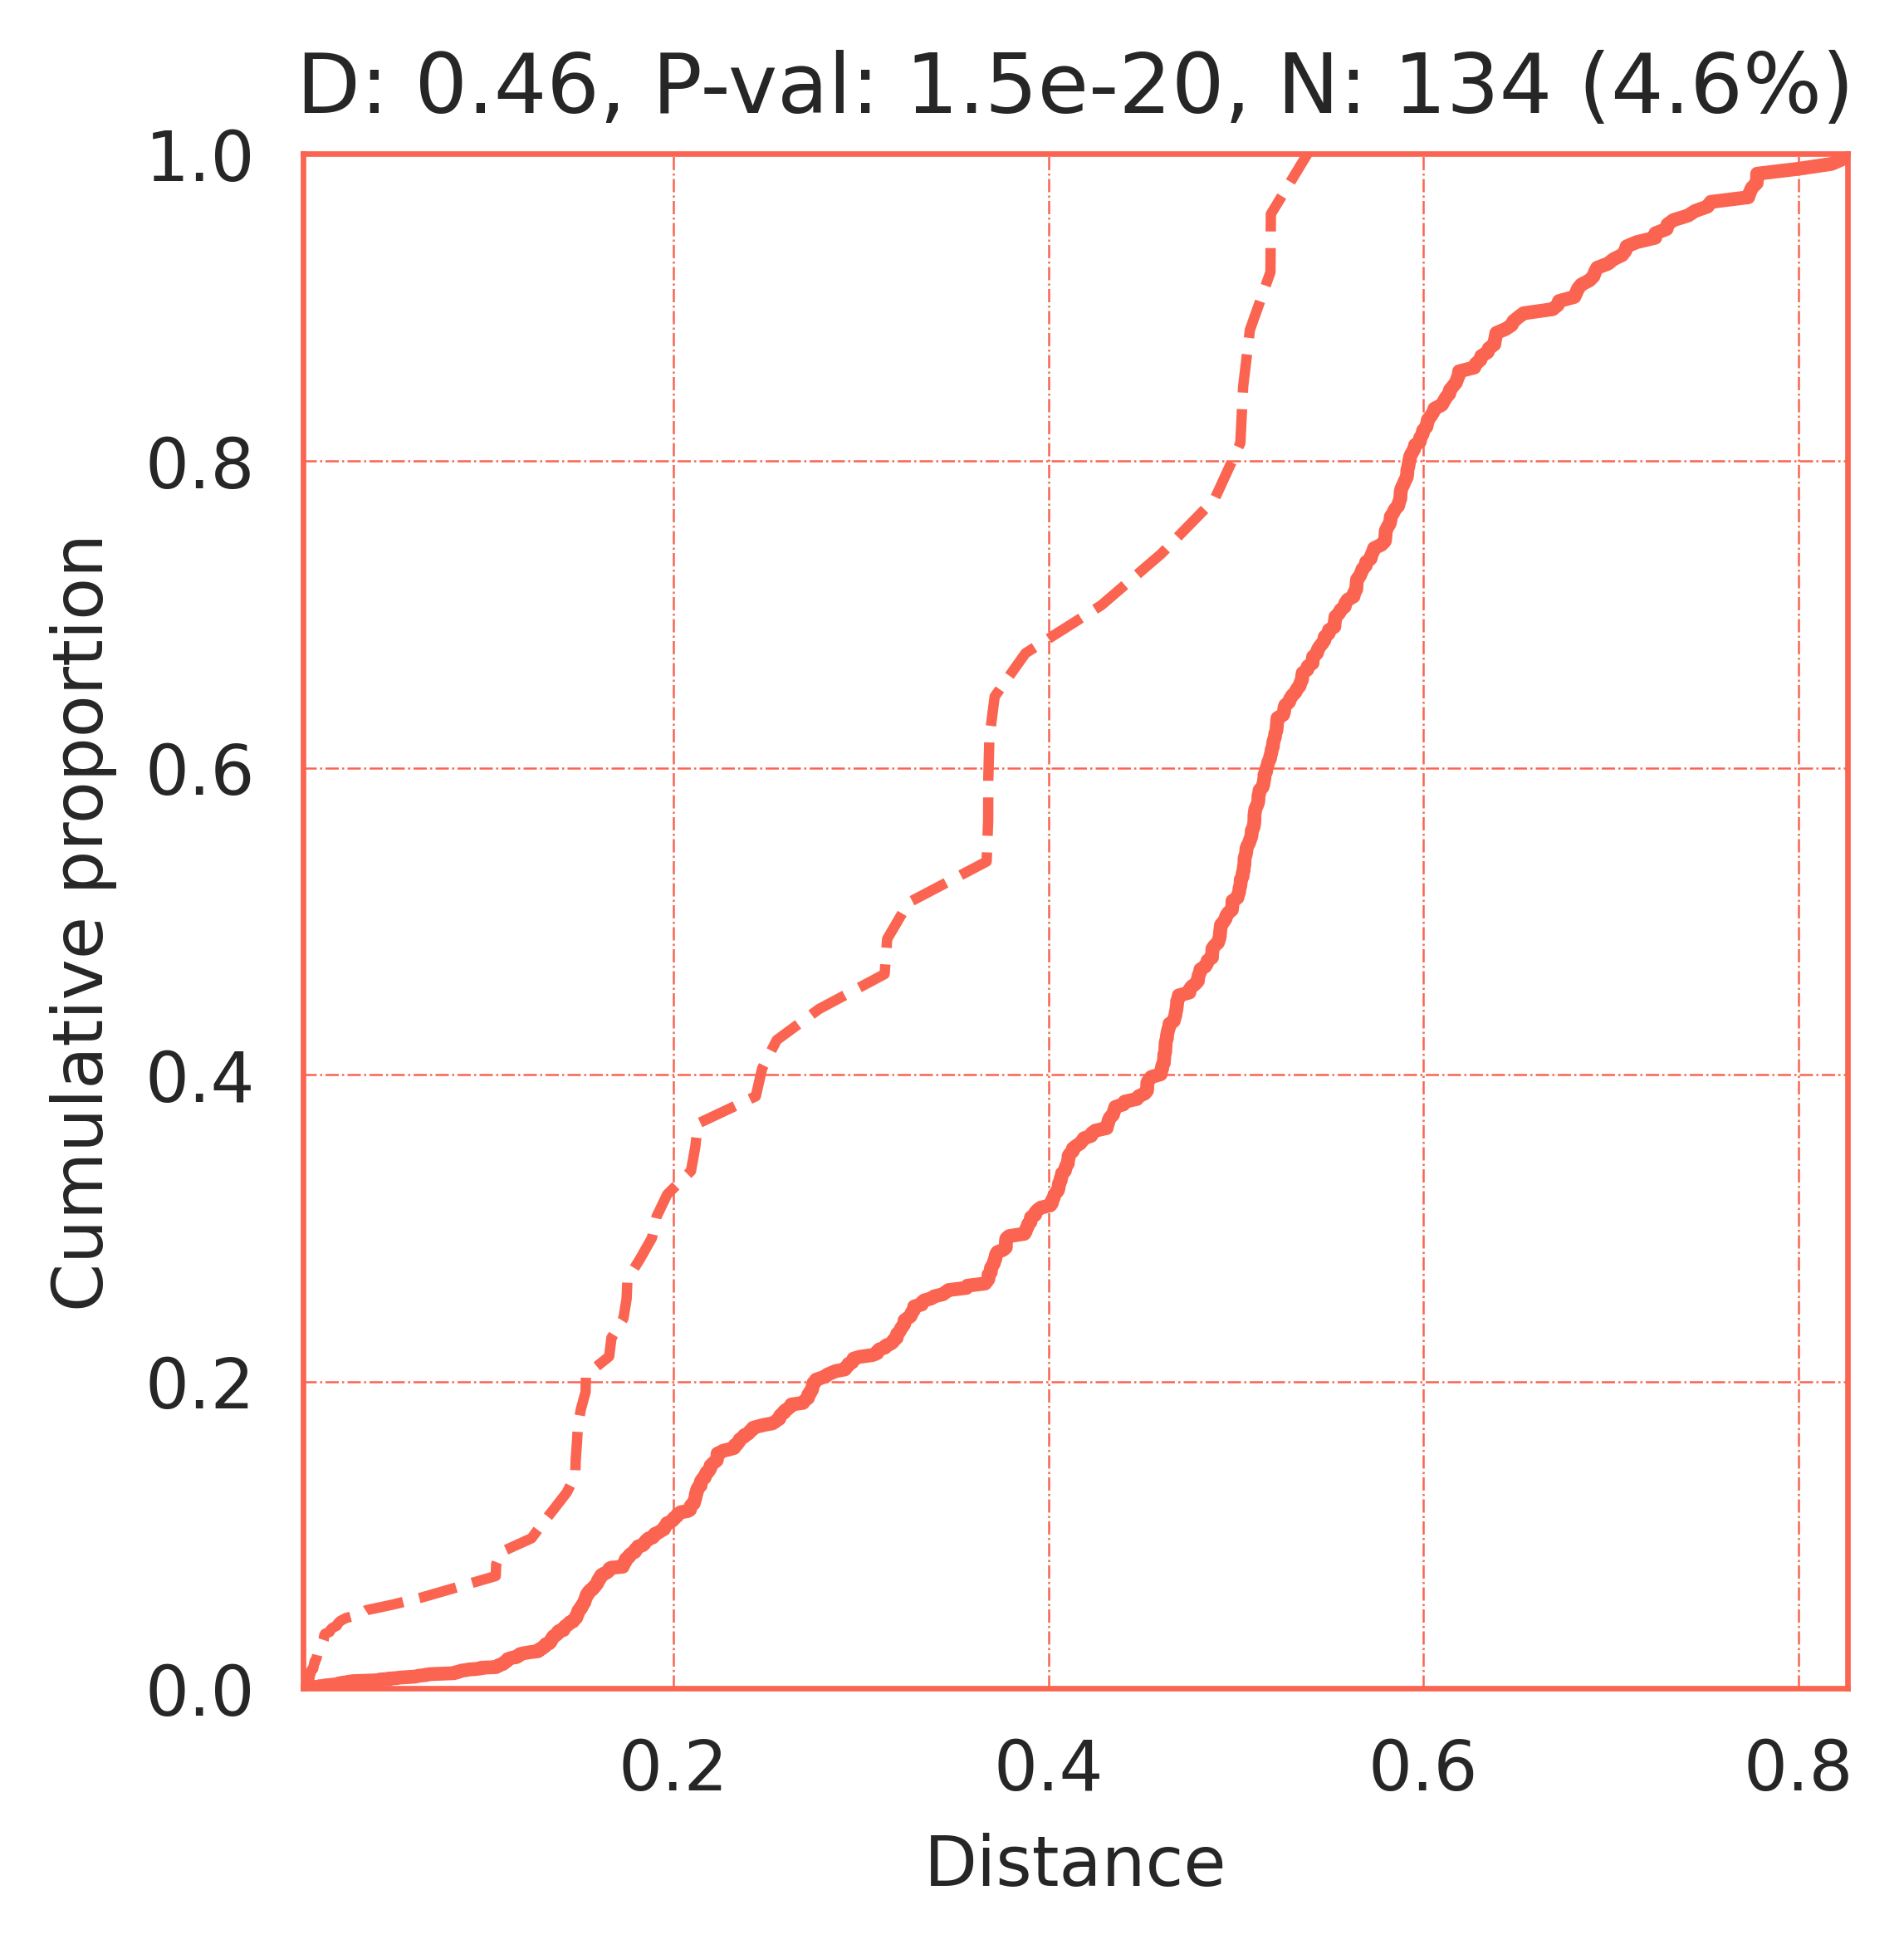

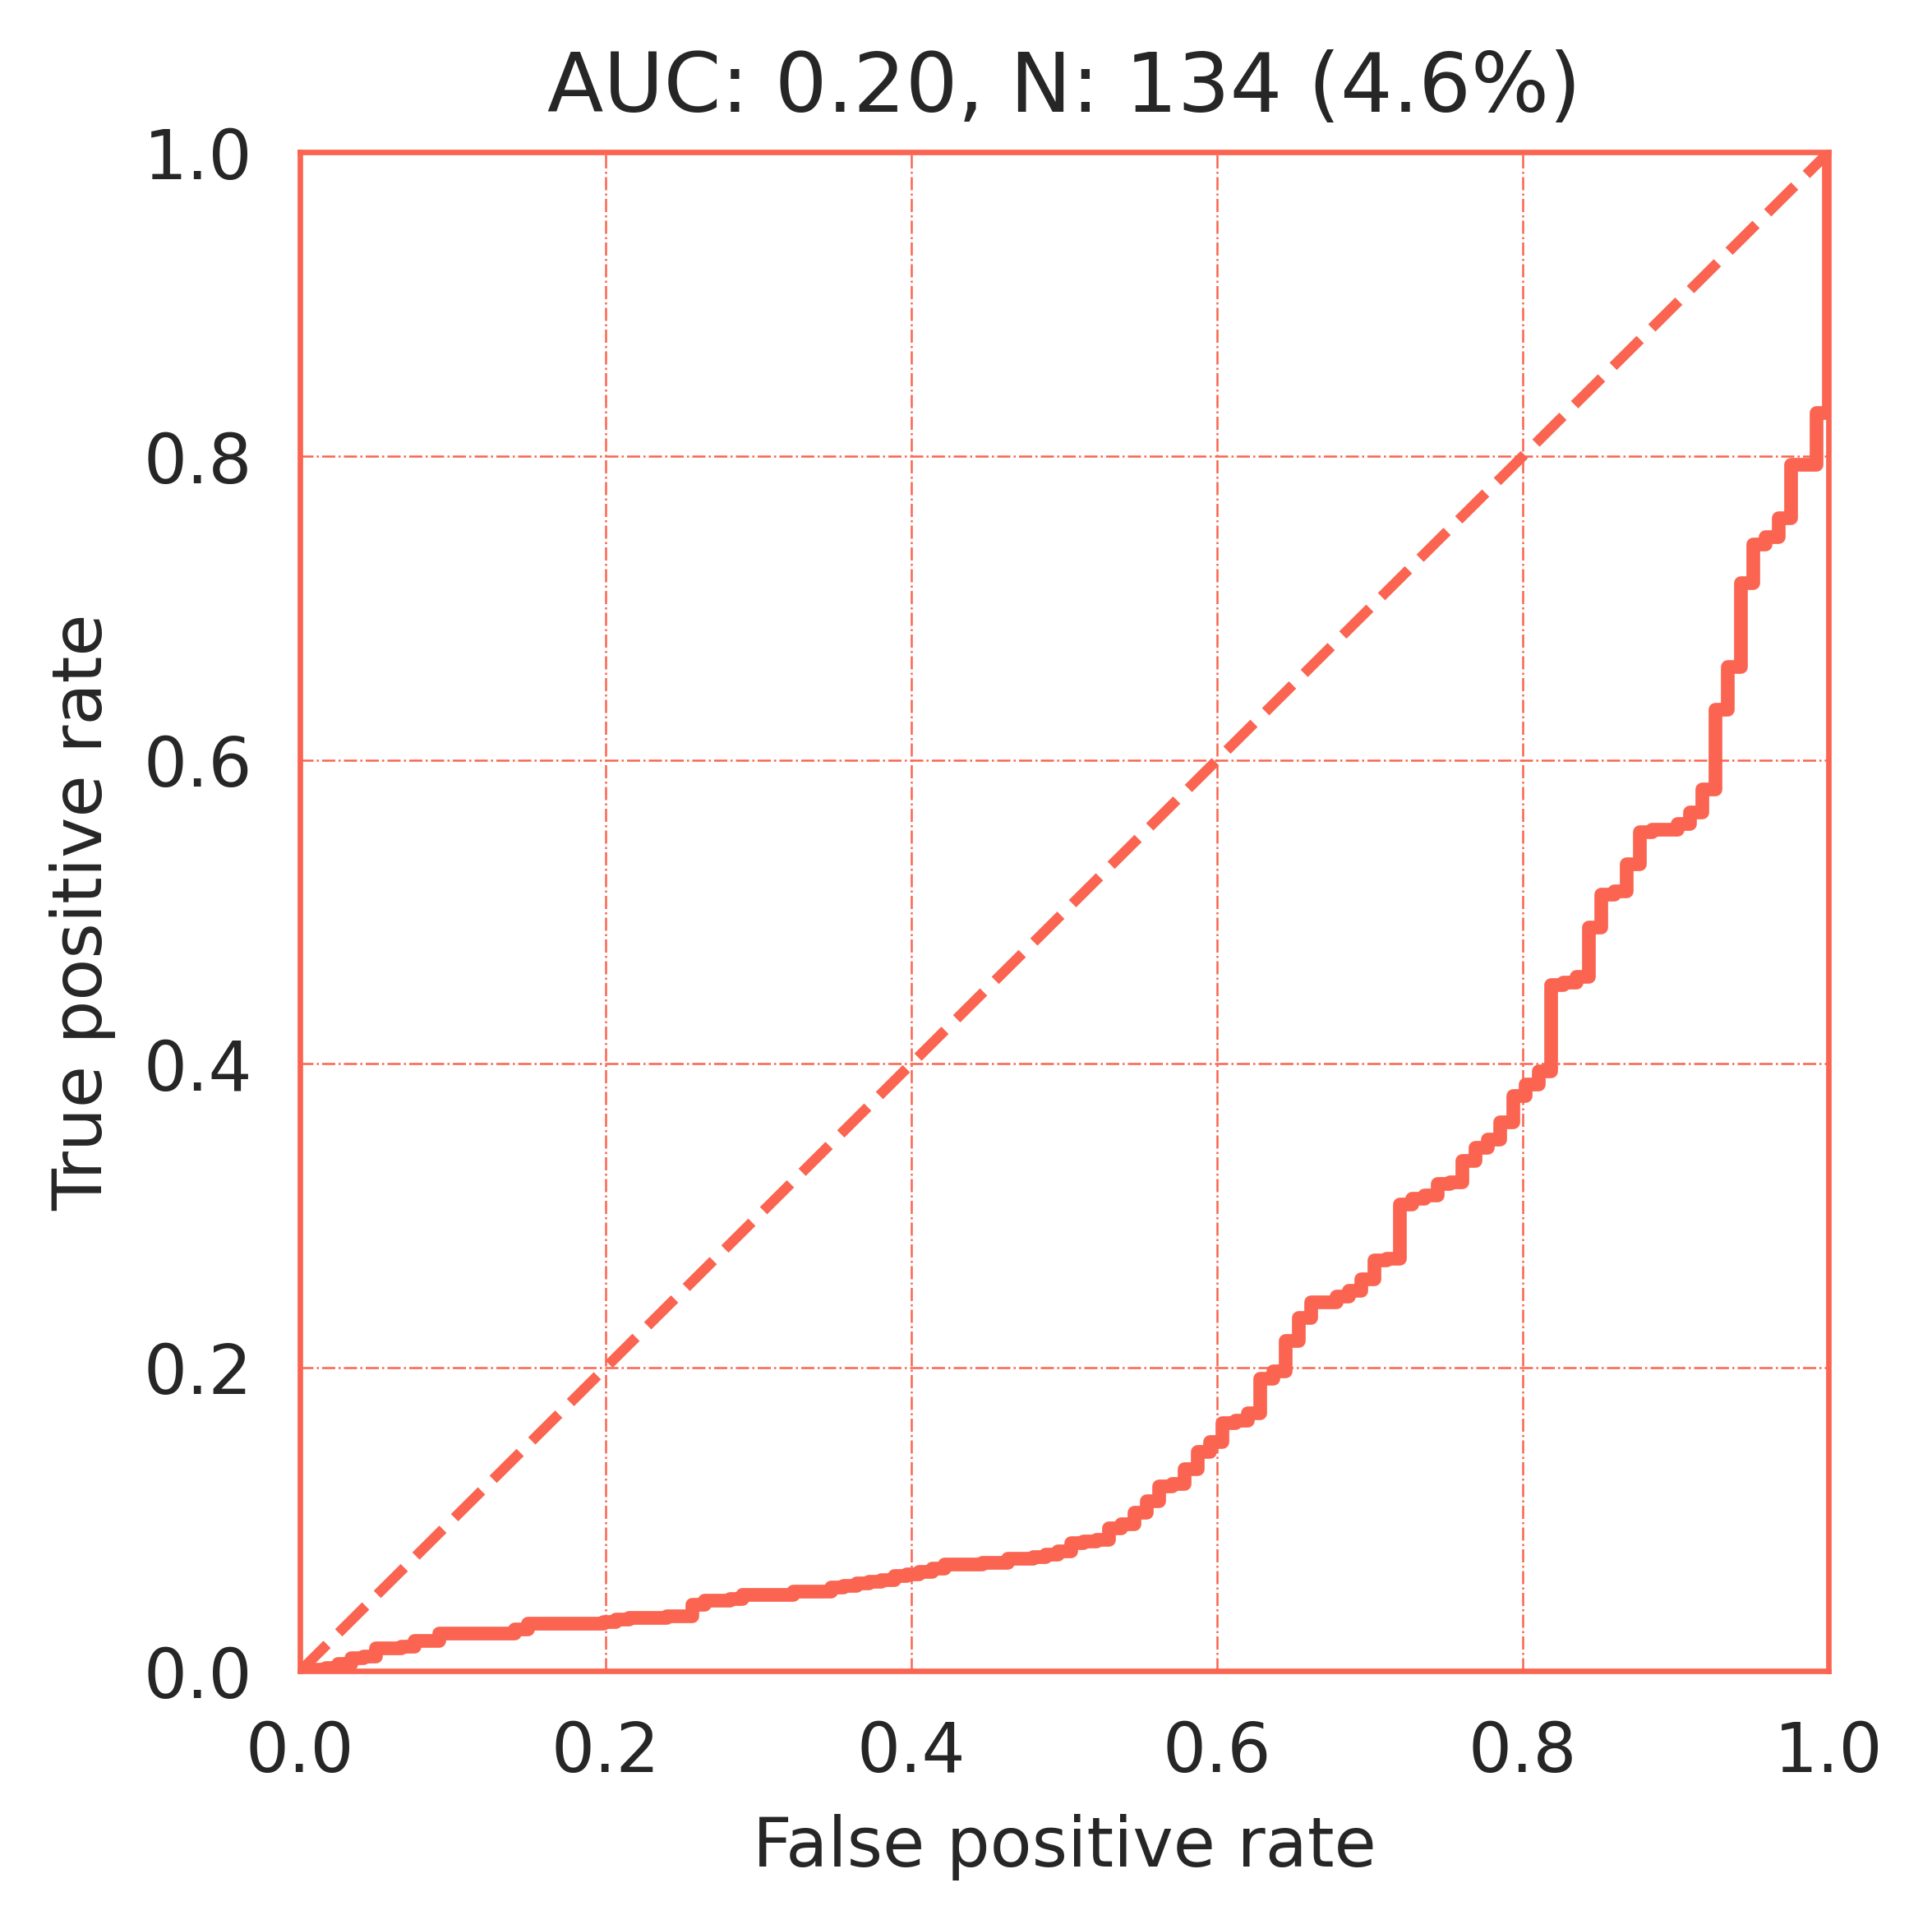

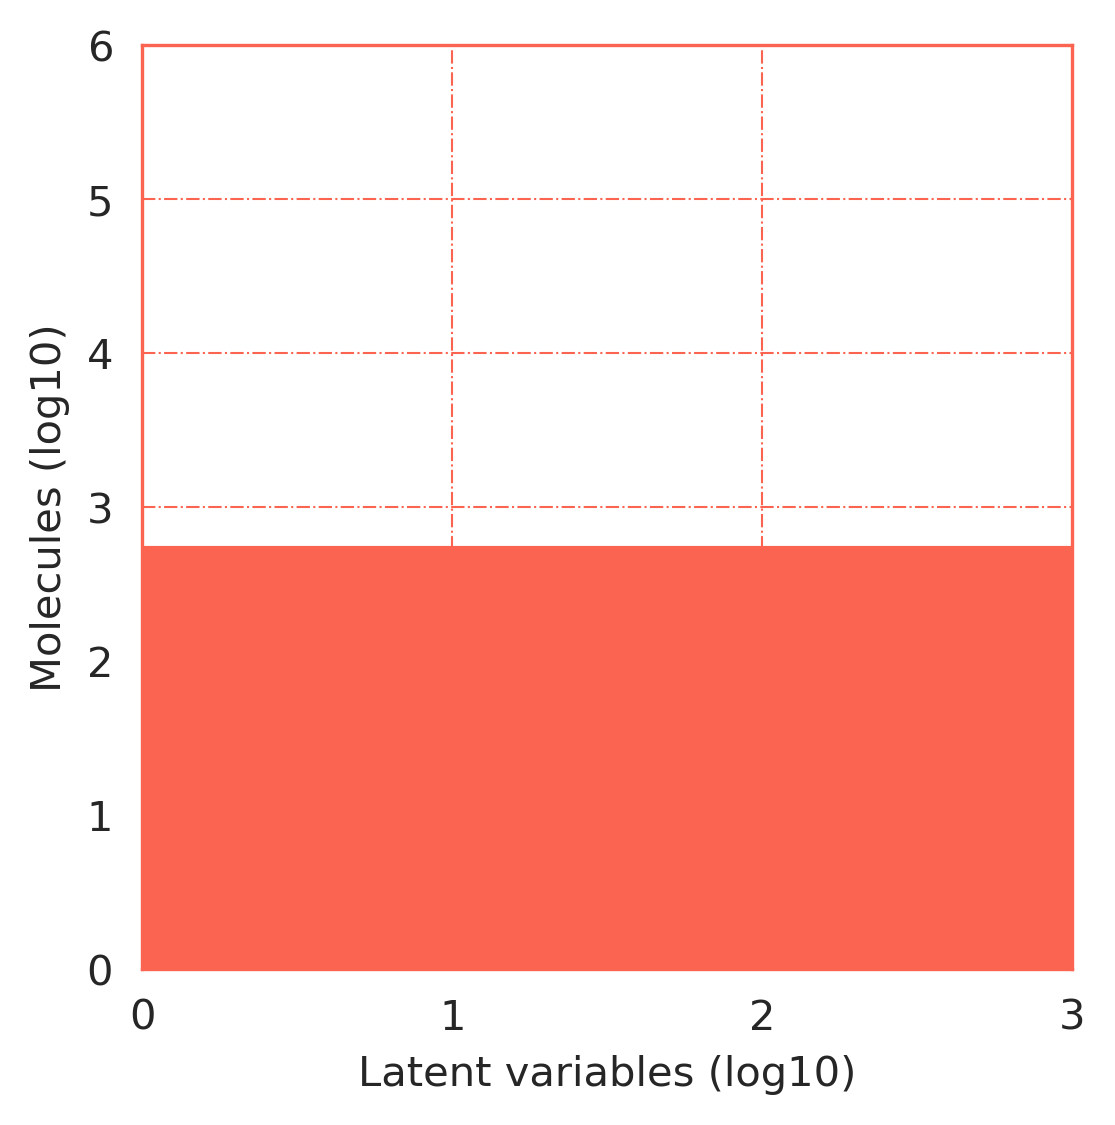

In [29]:
# Cleaning both full and reference datasets. This is crucial!
sign0_allprot.clear_all()

# Fit sign0
sign0_allprot.fit(X=df_allprot.values, keys=list(df_allprot.index), features=list(df_allprot.columns), sanitizer_kwargs=sanitizer_kwargs)

In [30]:
sign0_allprot.shape

(956, 10000)

2026-08-27 10:25:51,618 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 10:25:51,667 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2026-08-27 10:25:51,668 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2026-08-27 10:25:51,668 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2026-08-27 10:25:51,670 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2026-08-27 10:25:51,670 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=956)
2026-08-27 10:25:51,671 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2026-08-27 10:25:52,308 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Saving signature subsample /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sign0/diags/local_PertP

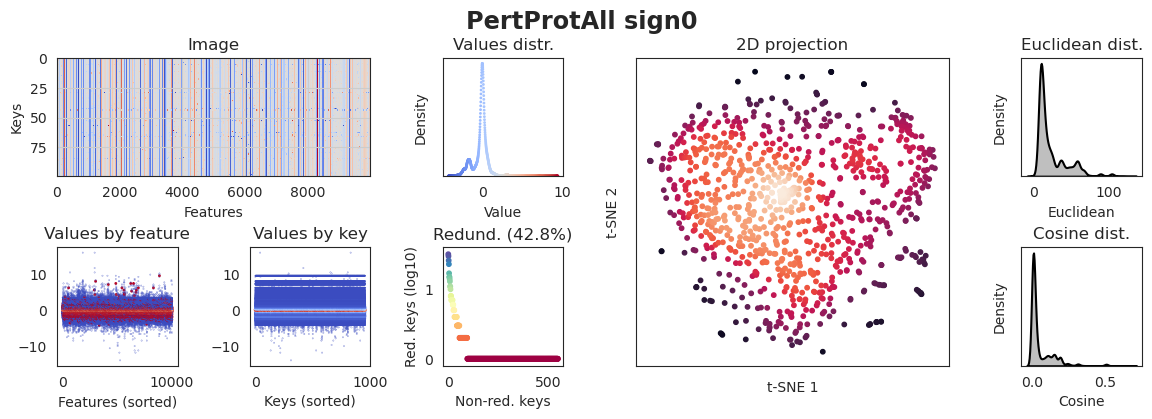

In [31]:
# Instantiation of diag0 (diagnosis plots)
diag0_allprot = sign0_allprot.diagnosis()

# Plot small diagnosis plots
diag0_allprot.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [21]:
np.min(np.array(sign0_allprot).flatten()), np.max(np.array(sign0_allprot).flatten())

(-14.21, 16.02)

## sign1

In [48]:
# Instantiation of sign1 data structures for the new spaces: full and references
sign1_deps = cc_local.signature(dataset_deps, 'sign1')
sign1_allprot = cc_local.signature(dataset_all, 'sign1')
sign1_dcmoa = cc_local.signature(dataset_dcmoa, 'sign1')

2026-08-27 11:22:49,024 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign1
2026-08-27 11:22:49,027 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtAll/sign1
2026-08-27 11:22:49,030 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/sign1


### DeepCoverMoa

In [ ]:
# Cleaning both full and reference datasets. This is crucial!
sign1_dcmoa.clear_all()

# Fitting sign1
sign1_dcmoa.fit(sign0_dcmoa)

In [50]:
sign1_dcmoa.shape

(872, 543)

2026-08-27 11:27:39,362 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 11:27:39,417 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2026-08-27 11:27:39,418 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2026-08-27 11:27:39,418 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2026-08-27 11:27:39,419 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2026-08-27 11:27:39,420 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=872)
2026-08-27 11:27:39,421 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2026-08-27 11:27:39,466 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Saving signature subsample /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/sign1/diags/local_Pert

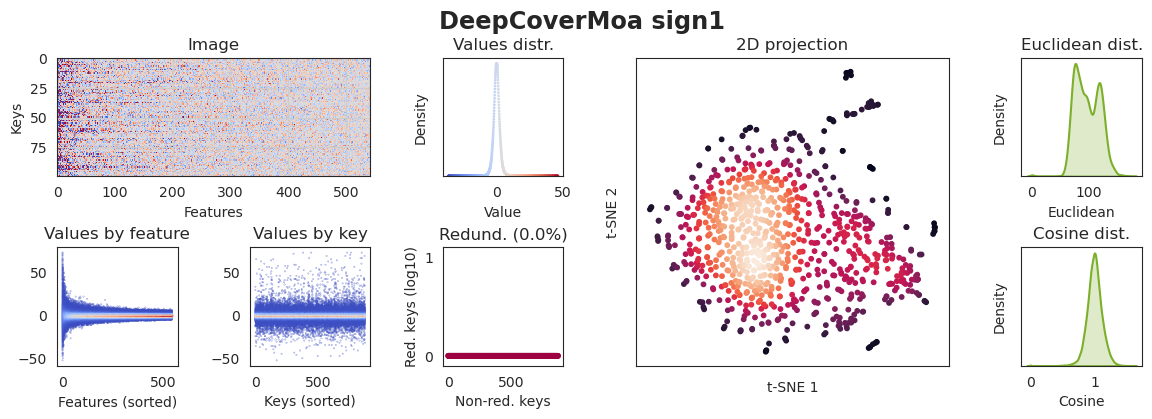

In [51]:
# Instantiation of diag1 (diagnosis plots)
diag1_dcmoa = sign1_dcmoa.diagnosis()

# Plot medium & small diagnosis plots
diag1_dcmoa.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [52]:
# Instantiation of neig1
neig1_dcmoa = cc_local.get_signature("neig1", "full", dataset_dcmoa)  # It will take the reference anyway...

# Cleaning both full and reference. This is crucial!
neig1_dcmoa.clear_all()

# Fitting neig1
neig1_dcmoa.fit(sign1_dcmoa)

2026-08-27 11:28:38,338 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/neig1
2026-08-27 11:28:38,342 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/neig1
2026-08-27 11:28:38,343 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /scratch/sbnb/sayala/protocols/local_PertProt/full/D/De/DeepCoverMoa/neig1/neig.h5
2026-08-27 11:28:38,346 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/reference/D/De/DeepCoverMoa/neig1
2026-08-27 11:28:38,350 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /scratch/sbnb/sayala/protocols/local_PertProt/reference/D/De/DeepCoverMoa/neig1
2026-08-27 11:28:38,350 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /scratch/sbnb/sayala/protocols/local_PertProt/reference/D/De/DeepCoverMoa/neig1/nei

In [53]:
neig1_dcmoa.shape

array([872, 872])

In [54]:
np.min(np.array(sign1_dcmoa).flatten()), np.max(np.array(sign1_dcmoa).flatten())

(-53.5860231613067, 74.09624270072167)

### DEPs

2026-08-27 10:30:17,658 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtDEPs/sign1
2026-08-27 10:30:17,662 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtDEPs/sign1
2026-08-27 10:30:17,667 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign1
2026-08-27 10:30:17,669 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign1
2026-08-27 10:30:18.271624: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /.singularity.d/libs
2026-08-2

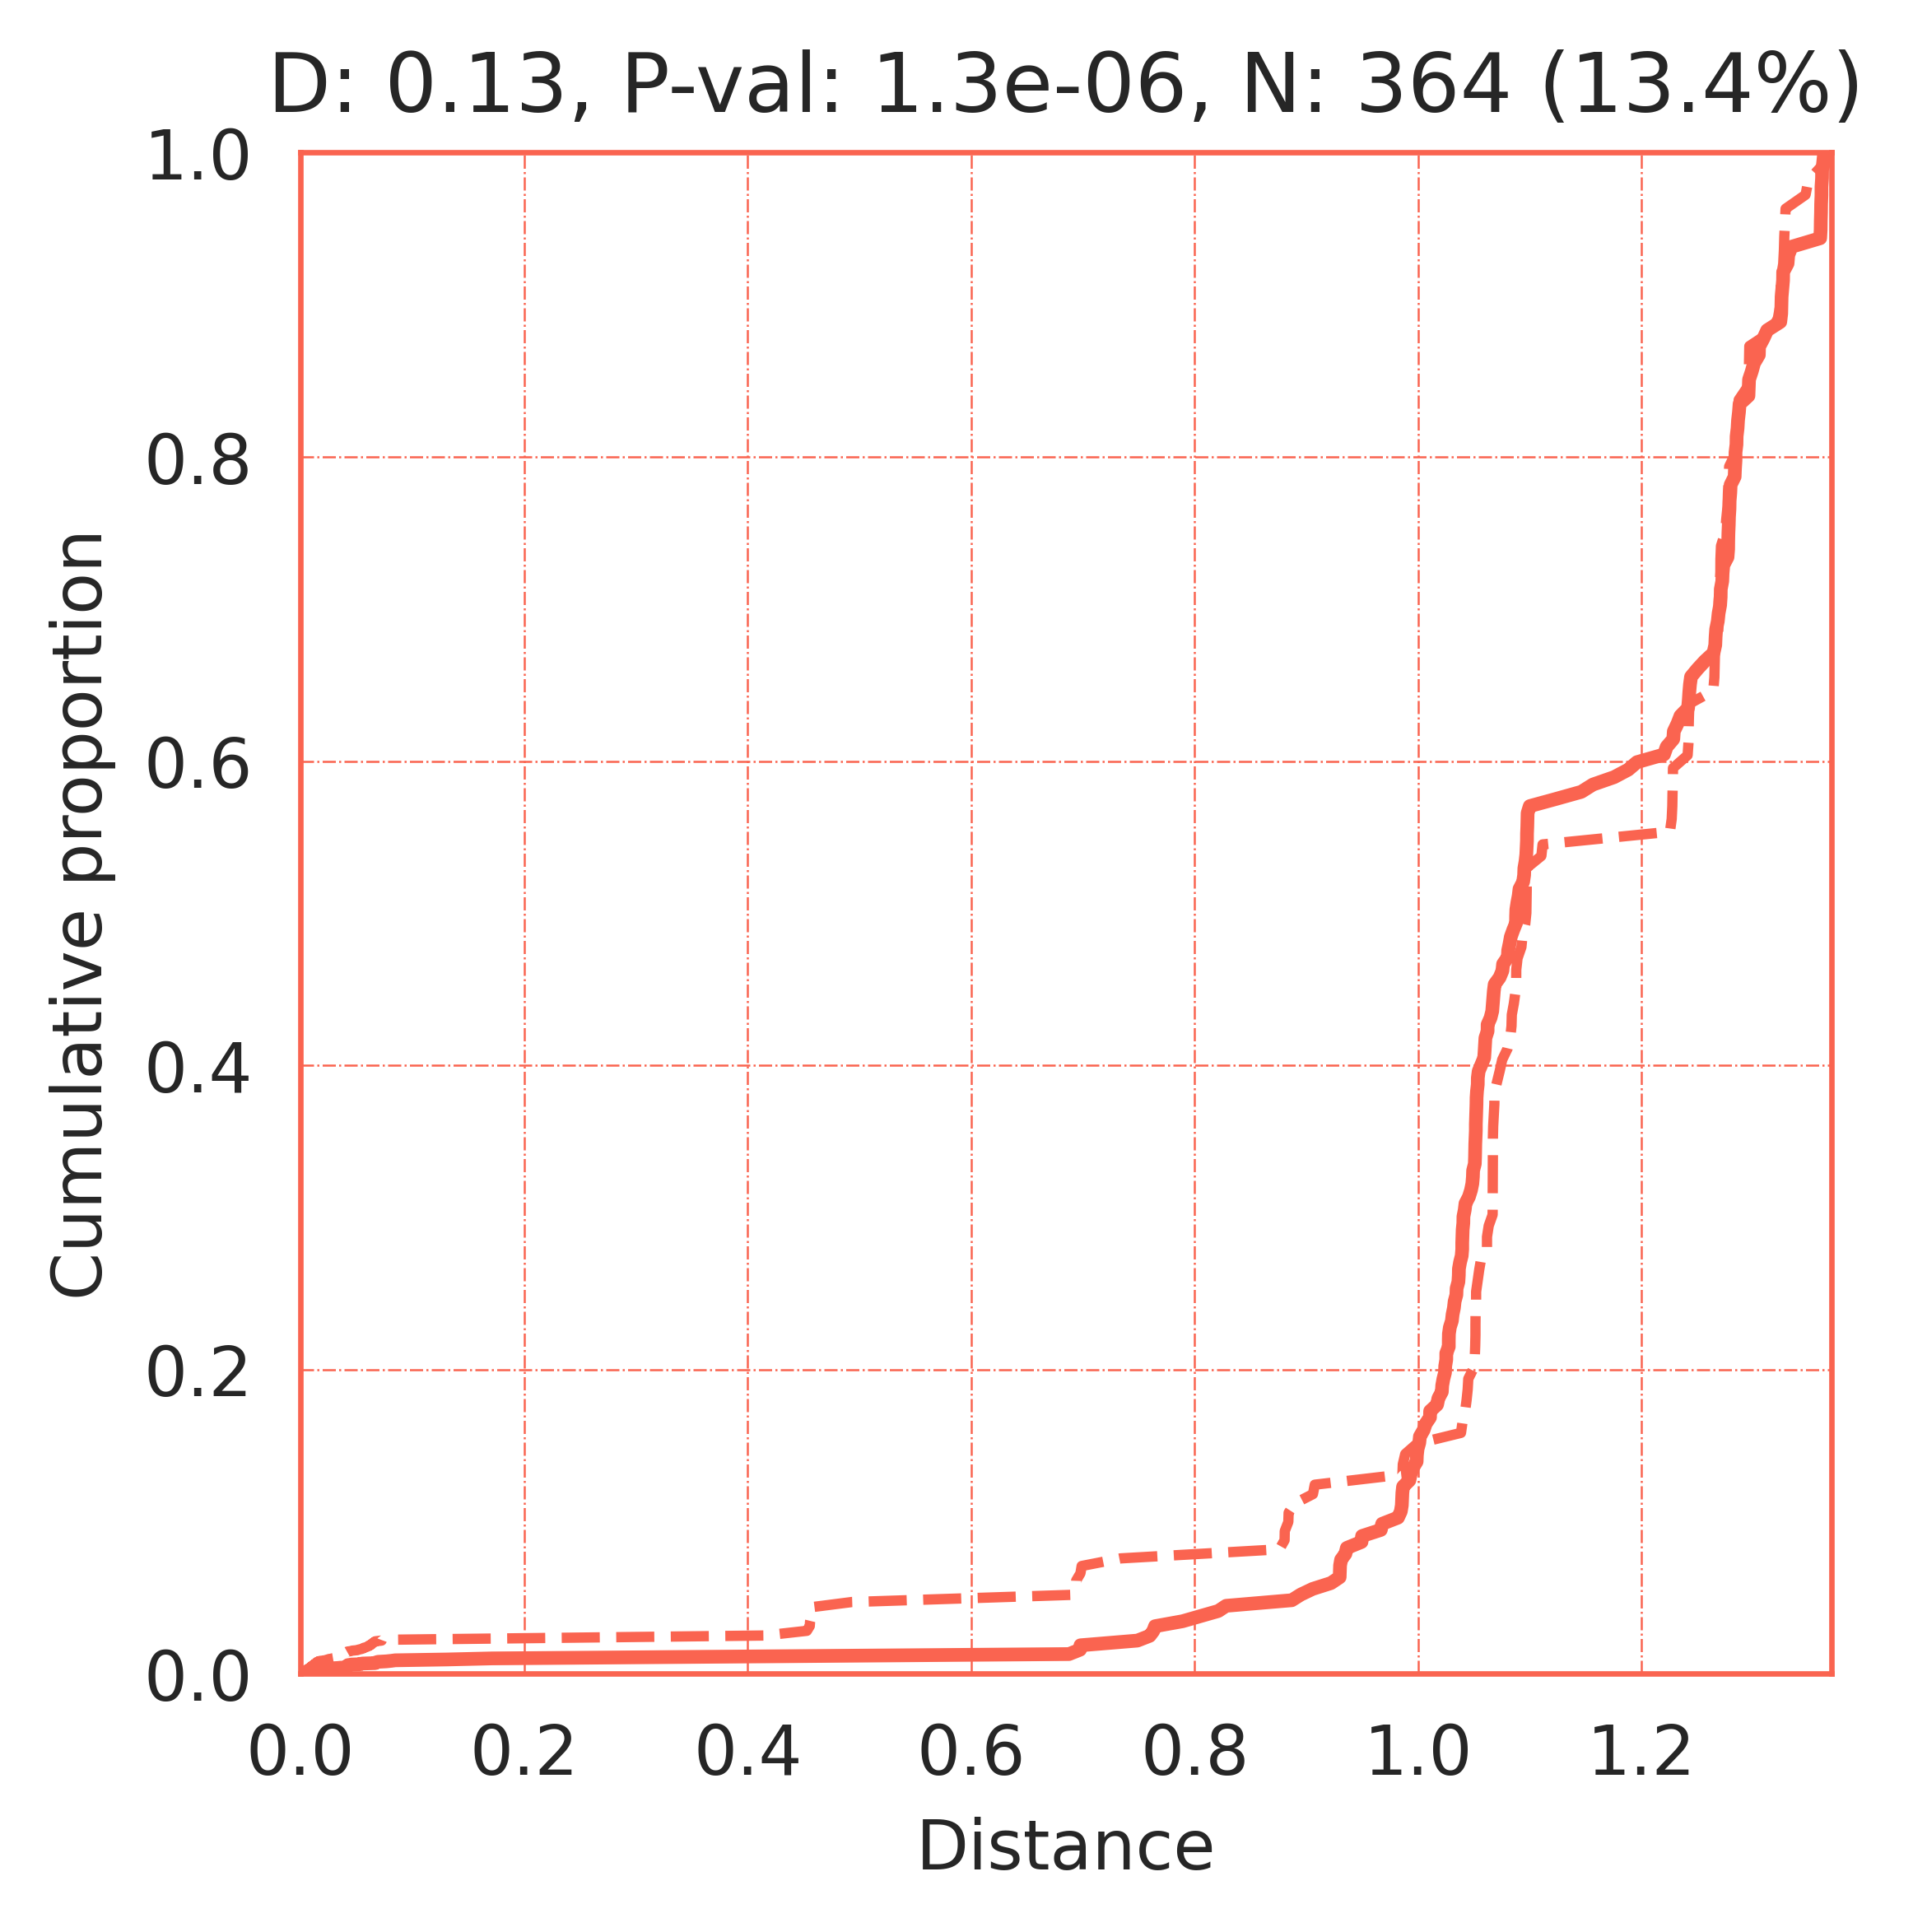

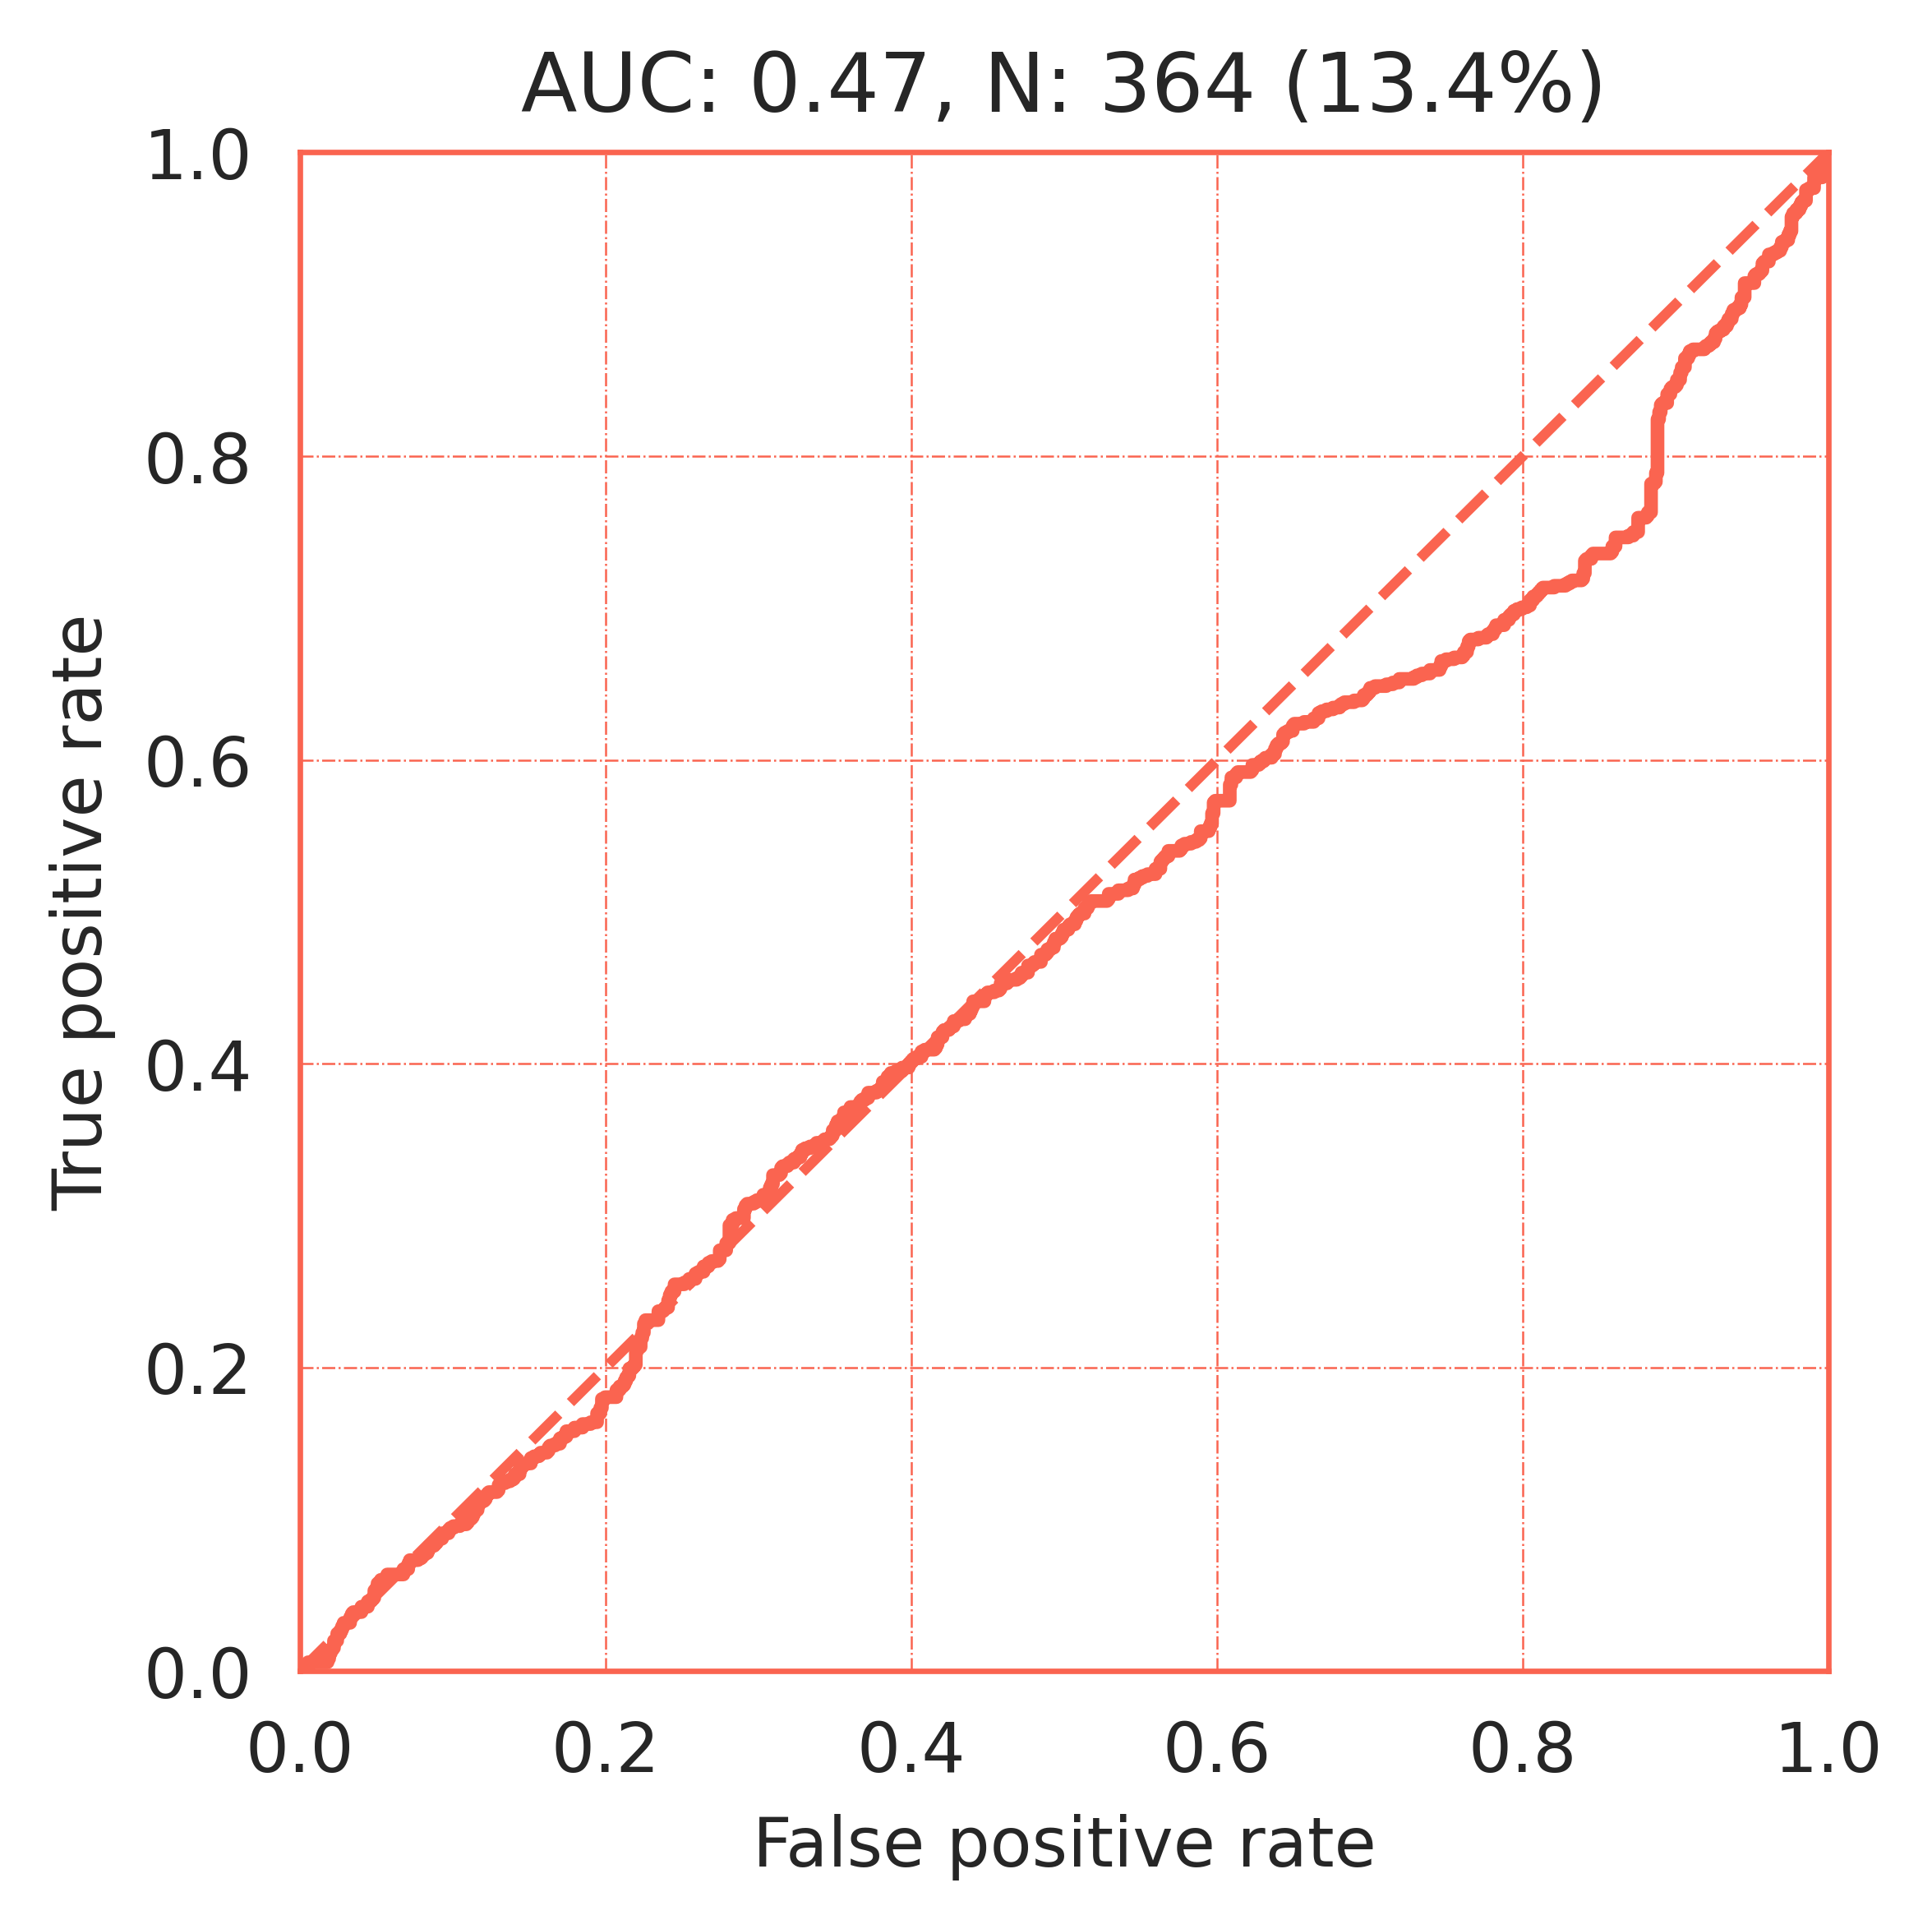

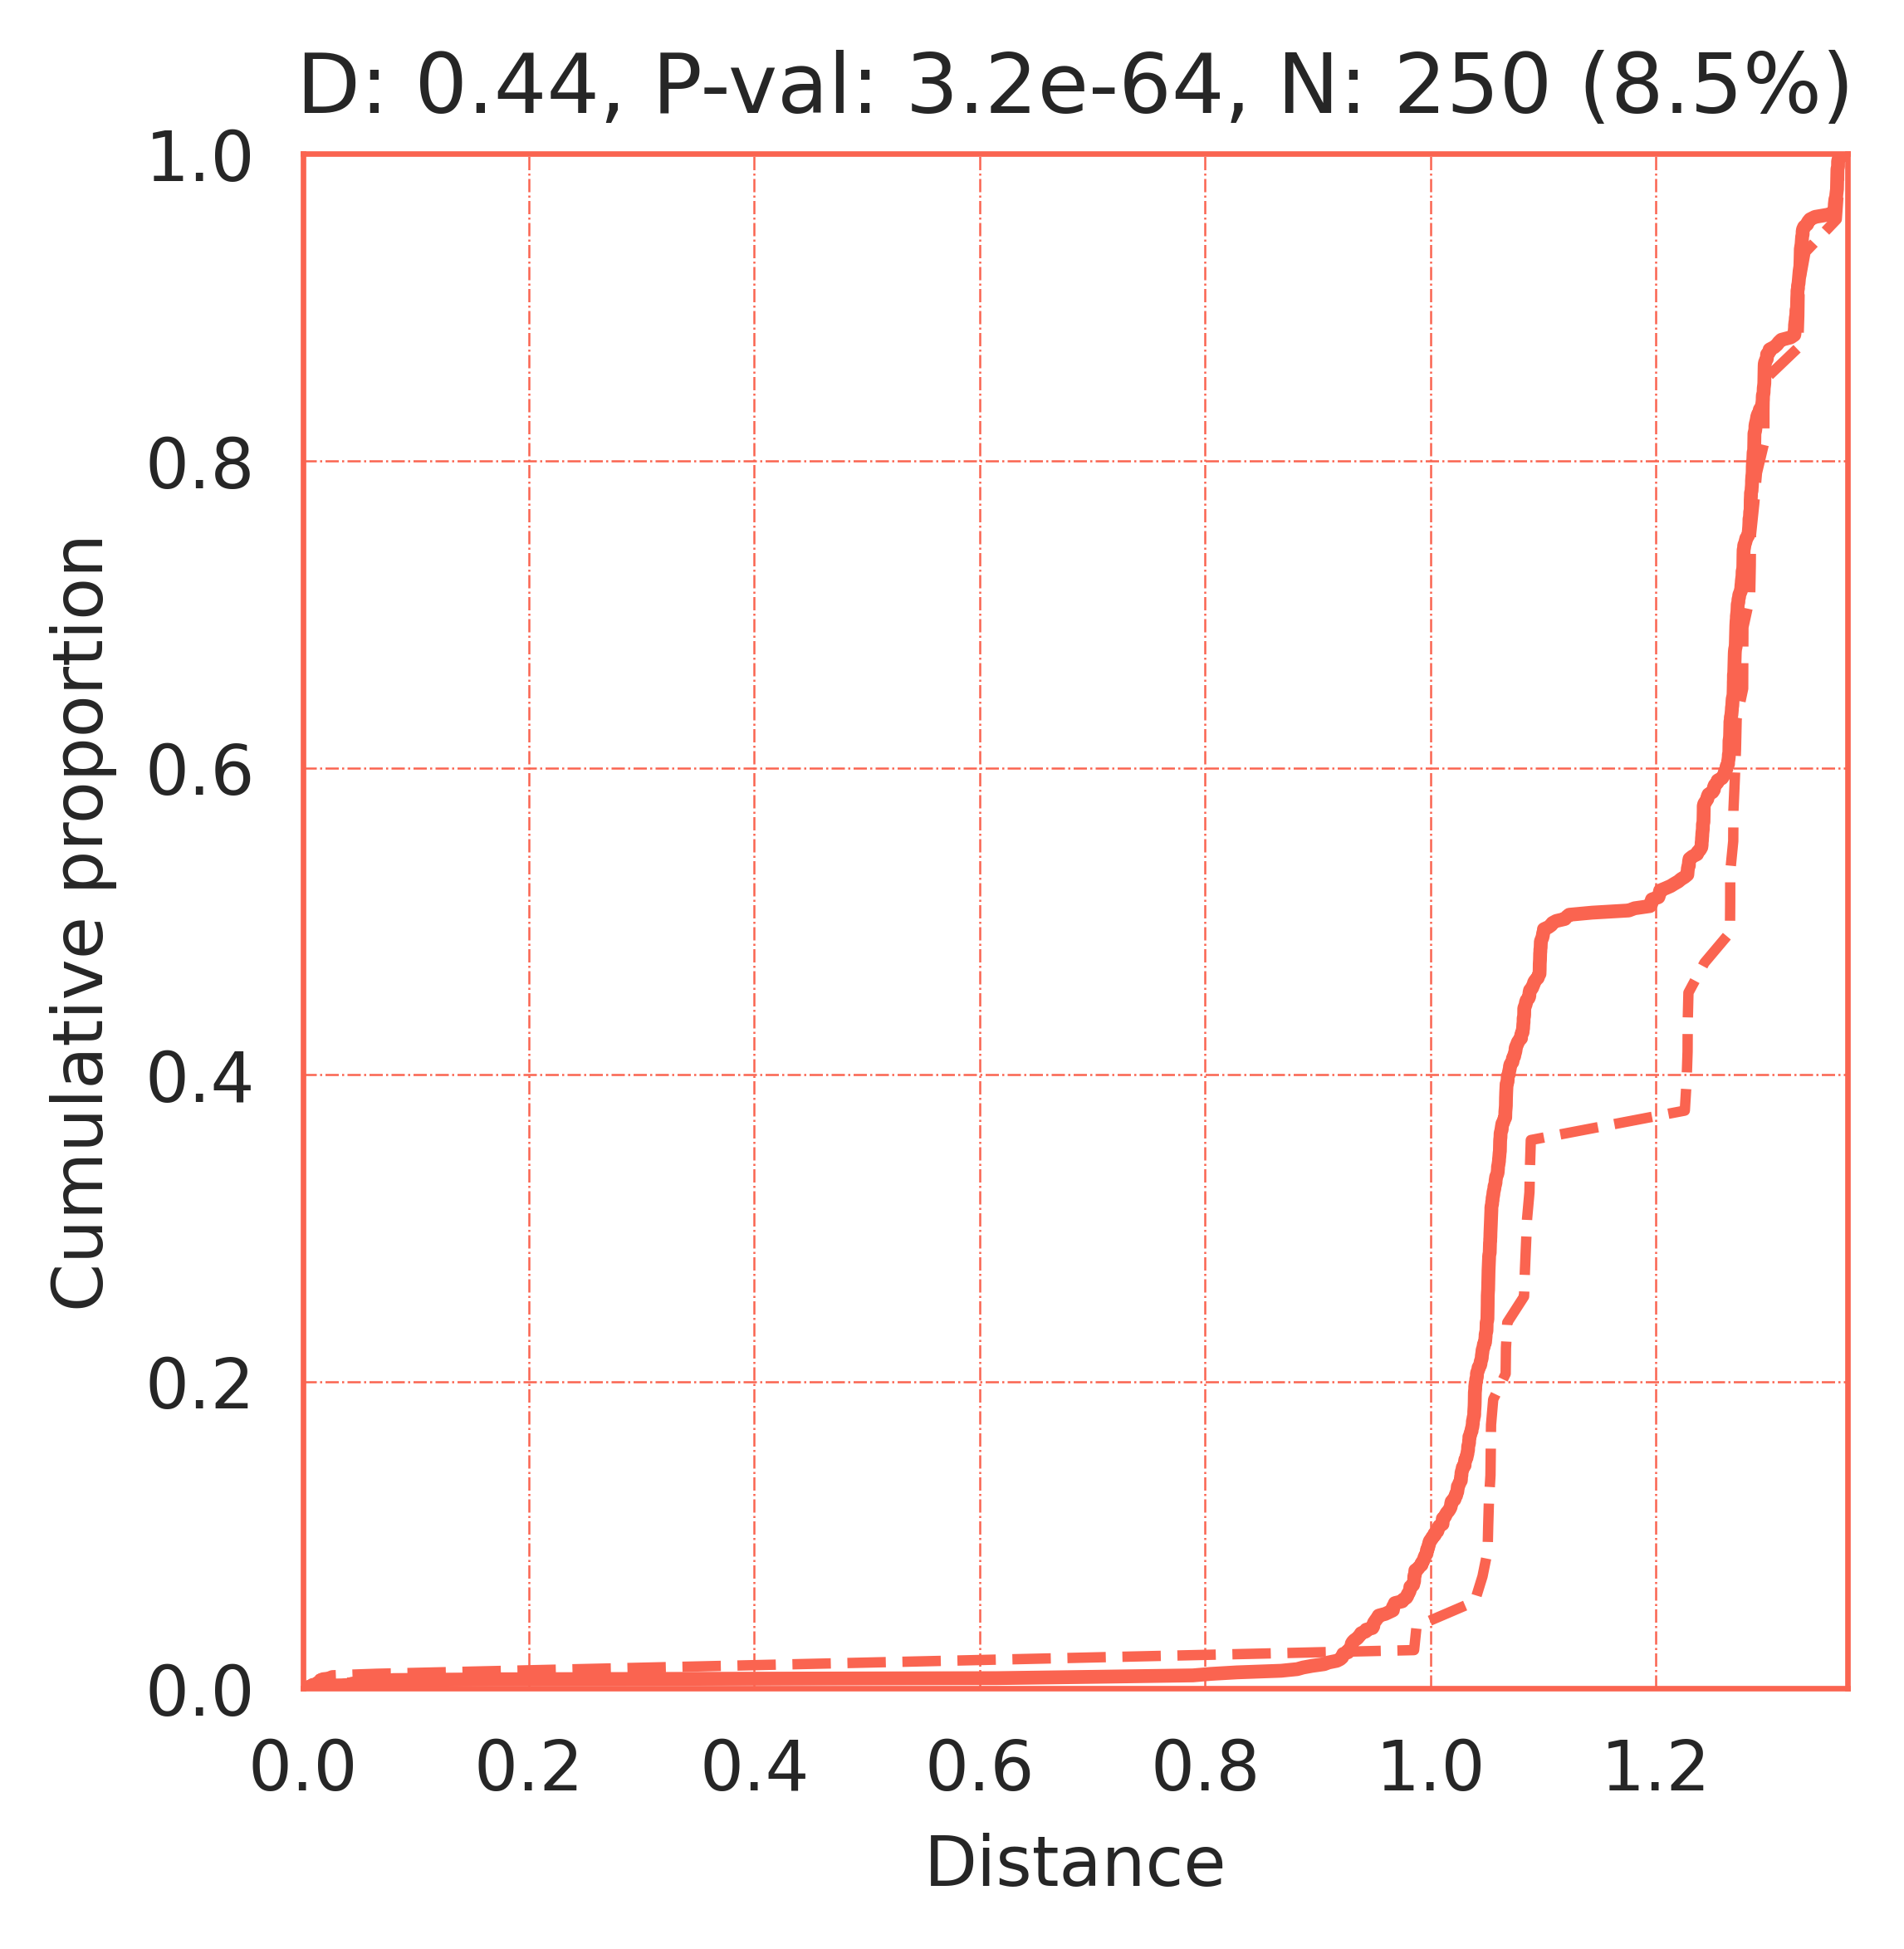

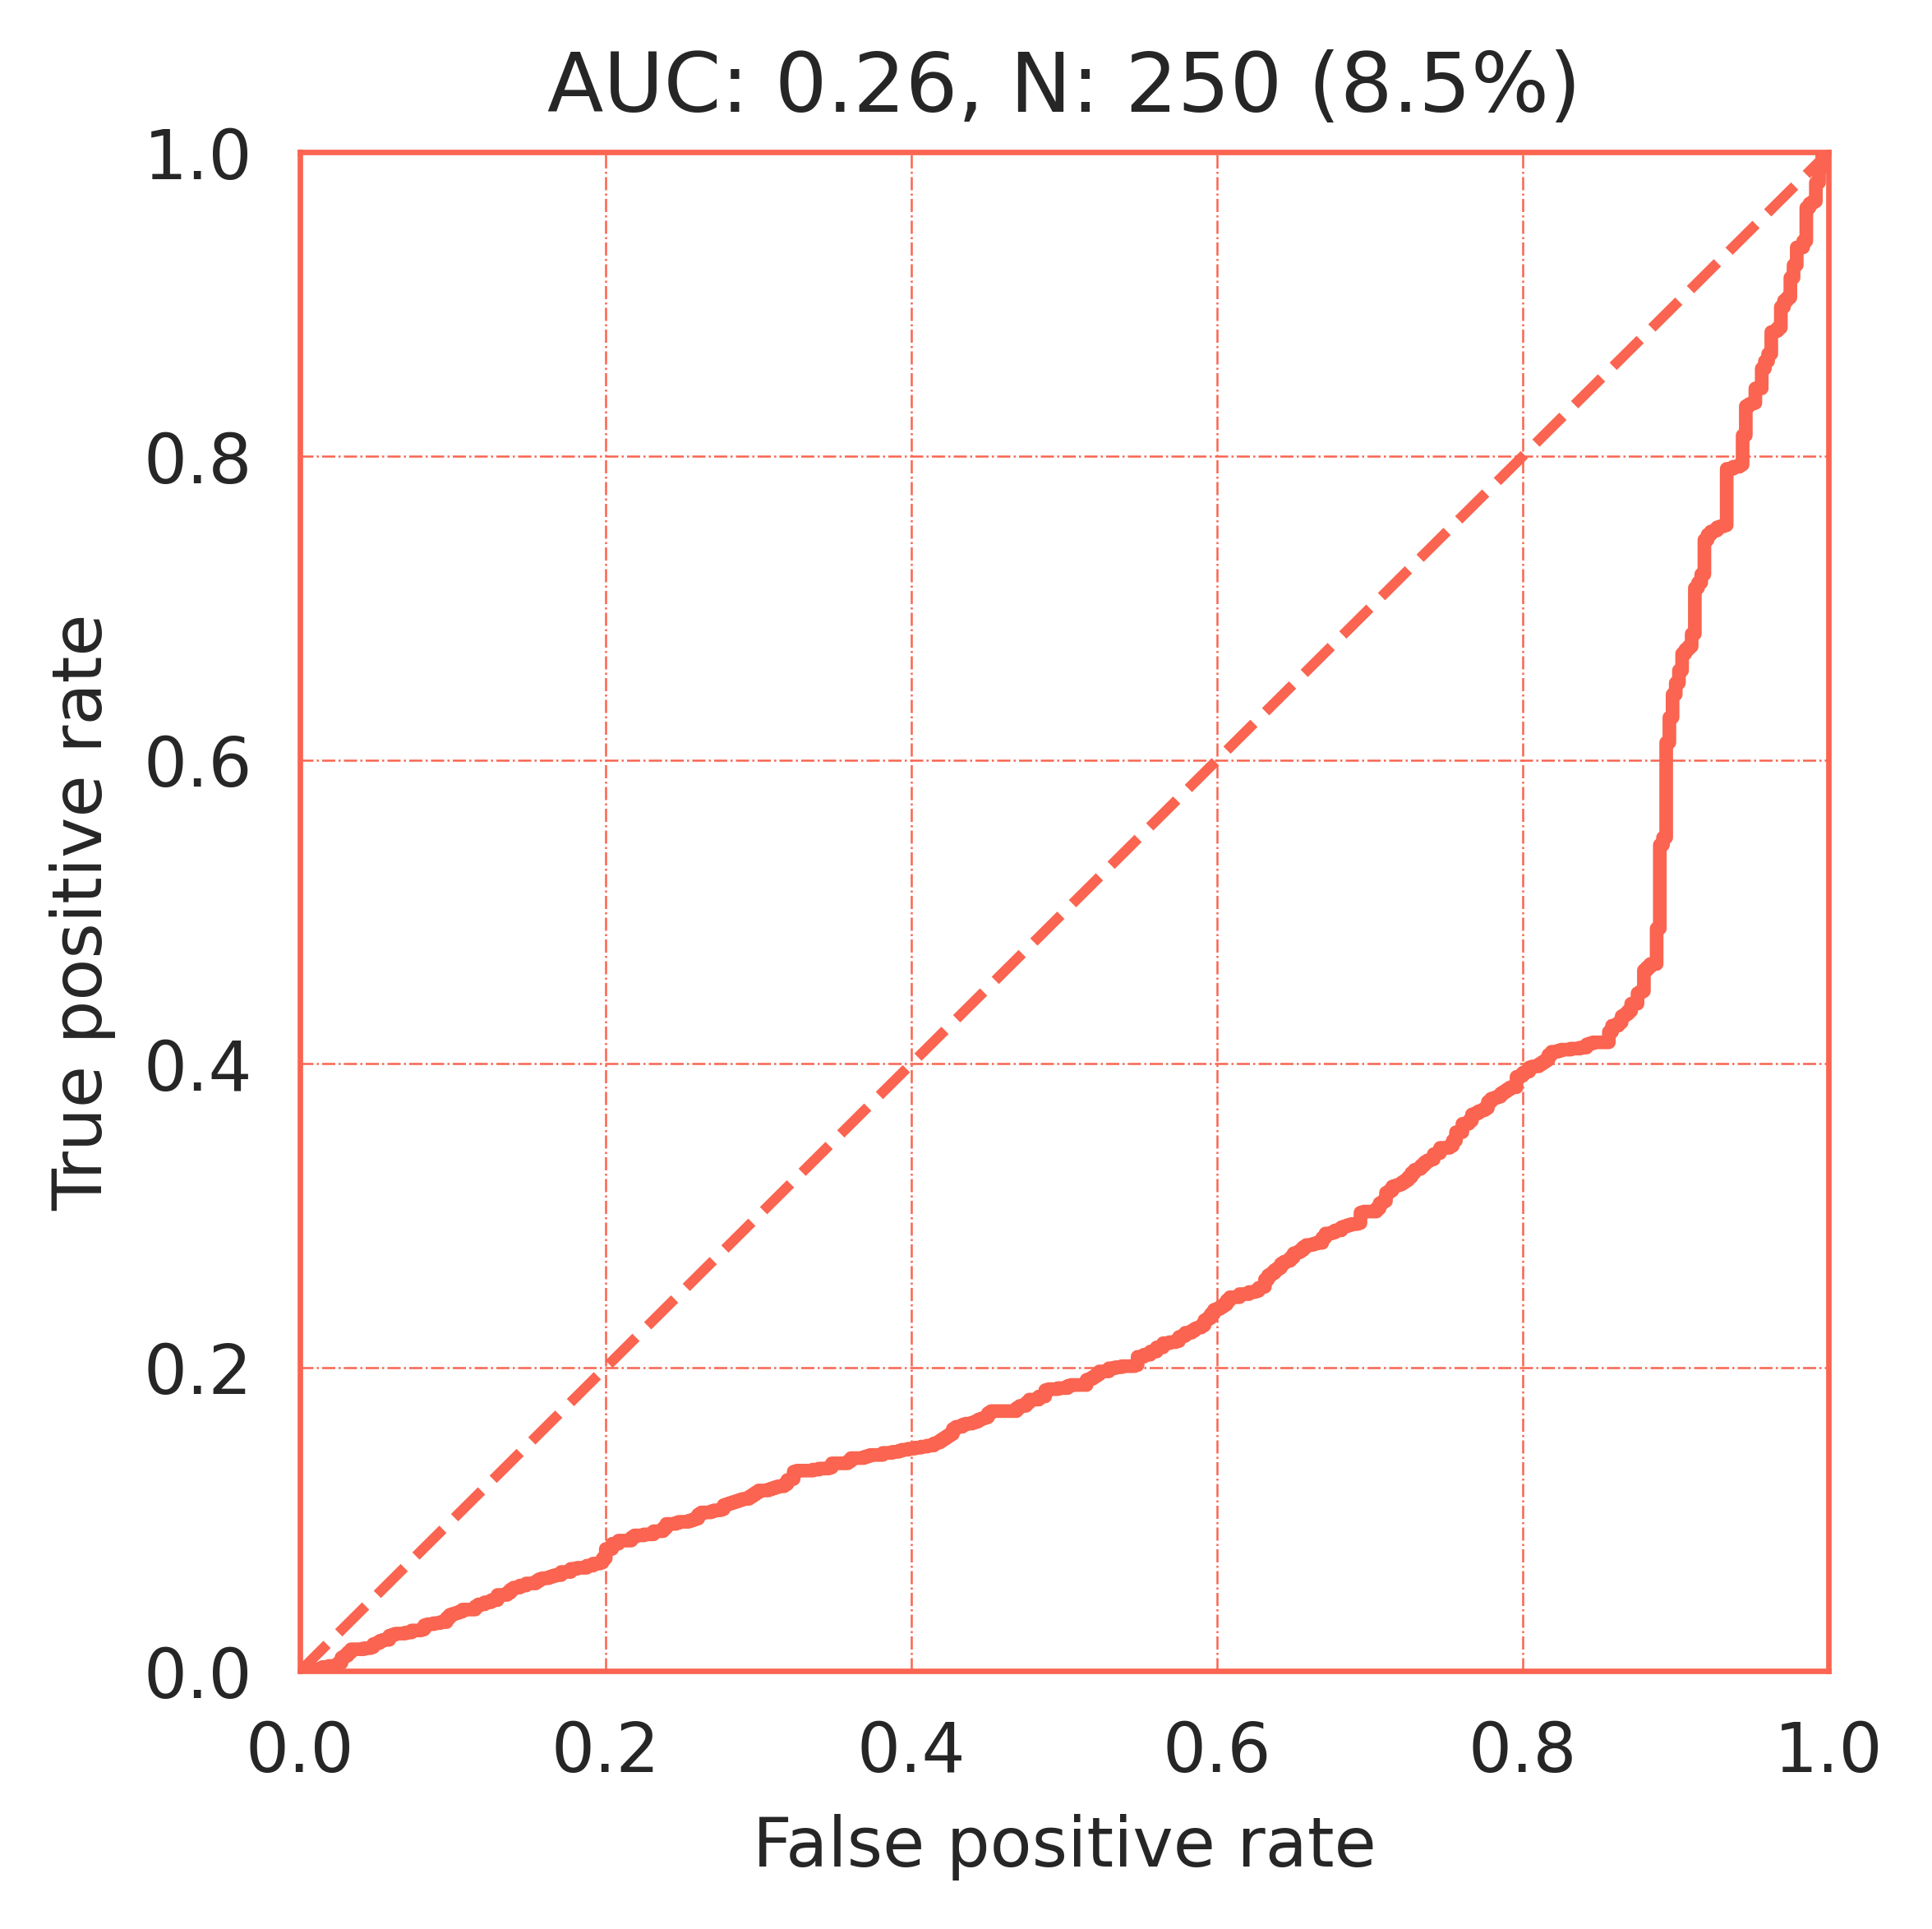

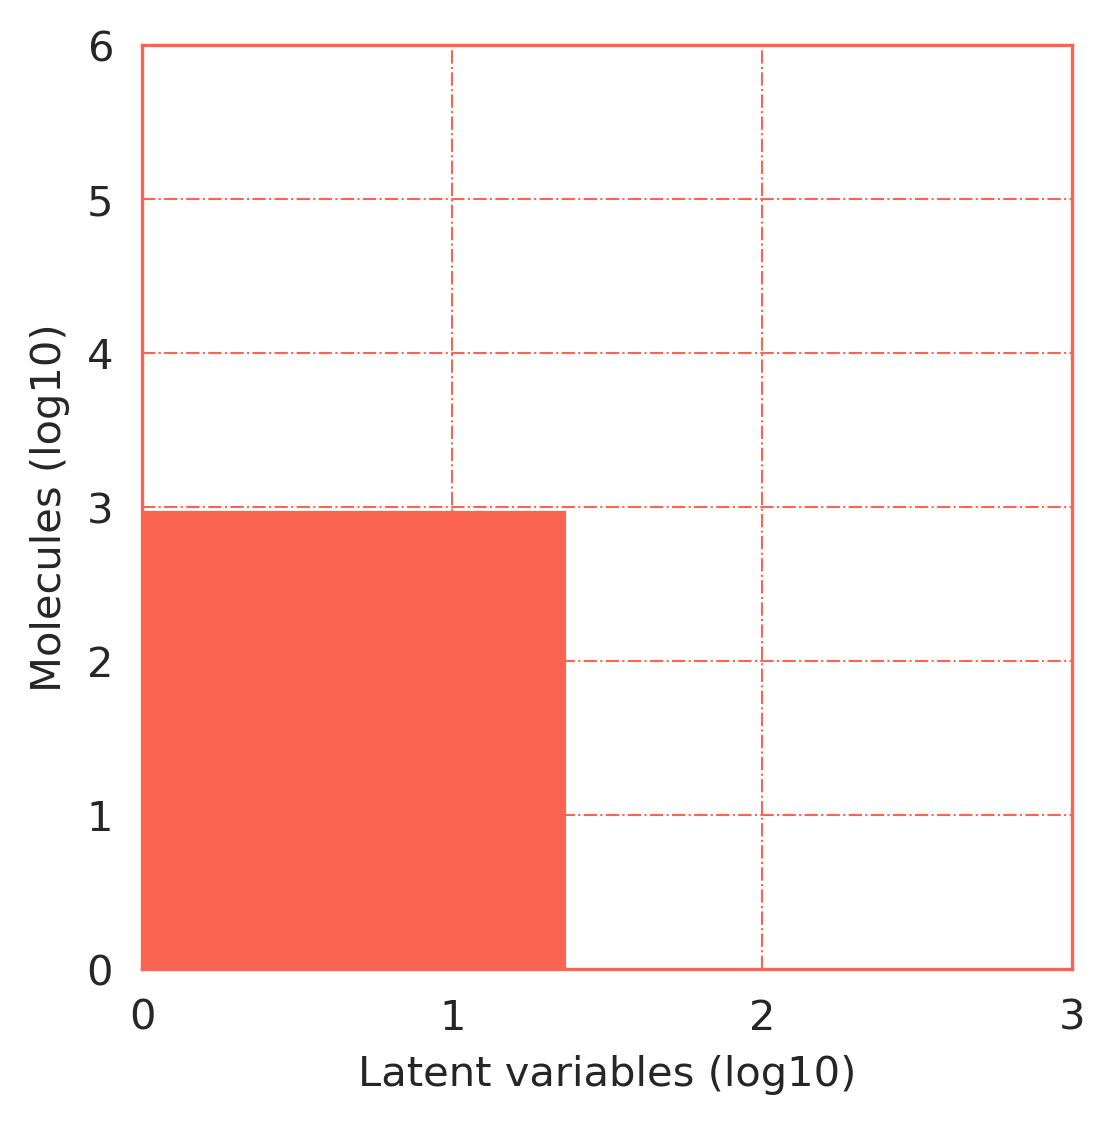

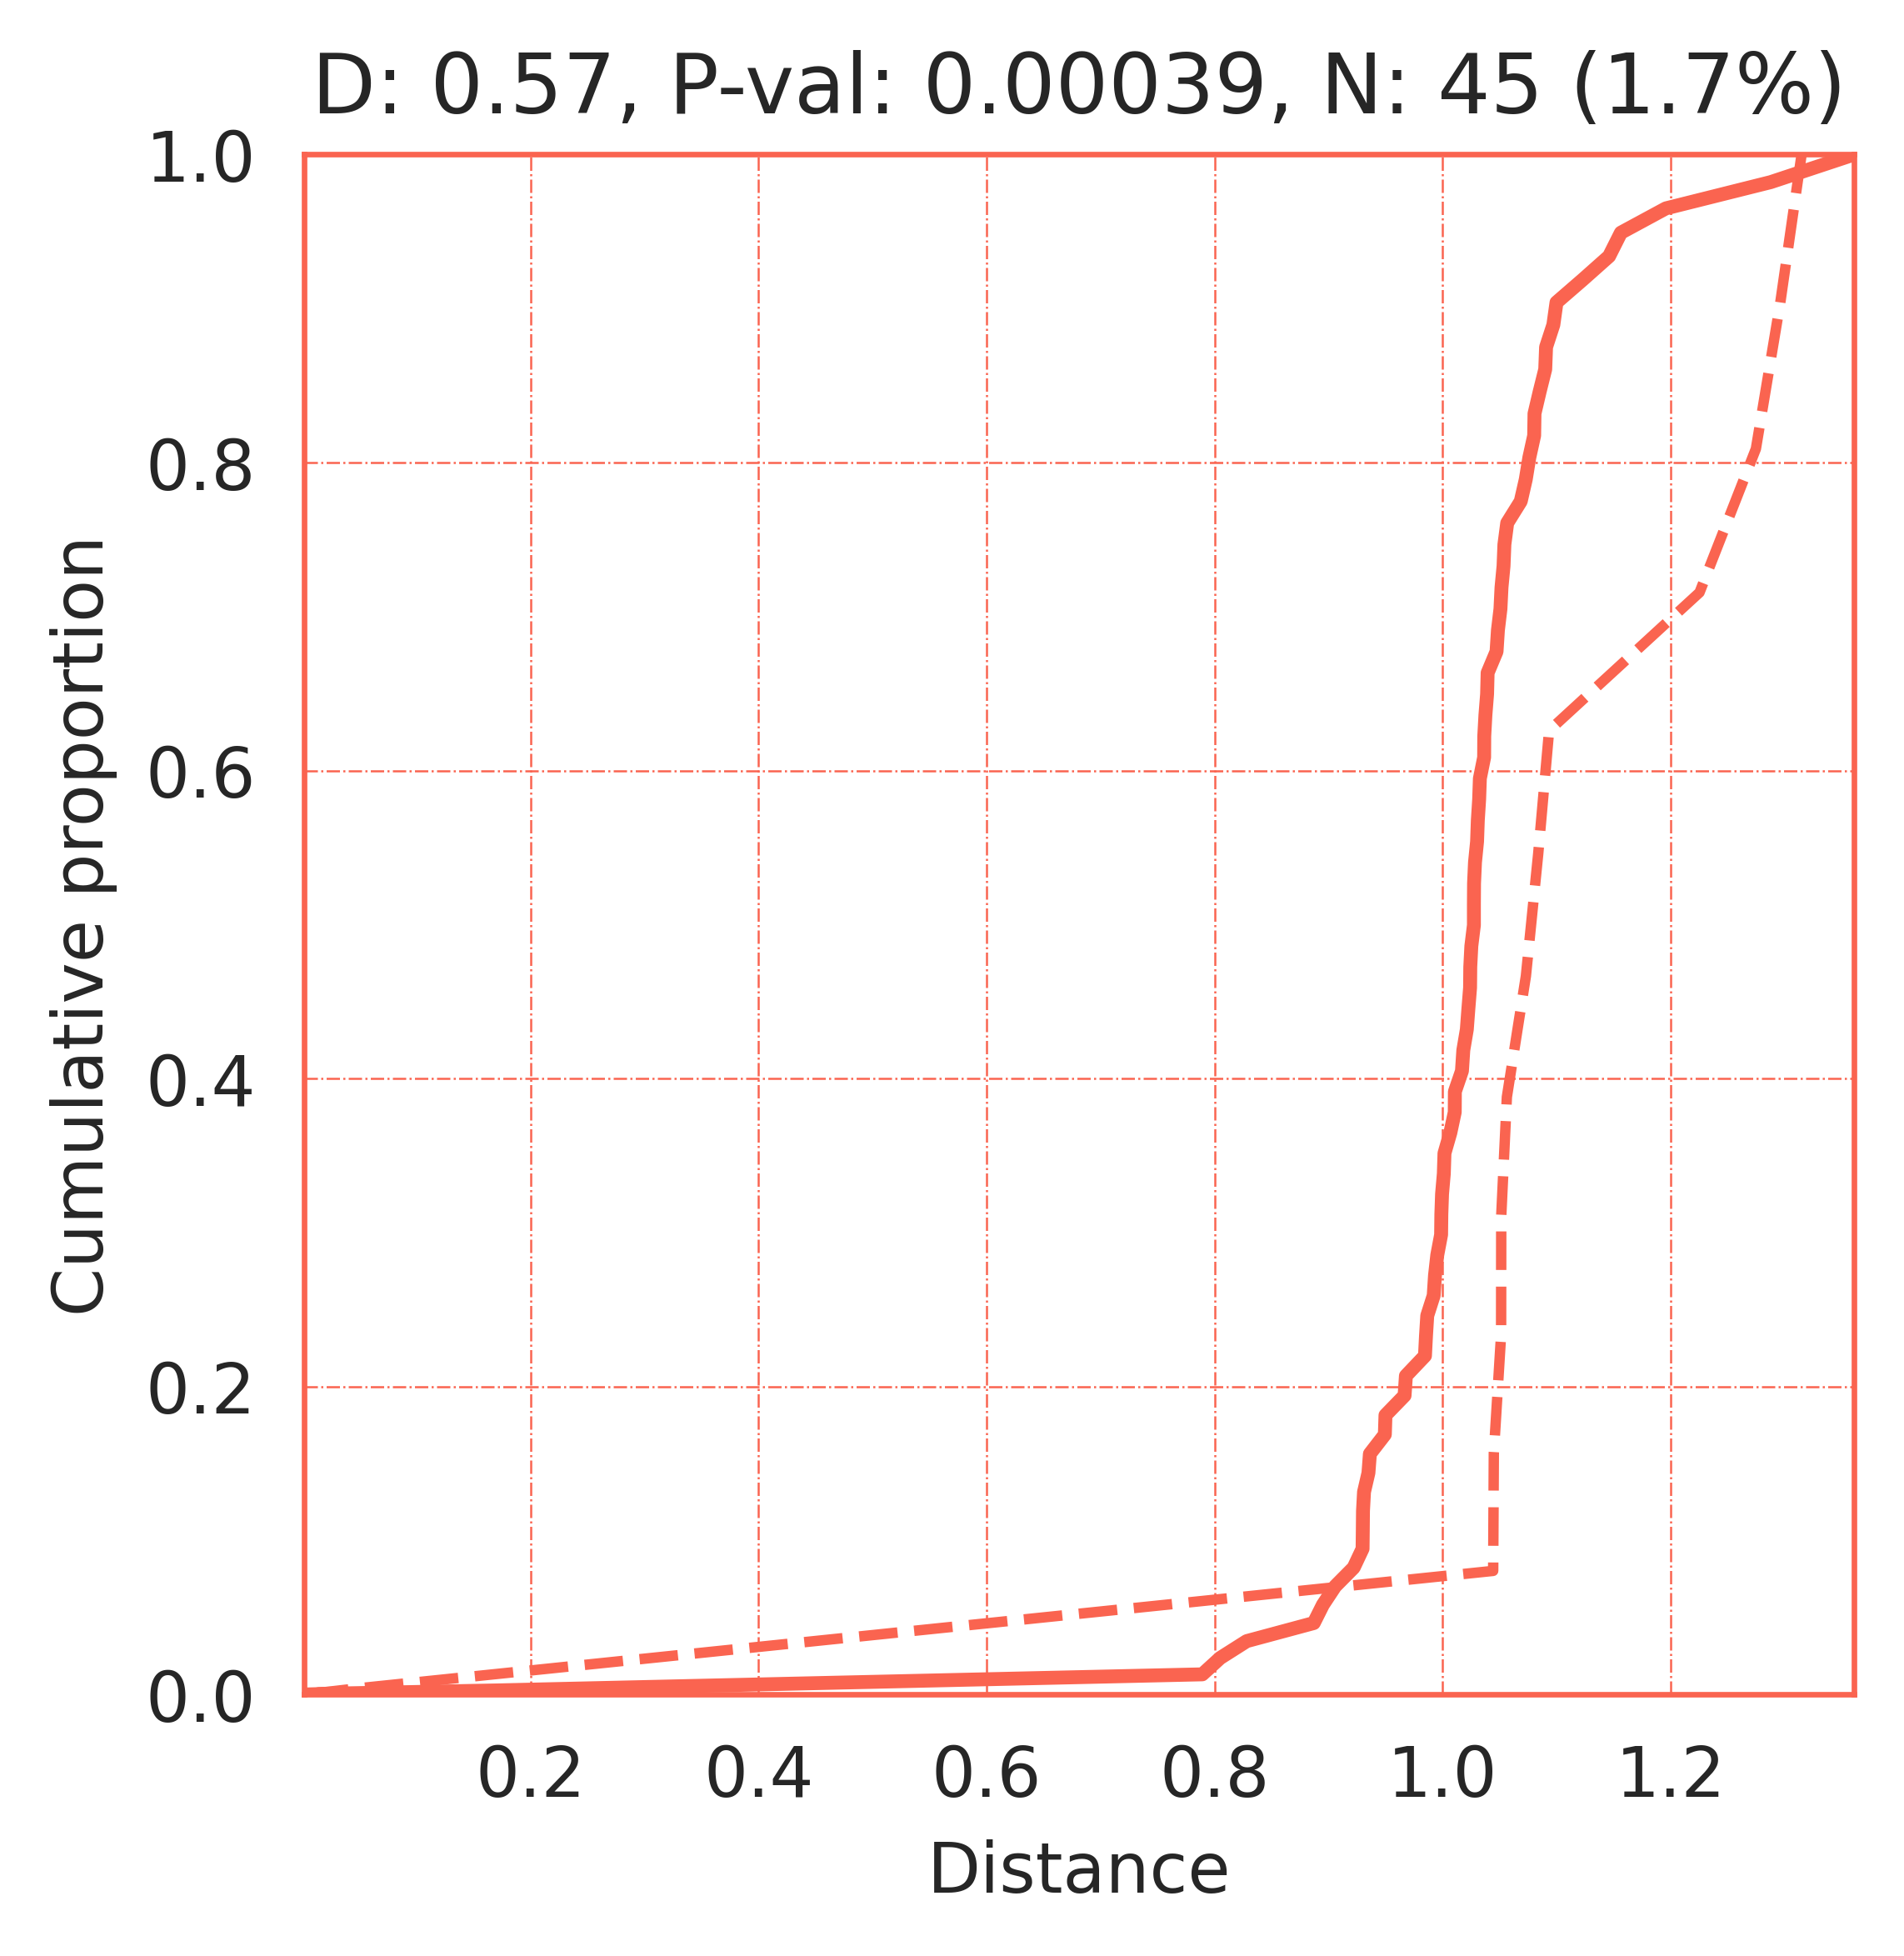

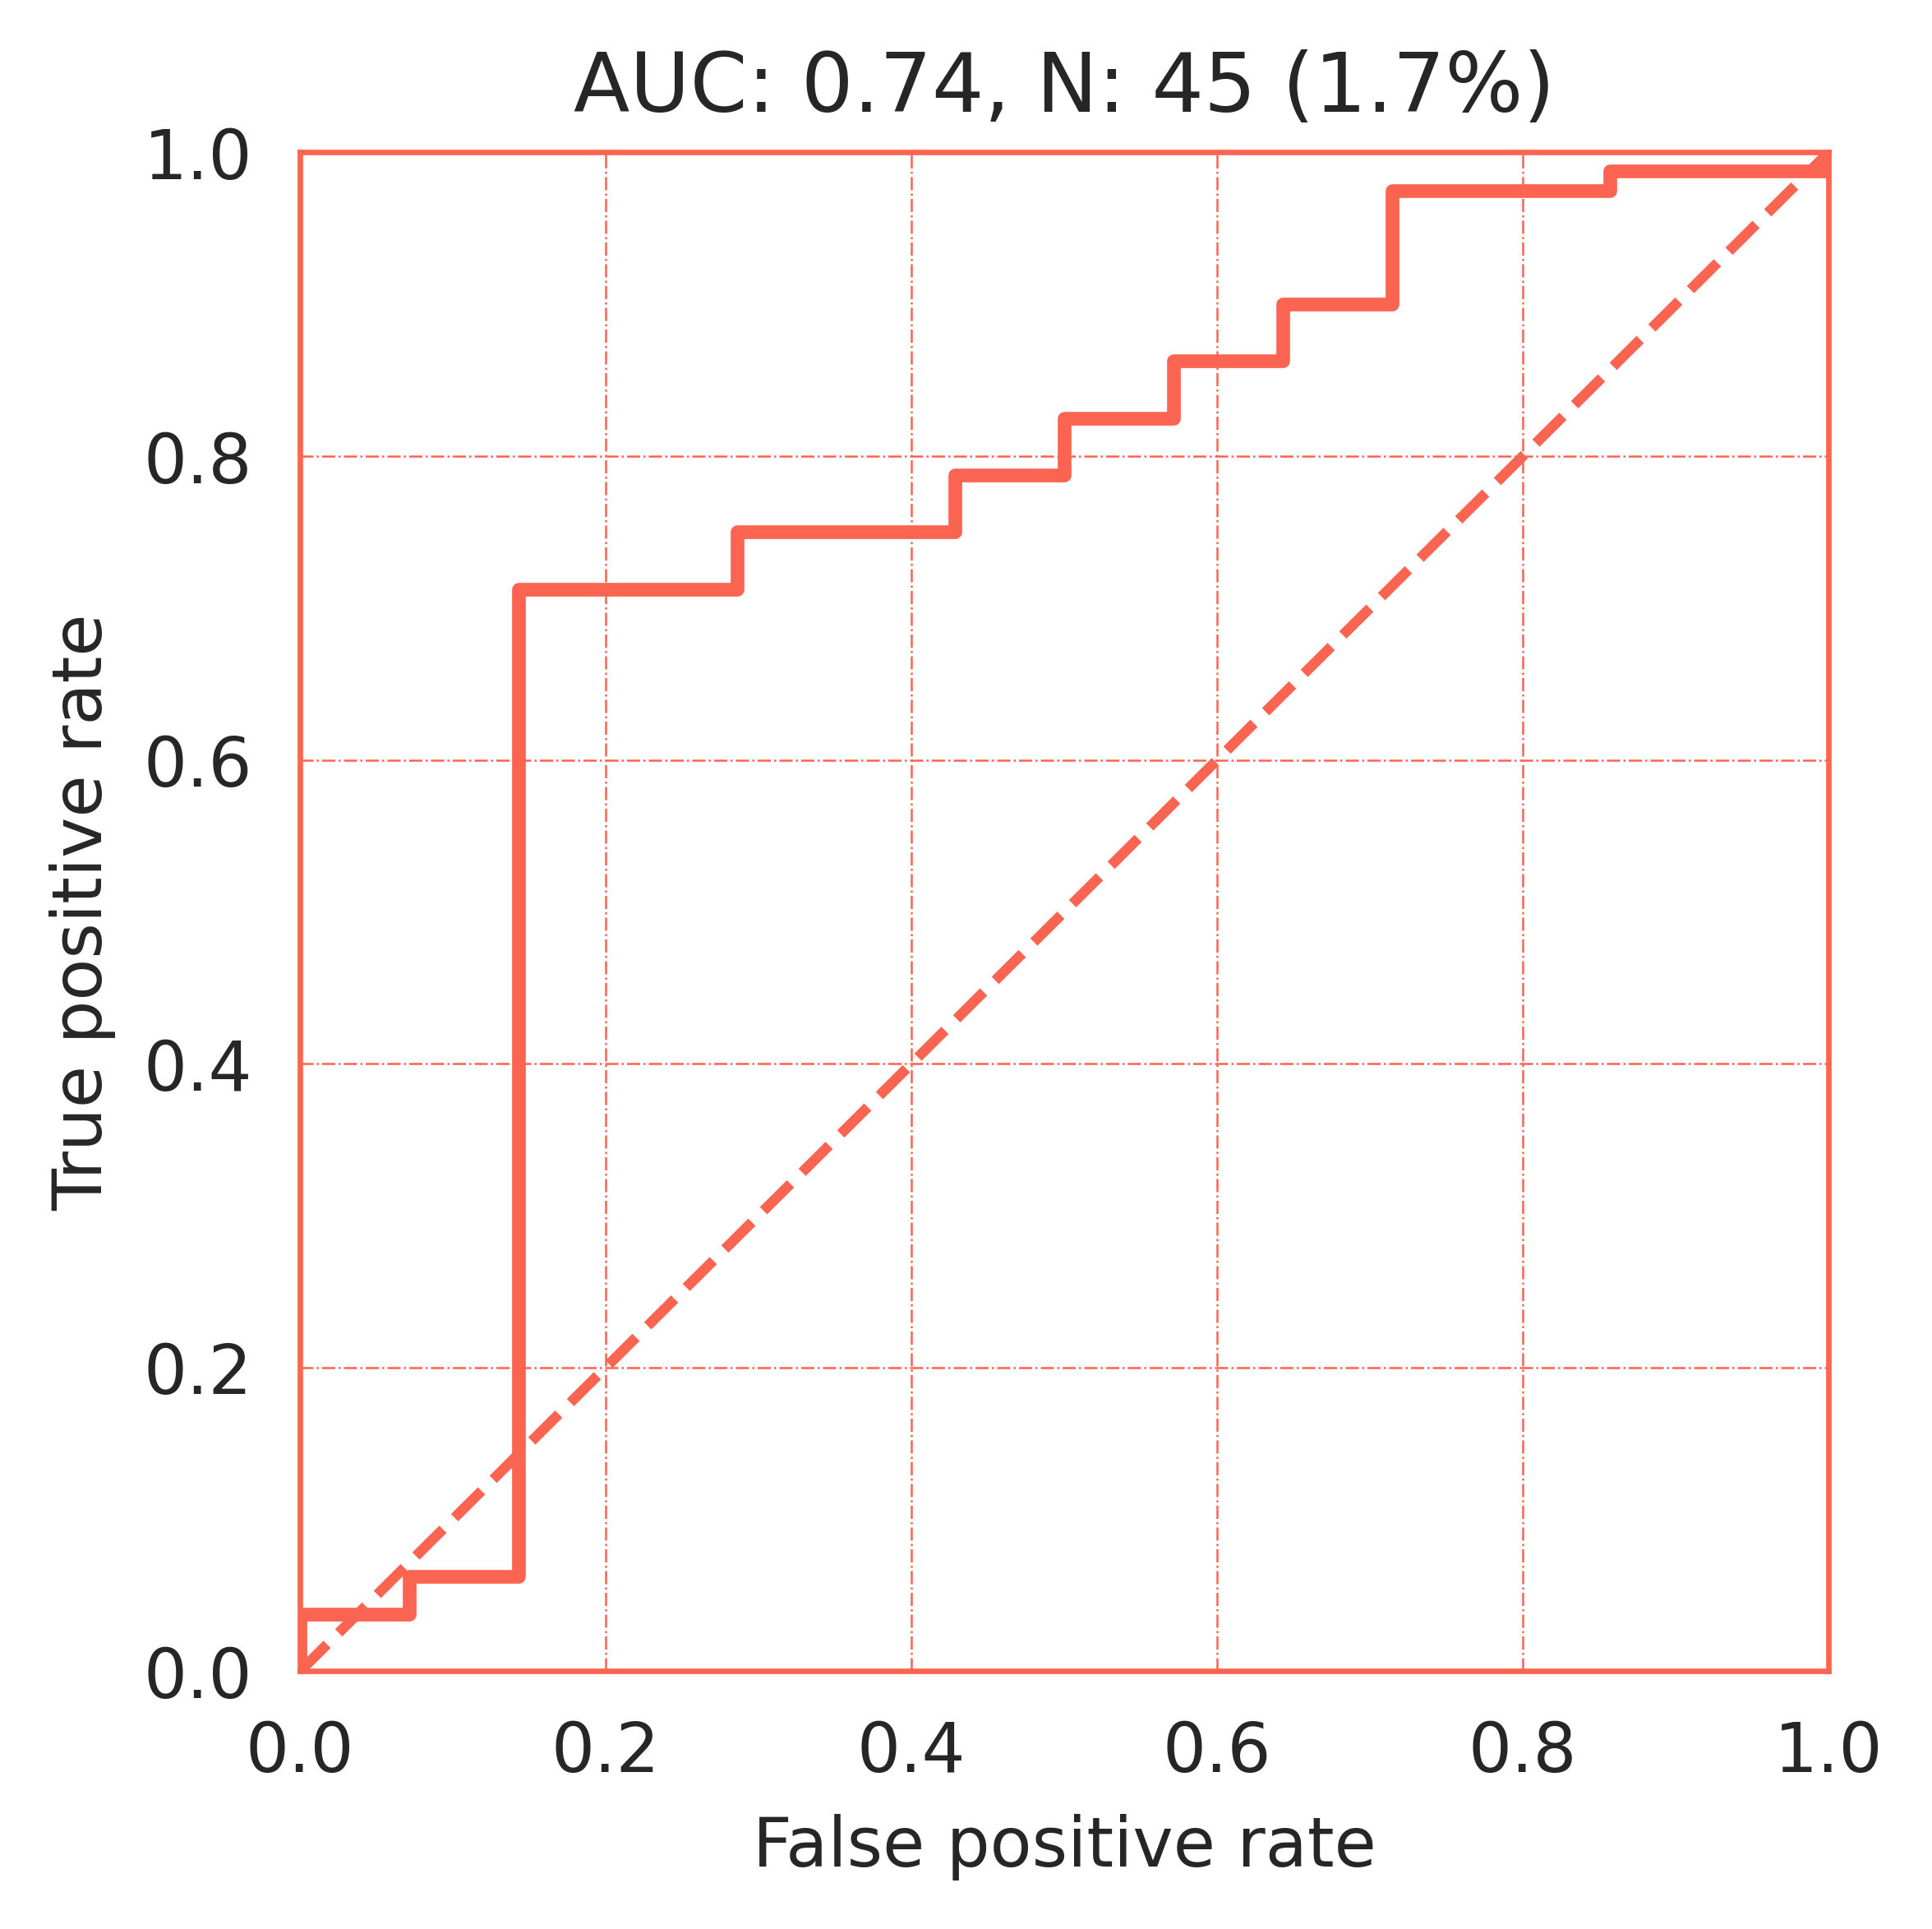

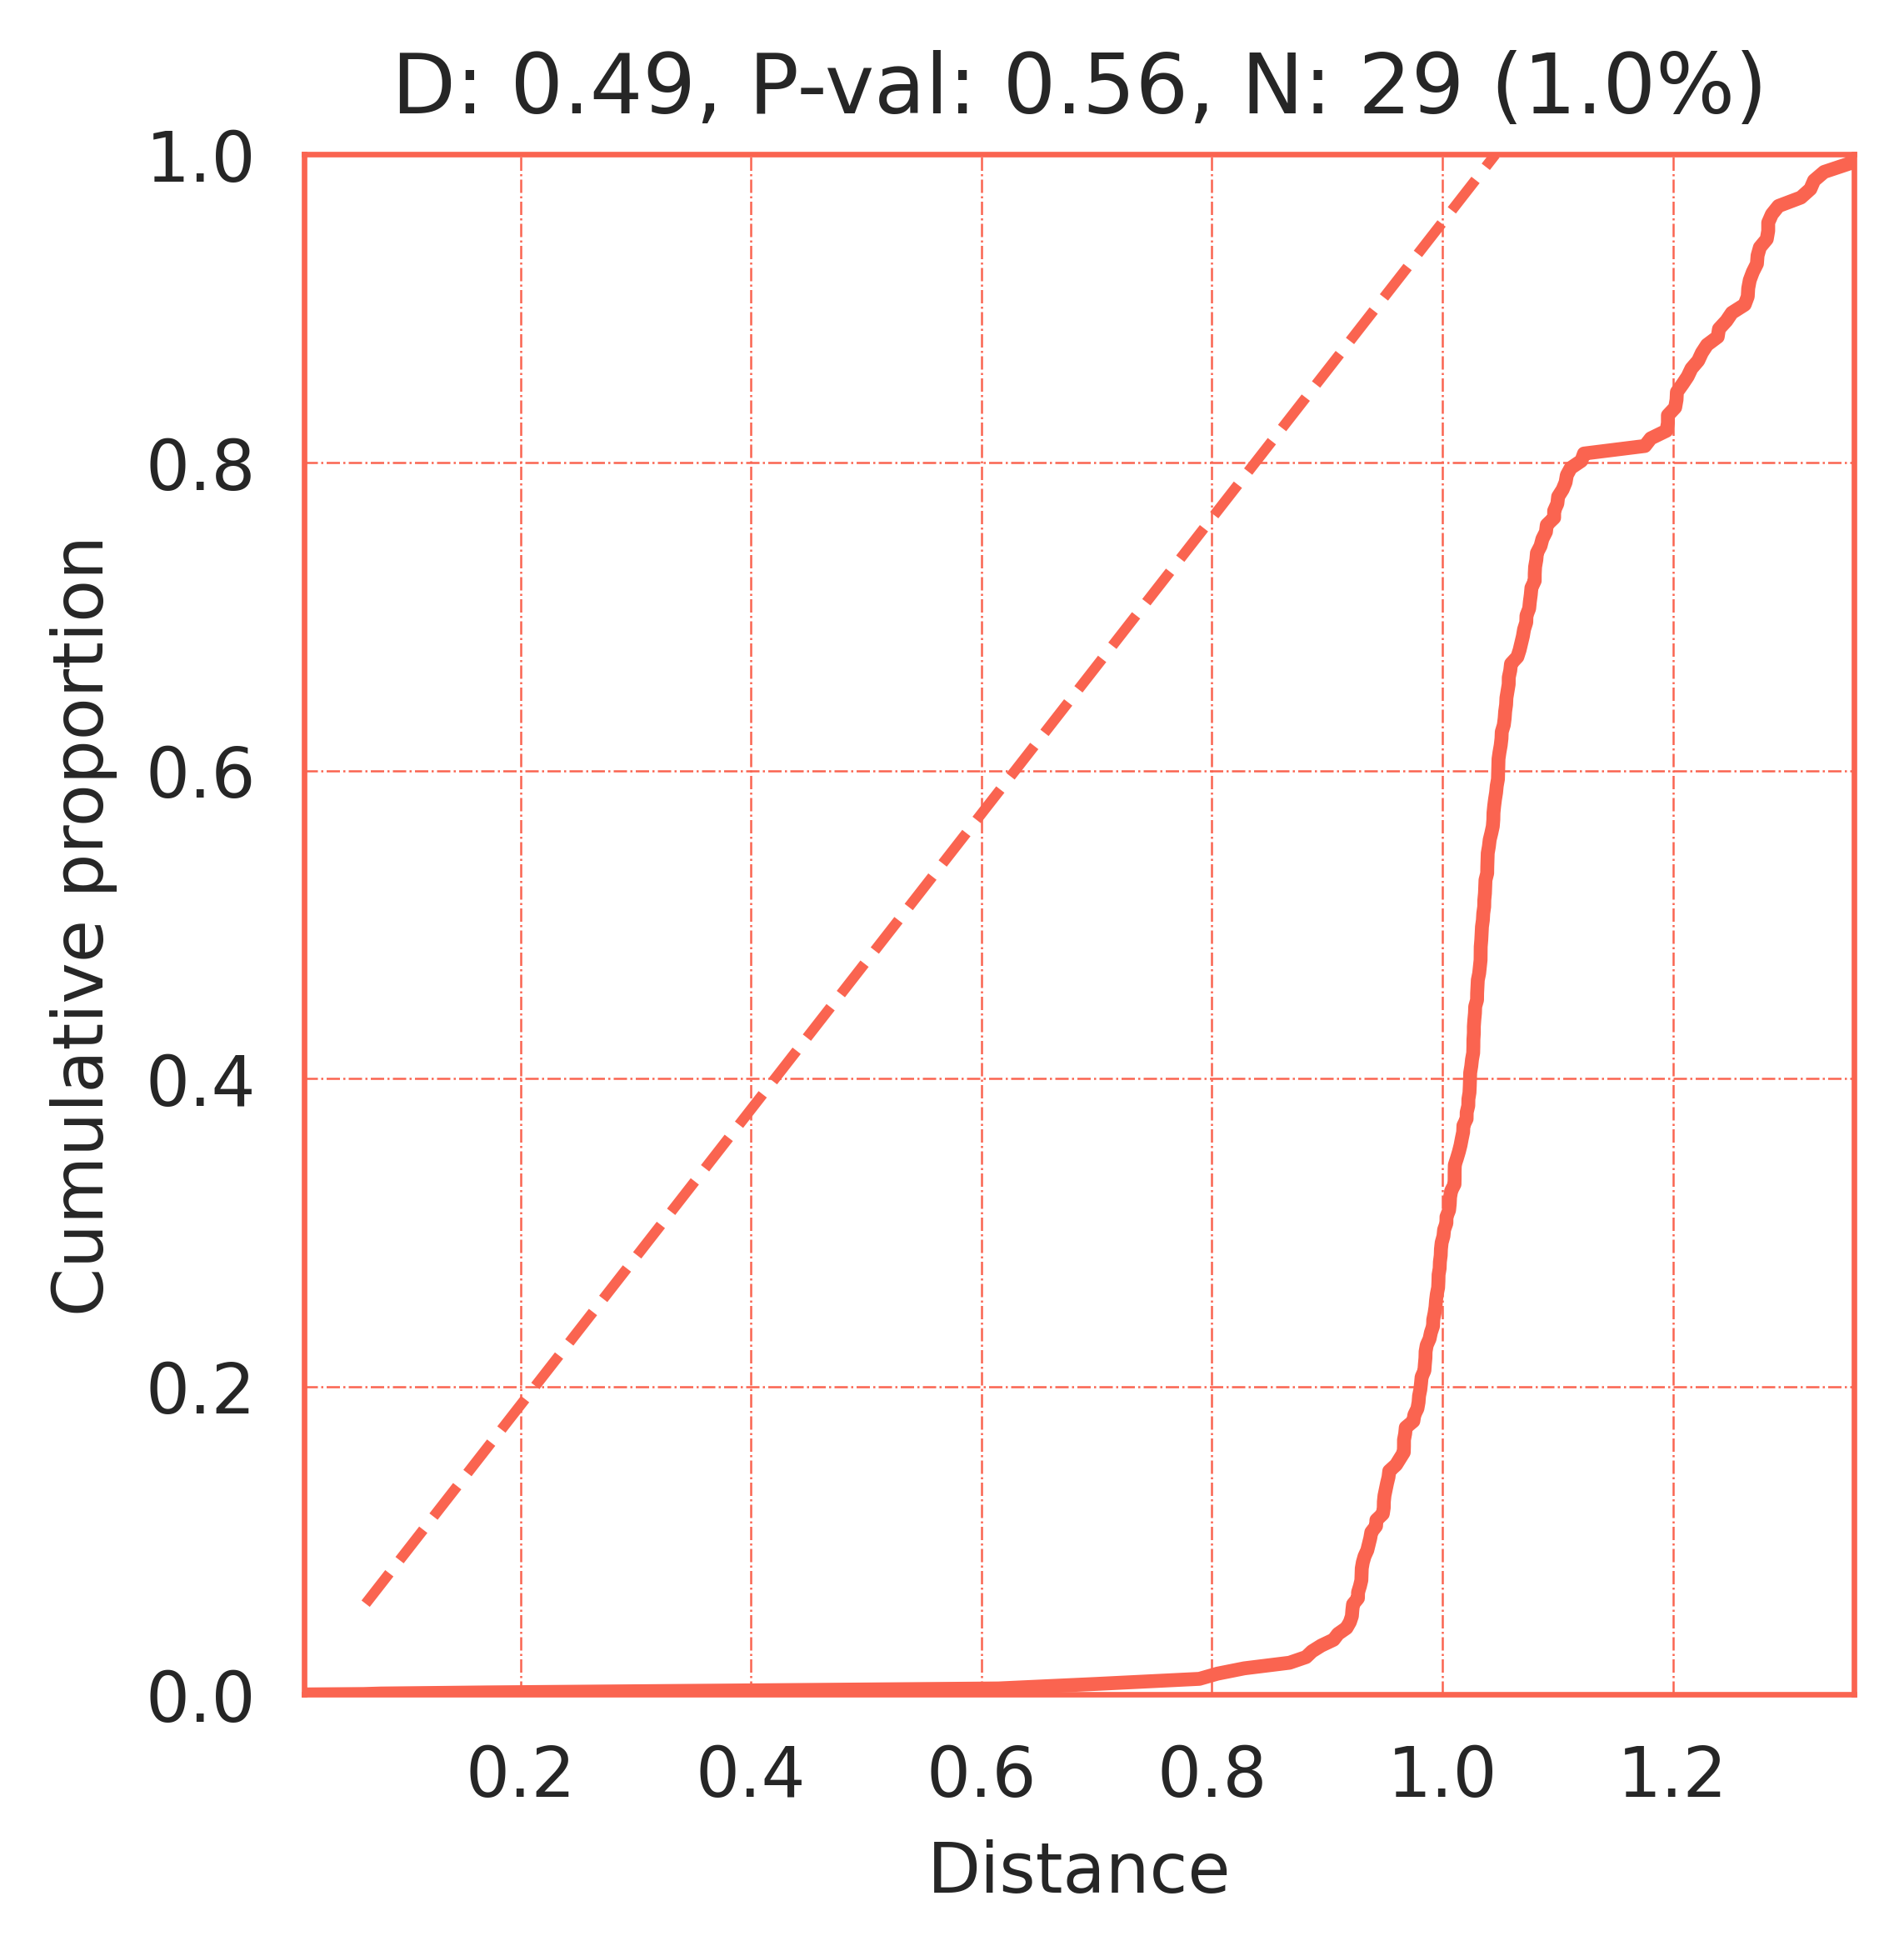

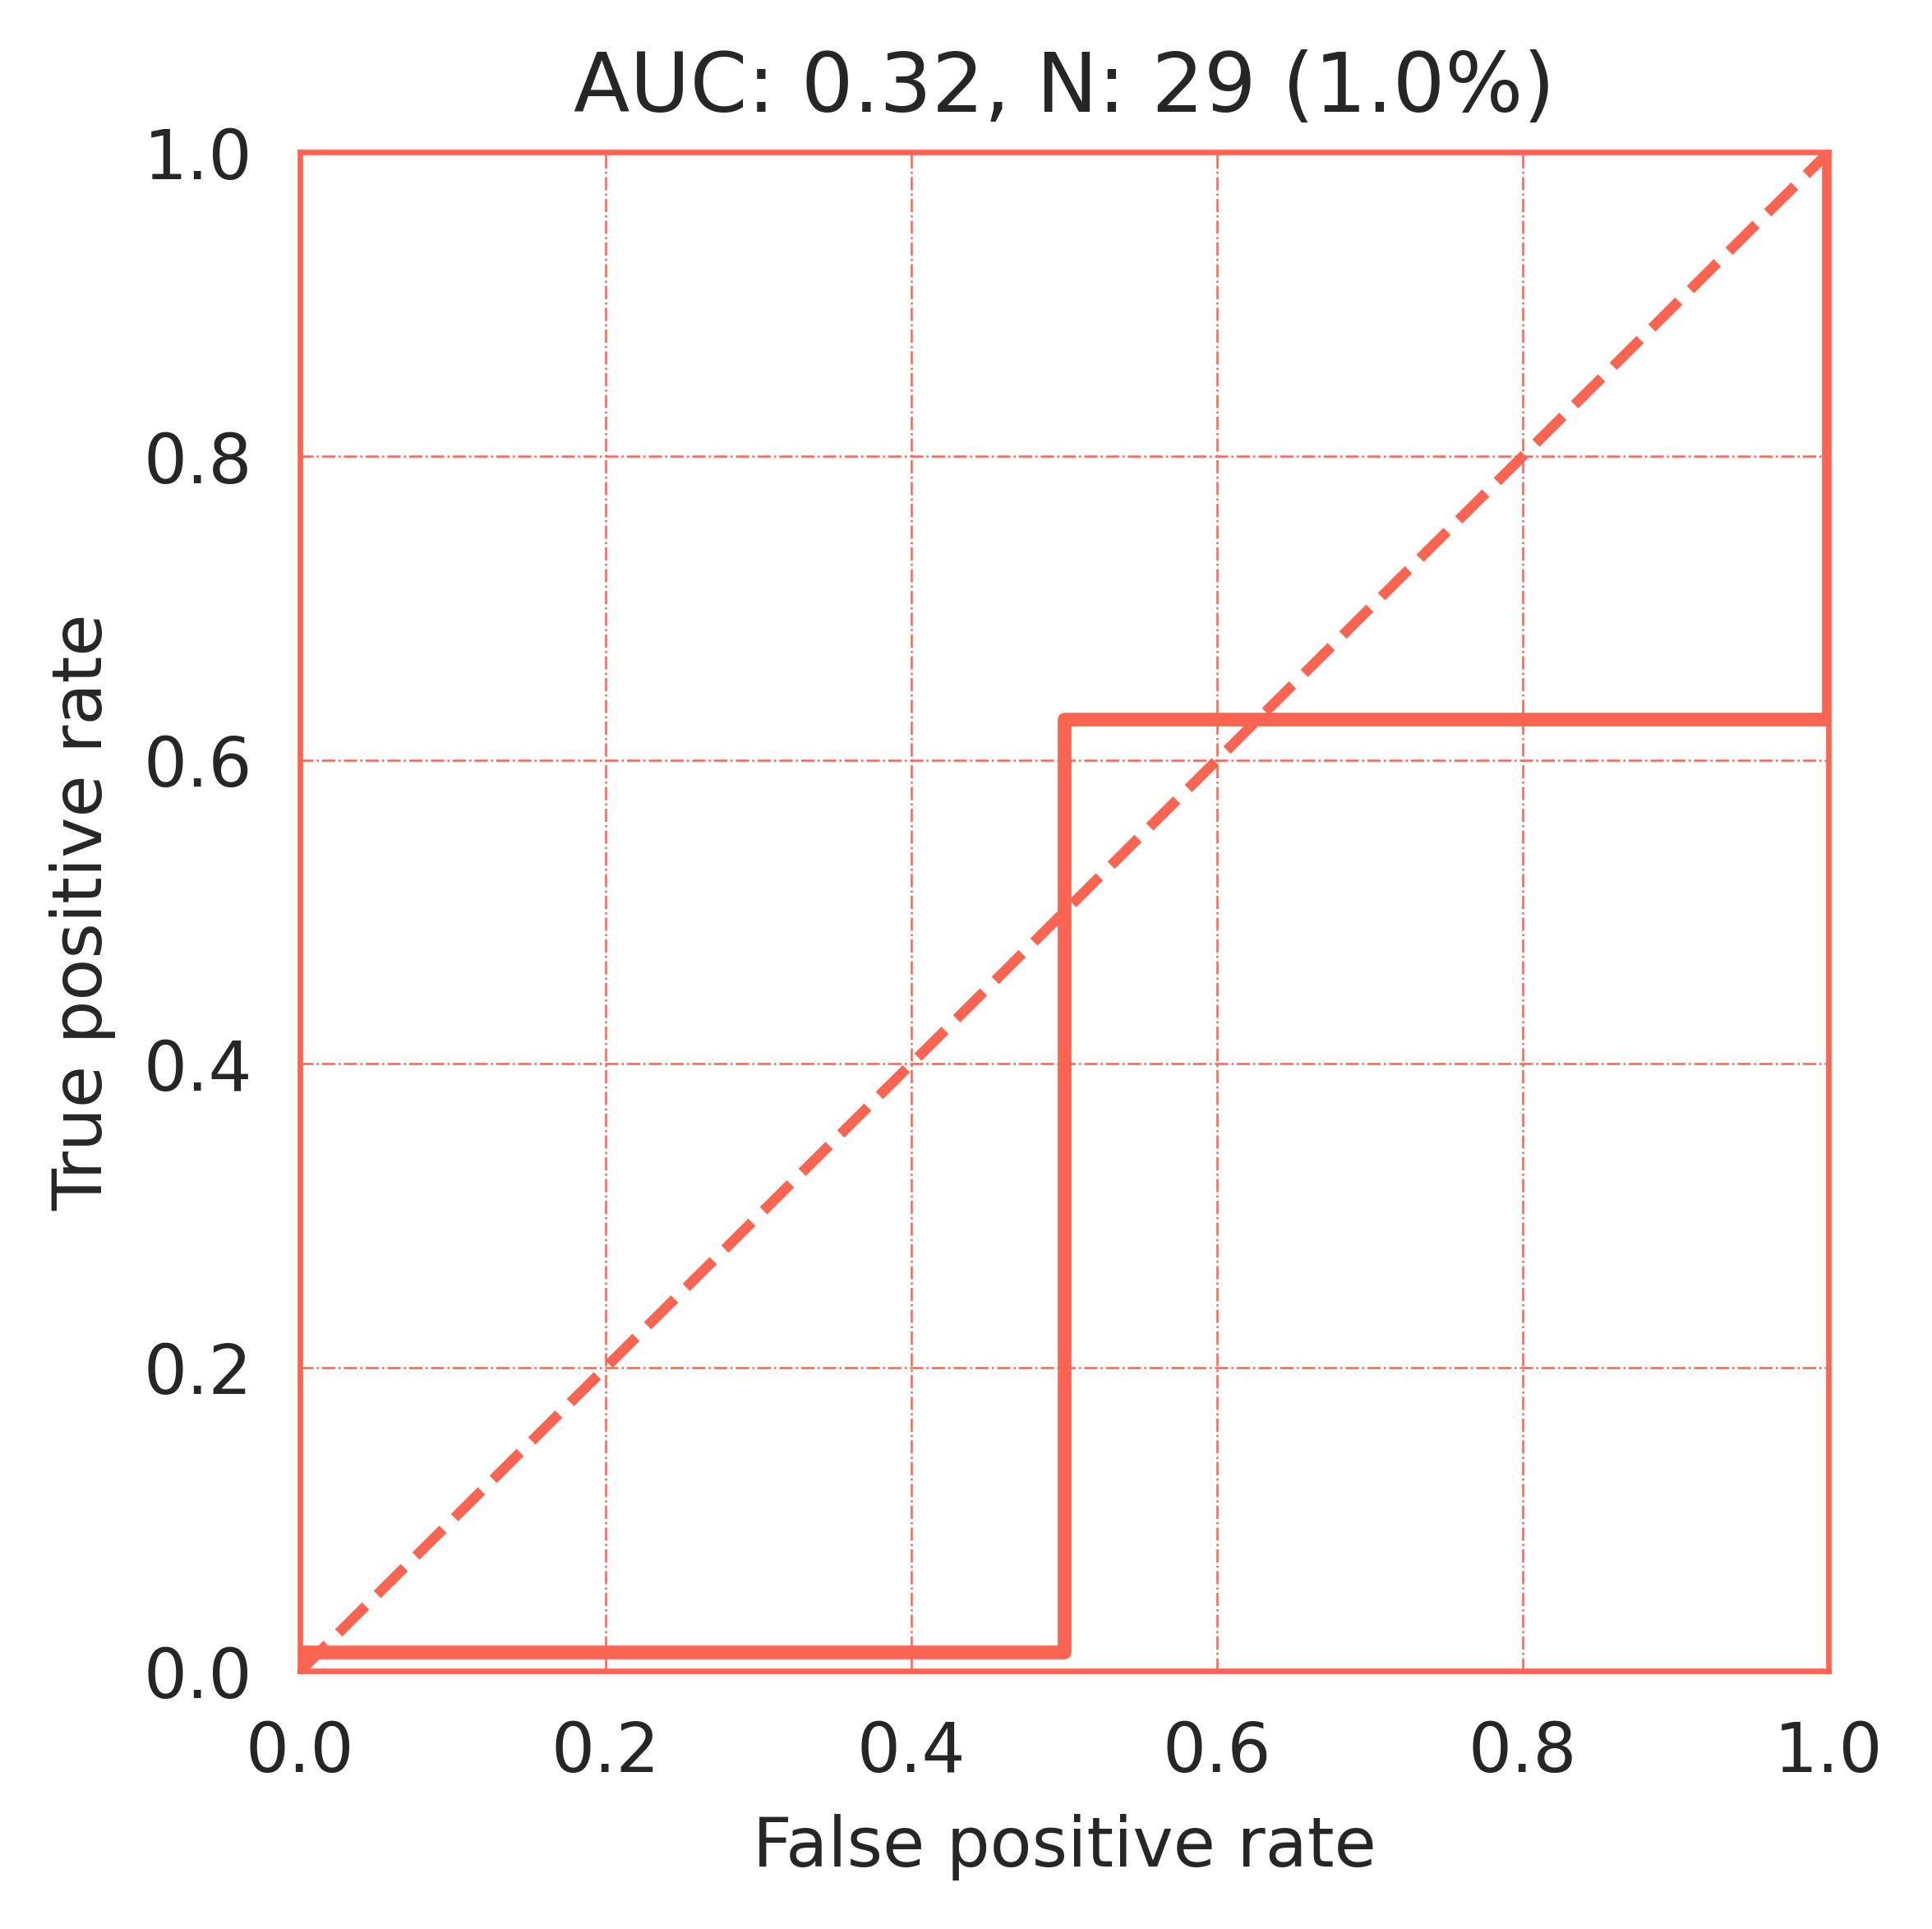

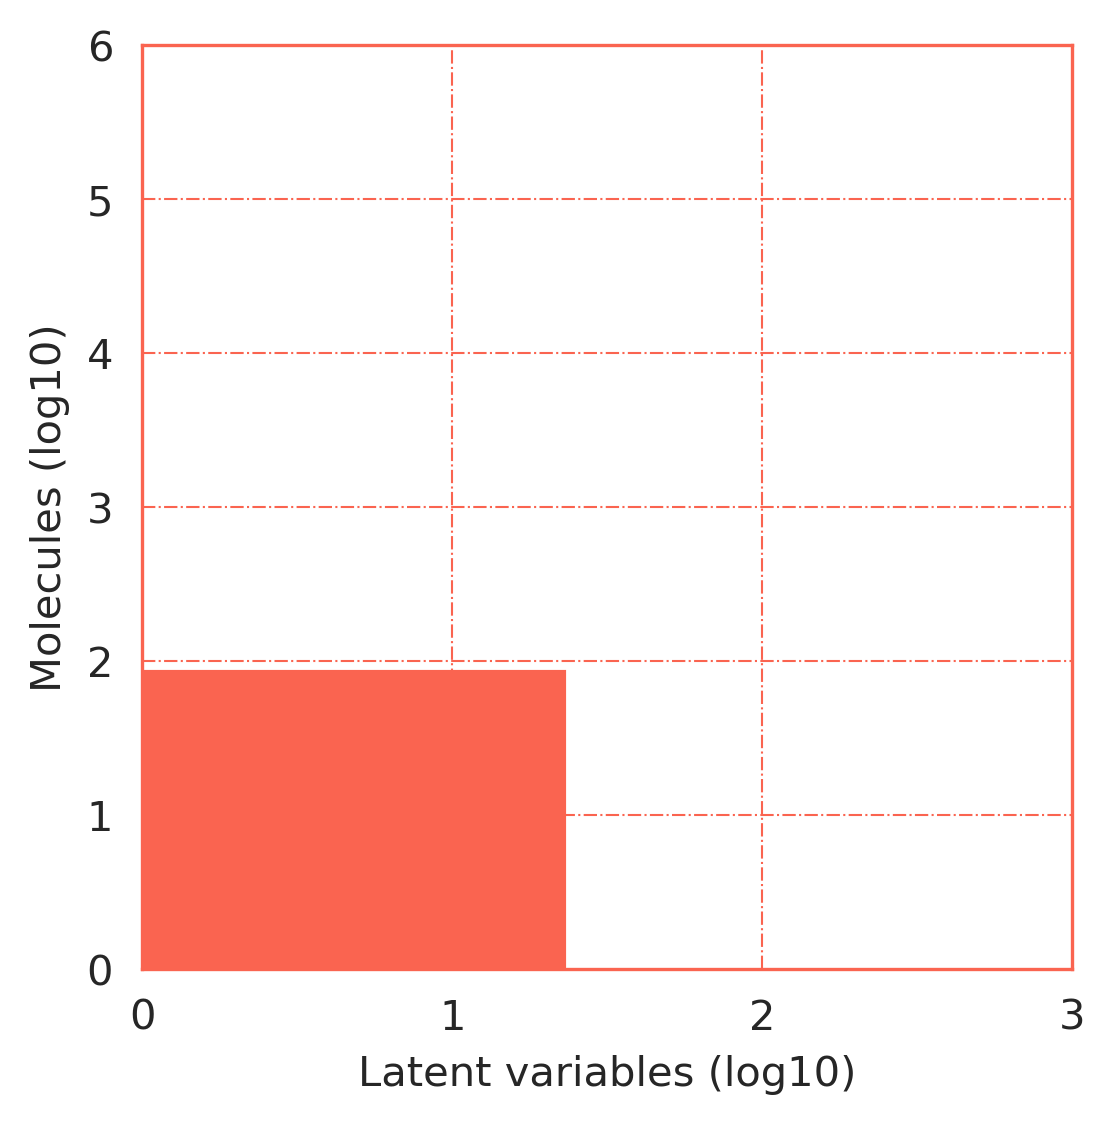

In [33]:
# Cleaning both full and reference datasets. This is crucial!
sign1_deps.clear_all()

# Fitting sign1
sign1_deps.fit(sign0_deps)

In [34]:
sign1_deps.shape

(922, 23)

2026-08-27 10:45:04,797 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /scratch/sbnb/sayala/protocols/local_PertProt
2026-08-27 10:45:04,845 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2026-08-27 10:45:04,846 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2026-08-27 10:45:04,846 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2026-08-27 10:45:04,848 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2026-08-27 10:45:04,848 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=922)
2026-08-27 10:45:04,849 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2026-08-27 10:45:04,865 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Saving signature subsample /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/sign1/diags/local_Pert

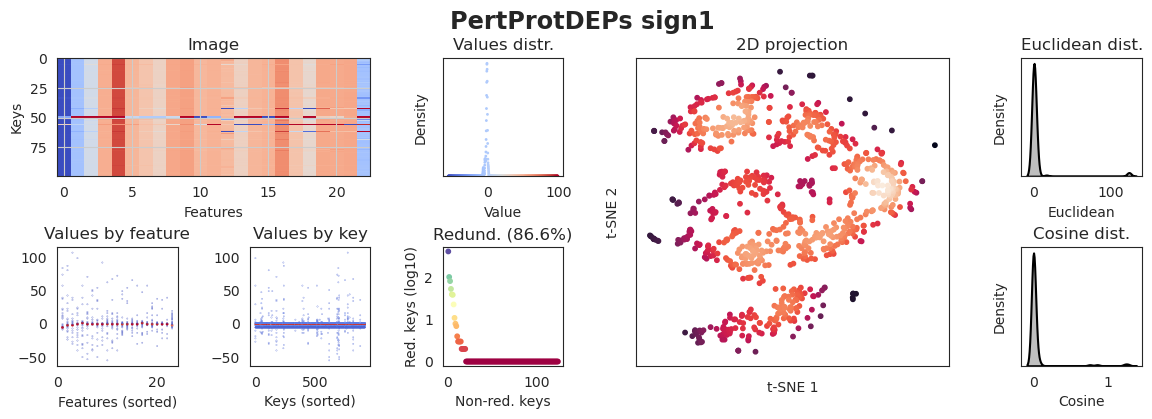

In [35]:
# Instantiation of diag1 (diagnosis plots)
diag1_deps = sign1_deps.diagnosis()

# Plot medium & small diagnosis plots
diag1_deps.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [37]:
# Instantiation of neig1
neig1_deps = cc_local.get_signature("neig1", "full", dataset_deps)  # It will take the reference anyway...

# Cleaning both full and reference. This is crucial!
neig1_deps.clear_all()

# Fitting neig1
neig1_deps.fit(sign1_deps)

2026-08-27 10:47:29,125 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/neig1
2026-08-27 10:47:29,129 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/neig1
2026-08-27 10:47:29,130 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /scratch/sbnb/sayala/protocols/local_PertProt/full/P/Pe/PertProtDEPs/neig1/neig.h5
2026-08-27 10:47:29,132 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtDEPs/neig1
2026-08-27 10:47:29,135 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtDEPs/neig1
2026-08-27 10:47:29,136 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /scratch/sbnb/sayala/protocols/local_PertProt/reference/P/Pe/PertProtDEPs/neig1/nei

In [38]:
neig1_deps.shape

array([922,  85])

In [39]:
np.min(np.array(sign1_deps).flatten()), np.max(np.array(sign1_deps).flatten())

(-56.013333007751214, 107.87390128991804)

## sign2 ##

In [ ]:
# Dataset Name
dataset = 'D6.001'

# Get sign1
sign1 = cc_local.get_signature('sign1', 'full', dataset)

# Get neig1
neig1 = cc_local.get_signature('neig1', 'full', dataset)  # By default, all vs ref

# Instantiation of sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Cleaning both full and reference datasets. This is crucial!
sign2.clear_all()

# Fit sign2 given sign1 & neig1
sign2.fit(sign1, neig1, oos_predictor=False)

In [ ]:
sign2.shape

In [ ]:
# Instantiation of sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Instantiation of diag2 (diagnosis plots)
diag2 = sign2.diagnosis()

# Plot medium & small diagnosis plots
diag2.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [ ]:
np.min(np.array(sign2).flatten()), np.max(np.array(sign2).flatten())

## sign3 ##

In [ ]:
# Dataset Name
dataset = 'D6.001'

# Get CC universe
cc_universe = []
for dat in cc_local.datasets:
    if dat != dataset and dat.endswith('001'):
        cc_universe.extend(cc_local.get_signature('sign2', 'full', dat).keys)
cc_universe = set(cc_universe)

# Get sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Get D6 molecules
d6_molecules = set(sign2.keys)

print("Number of molecules in the CC universe: " + str(len(cc_universe)))
print("Number of molecules in D6 sign2: " + str(len(d6_molecules)))
print("Intersection CC & D6: " + str(len(cc_universe.intersection(d6_molecules))))

In [ ]:
# Instantiation of sign3
sign3 = cc_local.signature(dataset, 'sign3')
sign3.clear_all()

# Create a list of sign2 to feed sign3 -- using the 25 CC spaces & D6
sign2_list = list()

# For each CC space
for ds in cc_local.coordinates:
    ds += '.001'
    sign2_list.append(cc_local.get_signature('sign2', 'full', ds))

# Append the new D6 space
sign2_list.append(cc_local.get_signature('sign2','full', dataset))

# In total, we now have 26 spaces
print(len(sign2_list))

# Get D6 sign1
sign1_self = cc_local.signature(dataset, 'sign1')

# Get D6 sign2
sign2_self = cc_local.signature(dataset, 'sign2')

In [ ]:
# Fit sign3 

mapp = None
""" 
# Alternatively, you can provide your in-house python dictionary to map InchiKey's to InChI's (see example below)
mapp = { 
'LPXQRXLUHJKZIE-UHFFFAOYSA-N': 'InChI=1S/C4H4N6O/c5-4-6-2-1(3(11)7-4)8-10-9-2/h(H4,5,6,7,8,9,10,11)',
'BZKPWHYZMXOIDC-UHFFFAOYSA-N': 'InChI=1S/C4H6N4O3S2/c1-2(9)6-3-7-8-4(12-3)13(5,10)11/h1H3,(H2,5,10,11)(H,6,7,9)',
'XZWYZXLIPXDOLR-UHFFFAOYSA-N': 'InChI=1S/C4H11N5/c1-9(2)4(7)8-3(5)6/h1-2H3,(H5,5,6,7,8)'
} 
"""

# CAUTION: COMPUTATIONALLY DEMANDING STEP - Consider running it in an HPC cluster
sign3.fit(sign2_list, sign2_self, sign1_self, sign2_universe=None, complete_universe="fast", sign2_coverage=None, dbconnect=False, mapping_dict=mapp)

In [ ]:
dataset = 'D6.001'

# Instantiation of sign3
sign3 = cc_local.signature(dataset, 'sign3')
sign3 = np.array(sign3)

print(sign3.shape, np.min(sign3), np.max(sign3))

In [ ]:
# Instantiation of diag3 (diagnosis plots)
sign3 = cc_local.signature(dataset, 'sign3')
diag3 = sign3.diagnosis(ref_cctype='sign3')

# Plot medium & small diagnosis plots
diag3.canvas(size='medium', savefig=True, savefig_kwargs={'dpi': 300})
diag3.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})